 <font size="+3"> <b> NeuroPyxels quickstart </b> </font>

Put together for UCL Neuropixels course, October 2022

Github repo: https://github.com/m-beau/NeuroPyxels

Install with `pip install npyx` in your favorite environment!

#### Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [3]:
# Ensures that npyx will ACTUALLY be reimported in a running session
%reload_ext autoreload
%autoreload 2
from npyx import *

cupy could not be imported - some functions dealing with the binary file (filtering, whitening...) will not work.
Oh no! Arial isn't on your system. We strongly recommend that you install Arial for your aesthetic sanity.
Oh no! Arial isn't on your system. We strongly recommend that you install Arial for your aesthetic sanity.

npyx version 4.1.3 imported.


## 1 - Loading Neuropixels data

First, fill in the path to your spike-sorted Neuropixels dataset (e.g. sorted with kilosort and curated with phy)

In [5]:
dp = "F:/Fa1680378B/1Cntrl/ks4phy_autocurated" # dp stands for datapath
print(os.path.exists(dp))

True


### 1.1 - Load Neuropixels sync channel, metadata

In [6]:
# Threshold crosses of the sync channel acquired with the SMA port on the acquisition board
onsets, offsets = get_npix_sync(dp)
onsets

WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat


{'TTL': array([149.00059912, 149.50060215, 150.00059545, ..., 759.00297027,
        759.50297359, 760.00297691])}

In [7]:
# blah.ap.meta file contents and more
meta = read_metadata(dp)
print(f"Neuropixels probe {meta['probe_version']} acquired with {meta['acquisition_software']}.")
fs = meta['NP']['sampling_rate']
print(f"Highpass filtered data at {meta['NP']['binary_relative_path']} was acquired at {fs} Hz.")

WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
Neuropixels probe 1.0 acquired with OpenEphys.
Highpass filtered data at ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat was acquired at 30000.0 Hz.


### 1.2 Load units and unit qualities (good, mua, noise...)

In [8]:
all_units = get_units(dp)
good_units = get_units(dp, "mua")
good_units

array([  0,   2,   4,   6,   8,   9,  10,  11,  13,  17,  19,  20,  21,
        22,  23,  24,  26,  27,  30,  31,  32,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  50,  51,  52,  53,
        54,  55,  56,  57,  58,  59,  60,  61,  63,  64,  65,  67,  68,
        70,  71,  72,  73,  76,  77,  78,  79,  80,  81,  82,  83,  84,
        86,  87,  88,  92,  93,  94,  96,  98, 104, 109, 110, 144, 162,
       164, 168, 172, 174, 182, 184, 185, 188, 189, 190, 194], dtype=int64)

### 1.3 - Load spike trains

Neuron 19 has 10126 spikes.


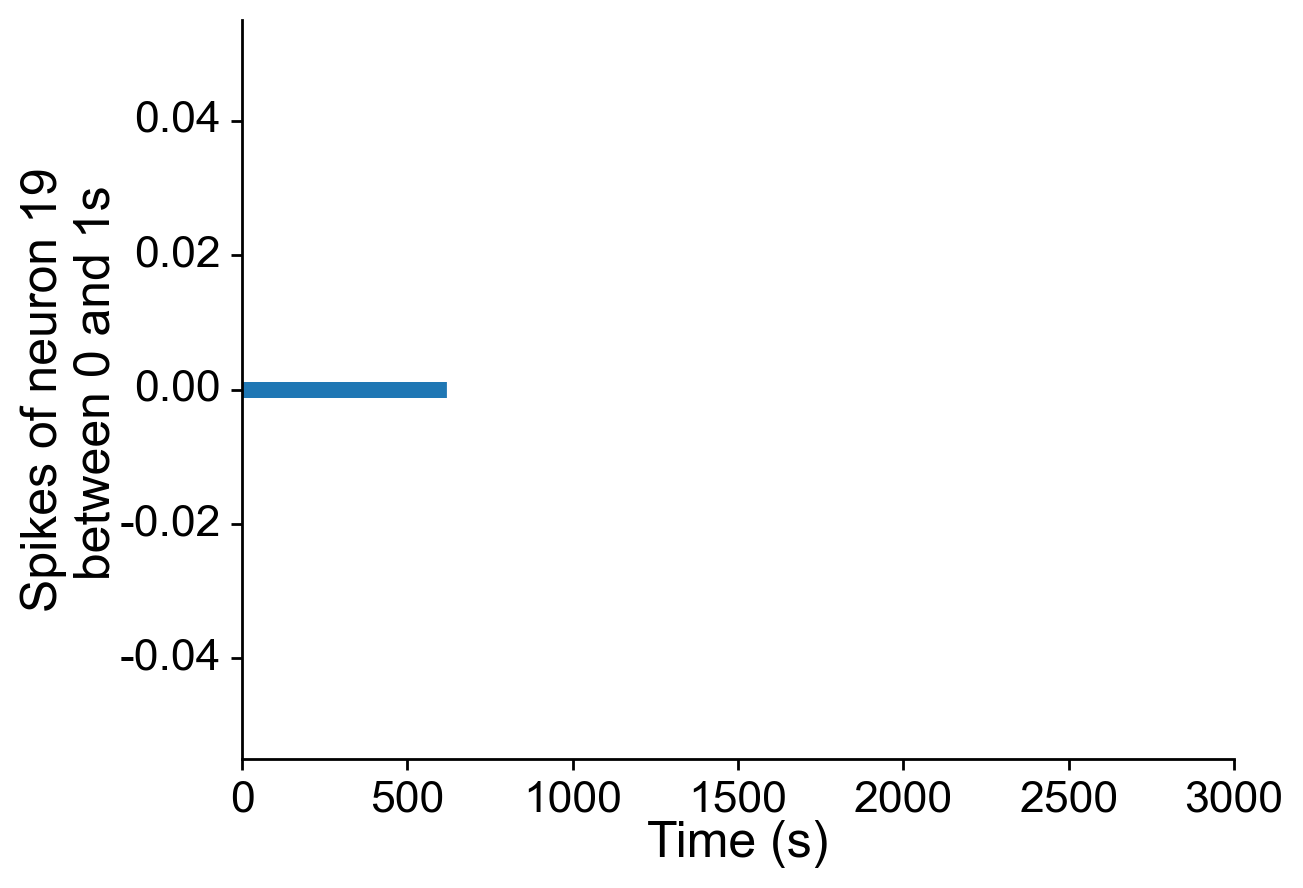

In [9]:
# pick unit
u = good_units[10]

# Load spikes 
t = trn(dp, u)
print(f"Neuron {u} has {t.shape[0]} spikes.")
t = t / fs # convert from samples to seconds

# Plot
plt.scatter(t, t*0, marker="|")
fig = mplp(xlim = [0,3000], ylabel = f"Spikes of neuron {u}\n between 0 and 1s", xlabel = "Time (s)")

WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
Neuron 0 has 689 spikes.
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
Neuron 2 has 2399 spikes.
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
Neuron 4 has 776 spikes.
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
Neuron 6 has 4196 spikes.
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
Neuron 8 has 6488 spikes.
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
Neuron 9 has 3

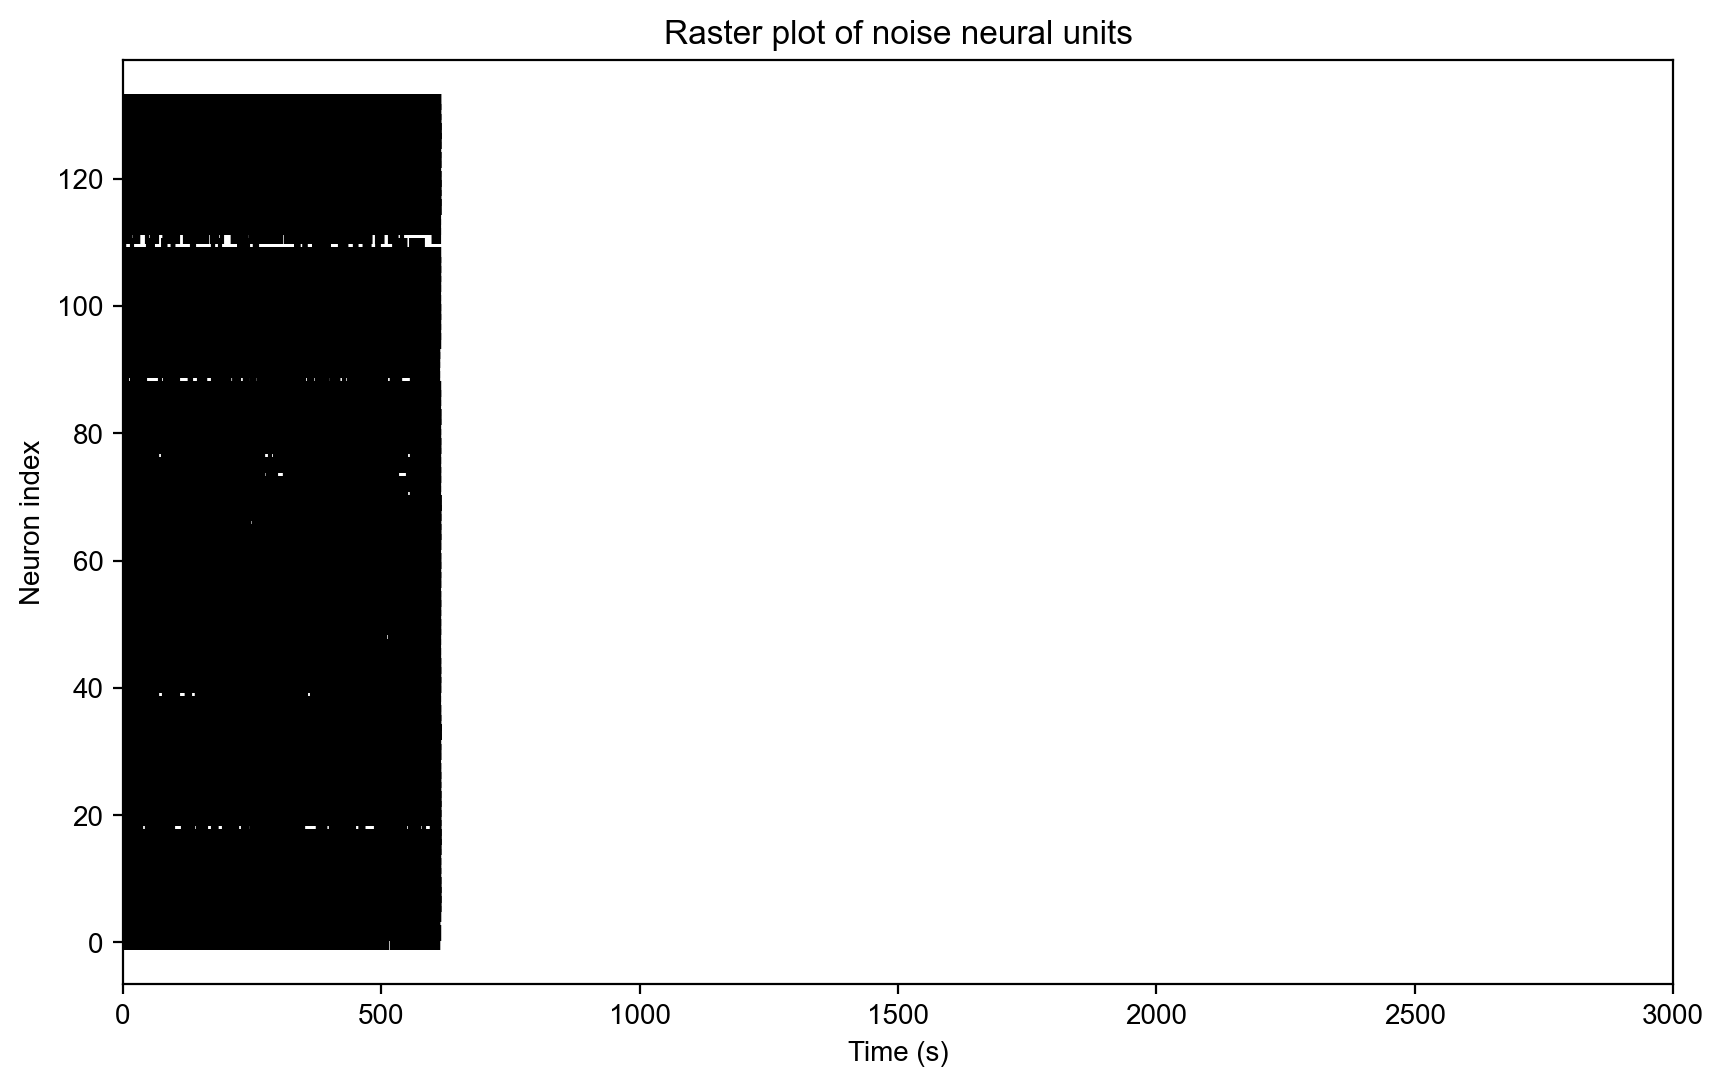

In [61]:
all_units = get_units(dp)
good_units = get_units(dp, "mua")

ts_list = []  # List to store spike times for each unit

for i, u in enumerate(good_units):
    t = trn(dp, u) / fs  # Convert from samples to seconds
    ts_list.append((t, i * 1.5))  # Store spike times with vertical offset
    print(f"Neuron {u} has {t.shape[0]} spikes.")

# Plot raster
plt.figure(figsize=(10, 6))
for t, y_offset in ts_list:
    plt.scatter(t, [y_offset] * len(t), marker="|", color="black")

plt.xlim(0, 3000)
plt.xlabel("Time (s)")
plt.ylabel("Neuron index")
plt.title("Raster plot of noise neural units")
plt.show()

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math as m
from scipy.spatial import distance


Tracking Analysis

In [20]:
# load data ###################################################################

# video recording rate---------------------------------------------------------
fps = 30 

# excel file in behavioural tracking info
behaviour_data = pd.read_csv(r'E:/Runita/TraackingWithCorrectTS/TSforConcatData/1680378B/Day5/Fa1680378B_Day5_1Cntrl.csv')

behaviour_timestamps = np.array(behaviour_data['time'])
behaviour_x = np.array(behaviour_data['x'])
behaviour_y = np.array(behaviour_data['y'])

In [21]:
#%%############################################################################
# remove zeros ################################################################

x2 = np.nonzero(behaviour_x)

x = behaviour_x[x2]
y = behaviour_y[x2]

behaviour_t = behaviour_timestamps[x2]/1000 #in seconds

In [22]:
# moving average #############################################################

window_size = 15

x_av = np.convolve(x, np.ones(window_size), 'same') / window_size
y_av = np.convolve(y, np.ones(window_size), 'same') / window_size


In [23]:
#%%############################################################################
# Find centre point ###########################################################

max_x = max(x_av)
max_y = max(y_av)

min_x = min(x_av)
min_y = min(y_av)

cent_x = min_x + (max_x-min_x)/2
cent_y = min_y + (max_y-min_y)/2


# change x and y relative to centre coords ------------------------------------

x_fin = x_av - cent_x
y_fin = y_av - cent_y 

Syncing spike data with tracking data

Neuron 160 has 2590 spikes.


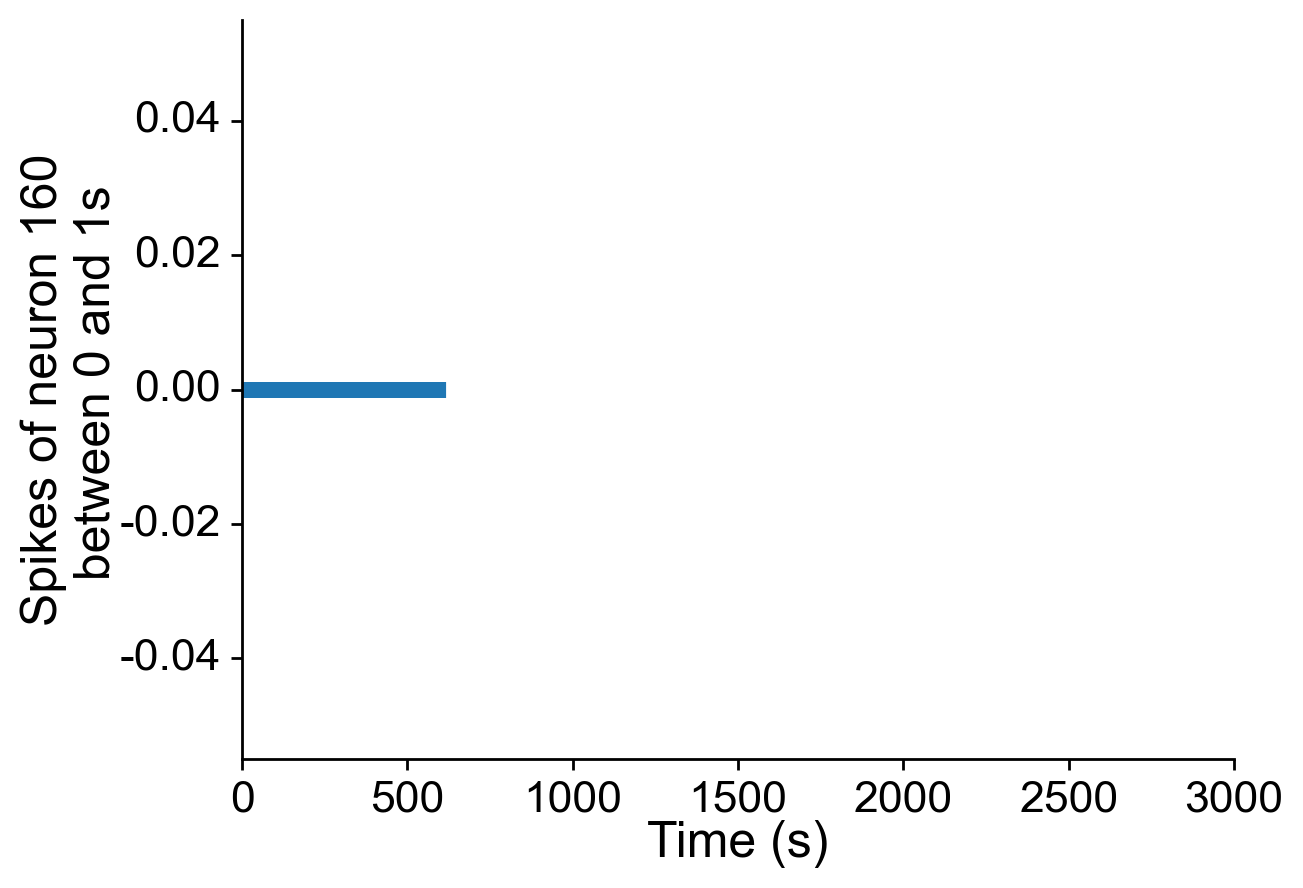

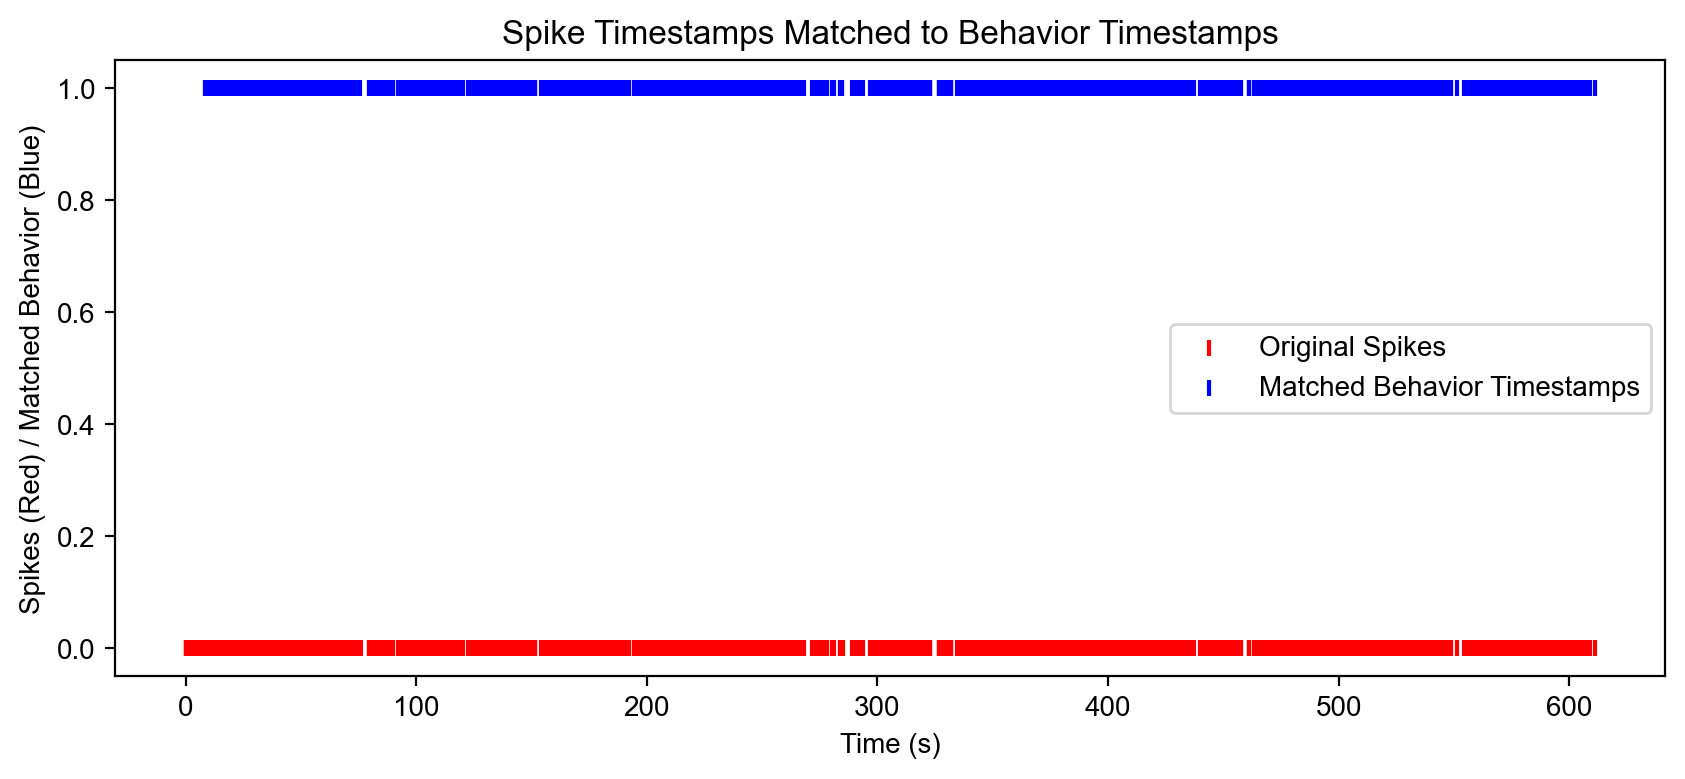

In [45]:
#%%############################################################################
# plot tracked behaviour with corresponding spikes ############################
# Loop through all good units
#for u in good_units:
    # Load spikes
#    t = trn(dp, u)
#   print(f"Neuron {u} has {t.shape[0]} spikes.")
    
#    t = t / fs  # Convert from samples to seconds

    
# pick unit
u = good_units[7]

# Load spikes 
t = trn(dp, u)
print(f"Neuron {u} has {t.shape[0]} spikes.")
t = t / fs # convert from samples to seconds
# Plot
plt.scatter(t, t * 0, marker="|")
fig = mplp(xlim=[0, 3000], ylabel=f"Spikes of neuron {u}\n between 0 and 1s", xlabel="Time (s)")

# Show each plot before moving to the next neuron
plt.show()

import numpy as np
import matplotlib.pyplot as plt

# Convert spike timestamps from samples to seconds
spike_timestamps = t  # Spike times (s)

# Behavior timestamps (assumed to be already in seconds)
# behaviour_t should be a sorted NumPy array
behaviour_t = np.array(behaviour_t)  # Ensure it's a NumPy array

# Initialize matched timestamps
sp_t = []

# Match each spike timestamp to the closest behavior timestamp
for spike in spike_timestamps:
    idx = np.searchsorted(behaviour_t, spike)  # Find closest index
    
    # Find the closest behavior timestamp
    if idx == 0:
        closest_t = behaviour_t[0]
    elif idx == len(behaviour_t):
        closest_t = behaviour_t[-1]
    else:
        before = behaviour_t[idx - 1]  # Previous behavior timestamp
        after = behaviour_t[idx]  # Next behavior timestamp
        
        # Pick the closer one
        closest_t = before if abs(spike - before) < abs(spike - after) else after

    # Check if the difference is within 0.04 seconds
    if abs(spike - closest_t) <= 0.04:
        sp_t.append(closest_t)

# Convert to NumPy array
sp_t = np.array(sp_t)

# Plot results
plt.figure(figsize=(10, 4))
plt.scatter(spike_timestamps, np.zeros_like(spike_timestamps), marker="|", color="r", label="Original Spikes")
plt.scatter(sp_t, np.ones_like(sp_t), marker="|", color="b", label="Matched Behavior Timestamps")
plt.xlabel("Time (s)")
plt.ylabel("Spikes (Red) / Matched Behavior (Blue)")
plt.legend()
plt.title("Spike Timestamps Matched to Behavior Timestamps")
plt.show()


ONLY FOR BATCH!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Neuron 105 has 751 spikes.


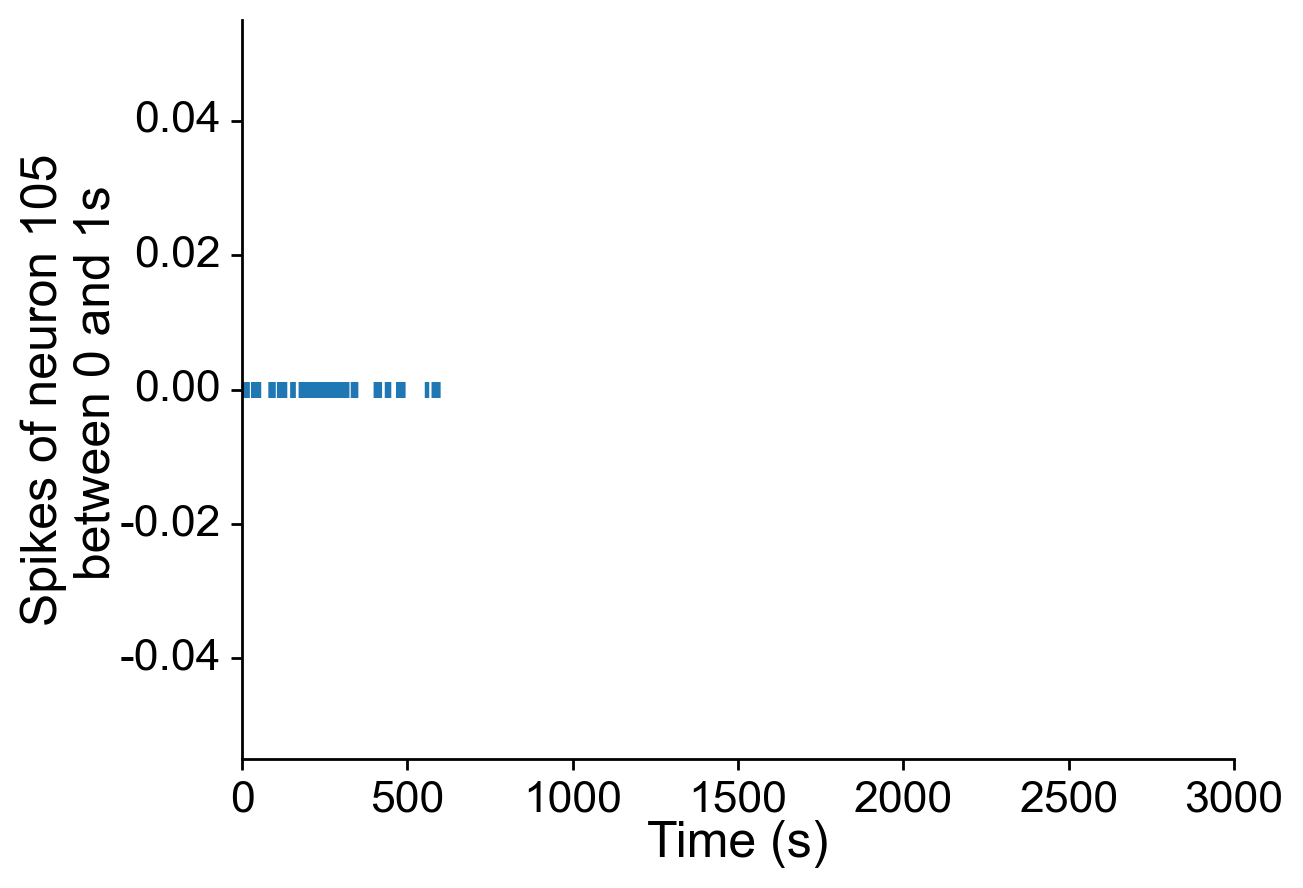

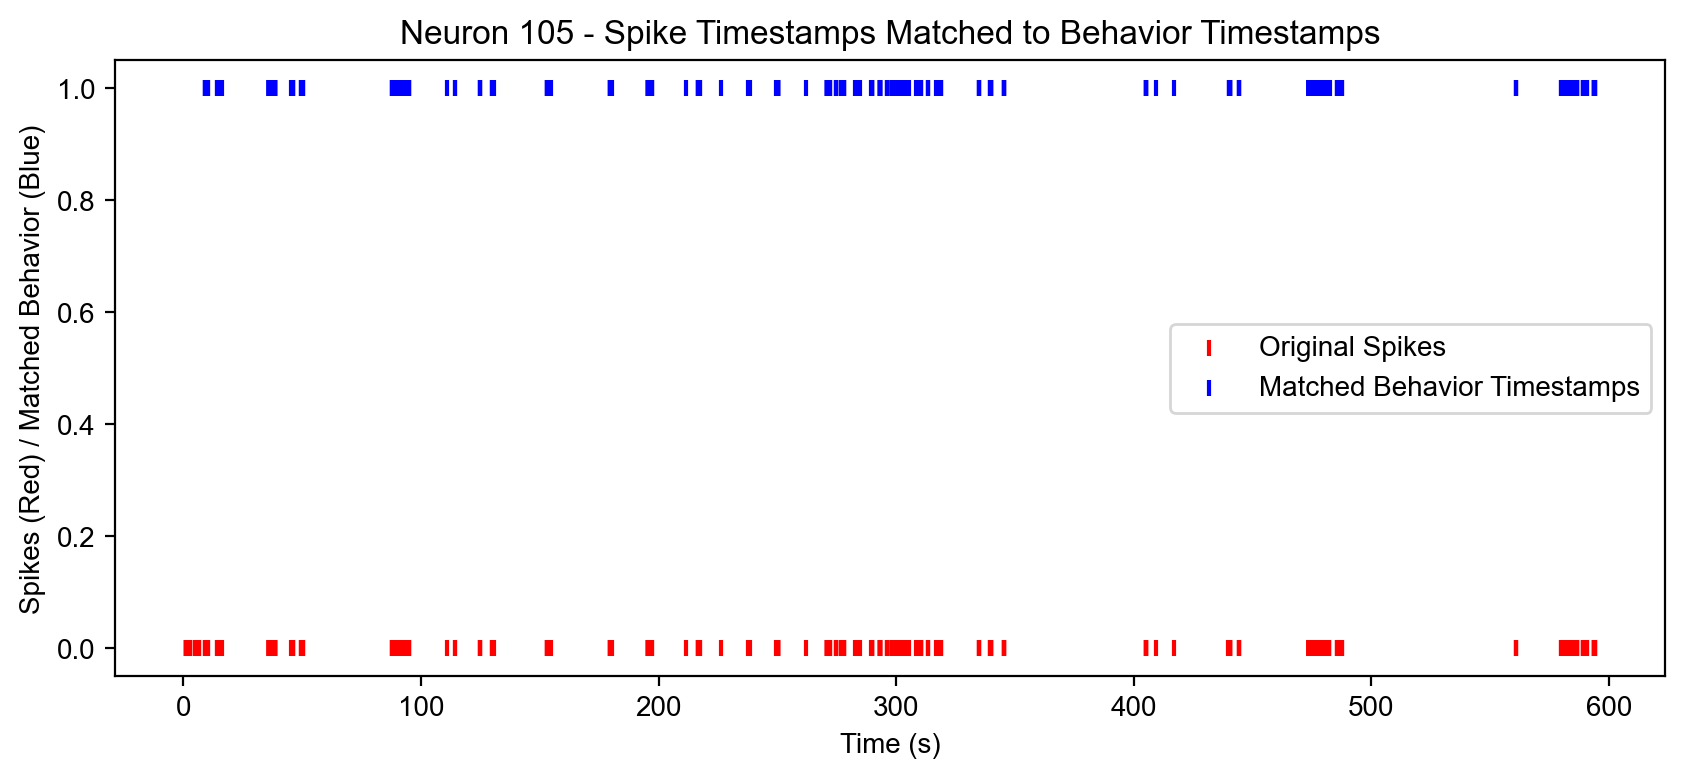

Neuron 118 has 3895 spikes.


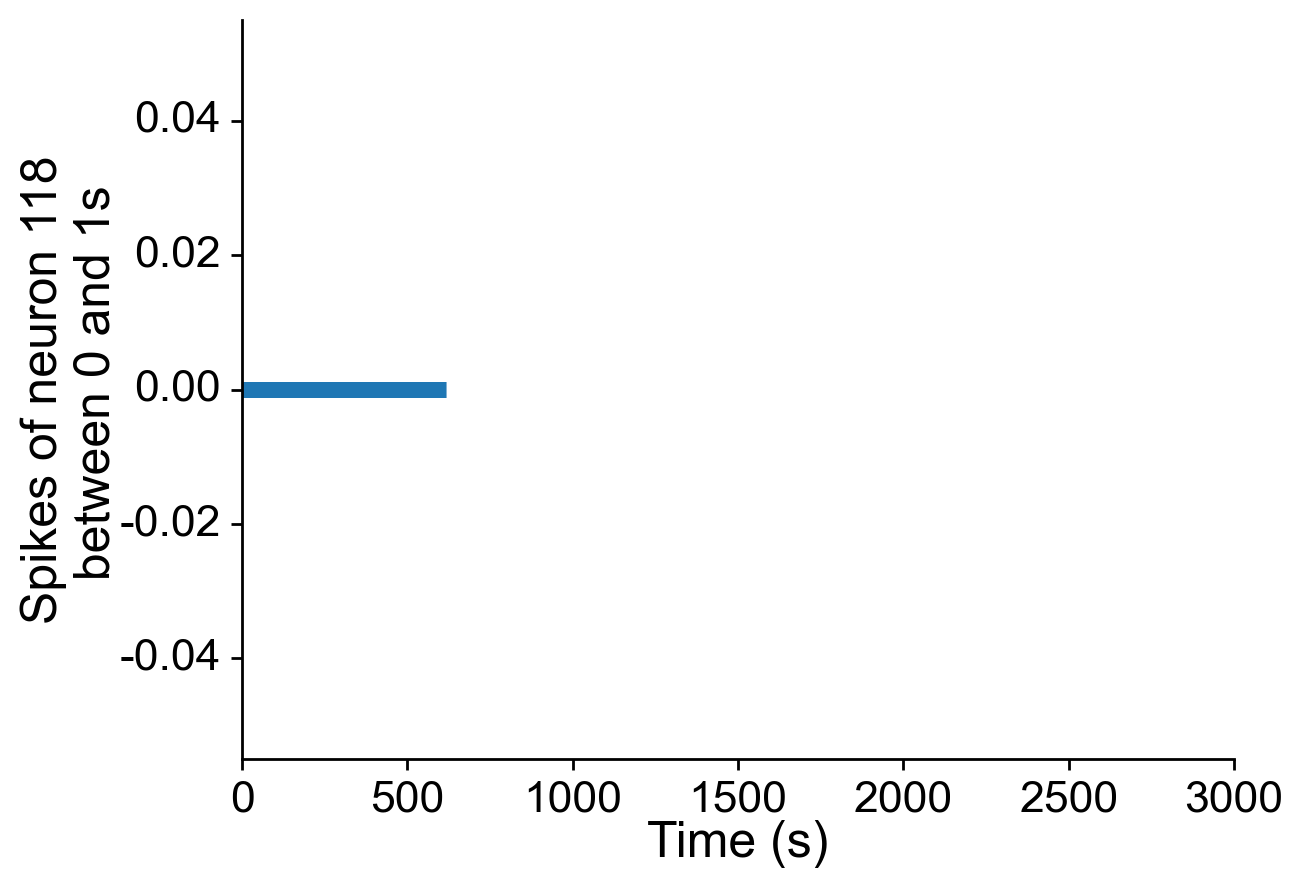

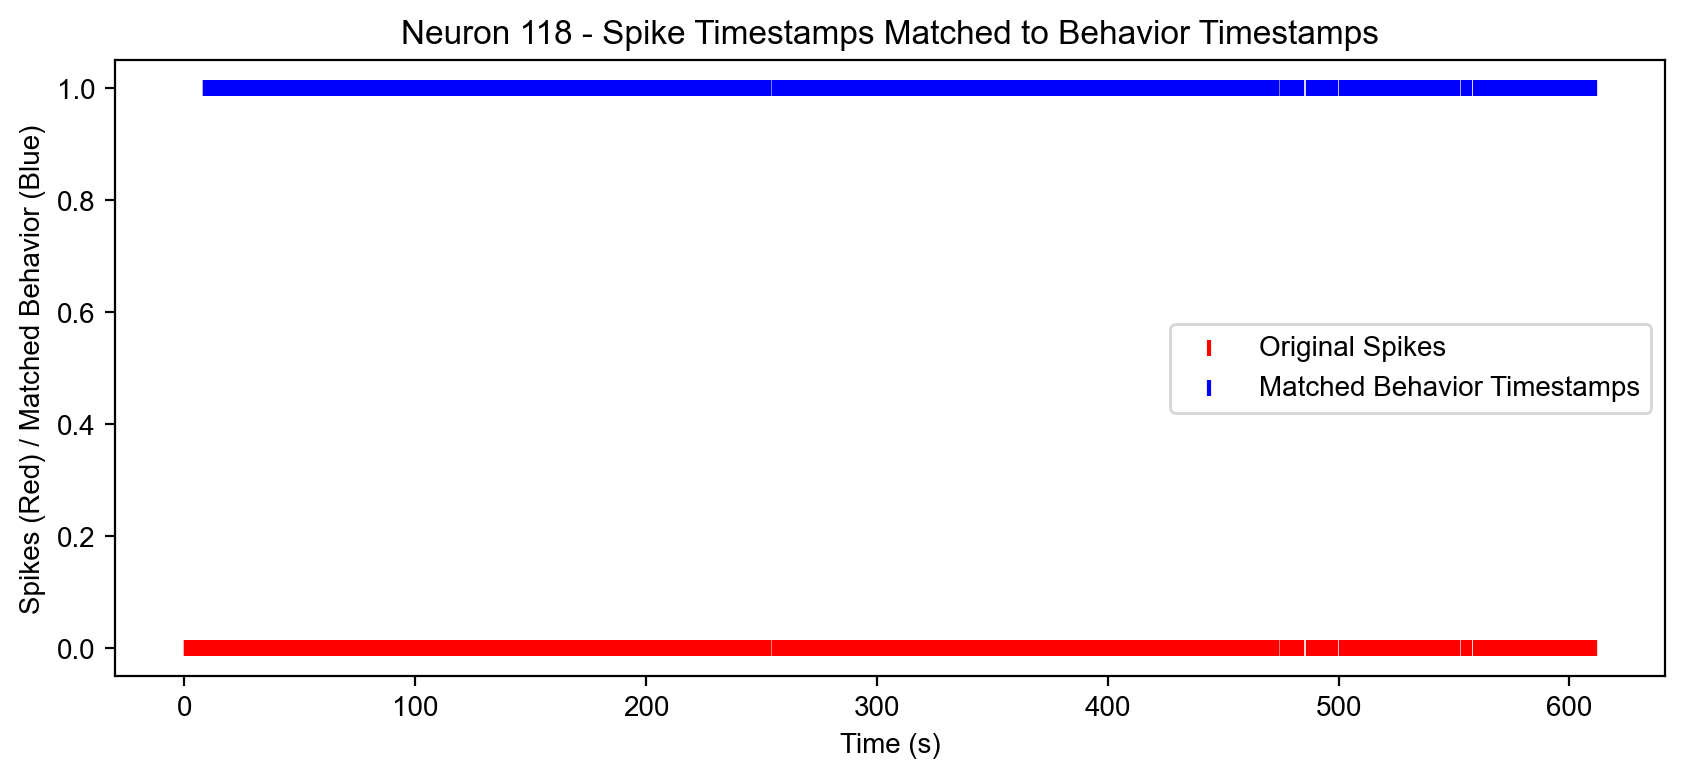

Neuron 124 has 3470 spikes.


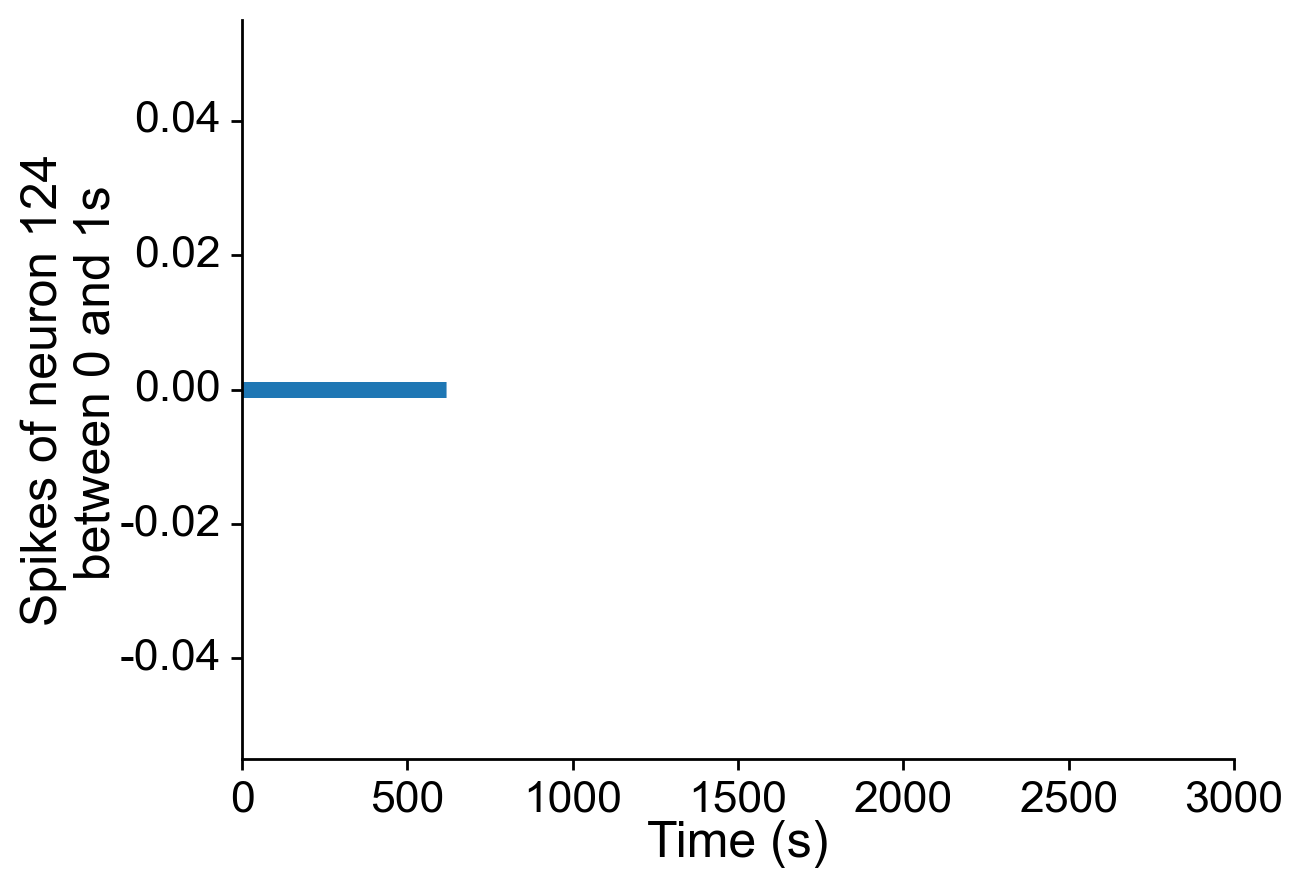

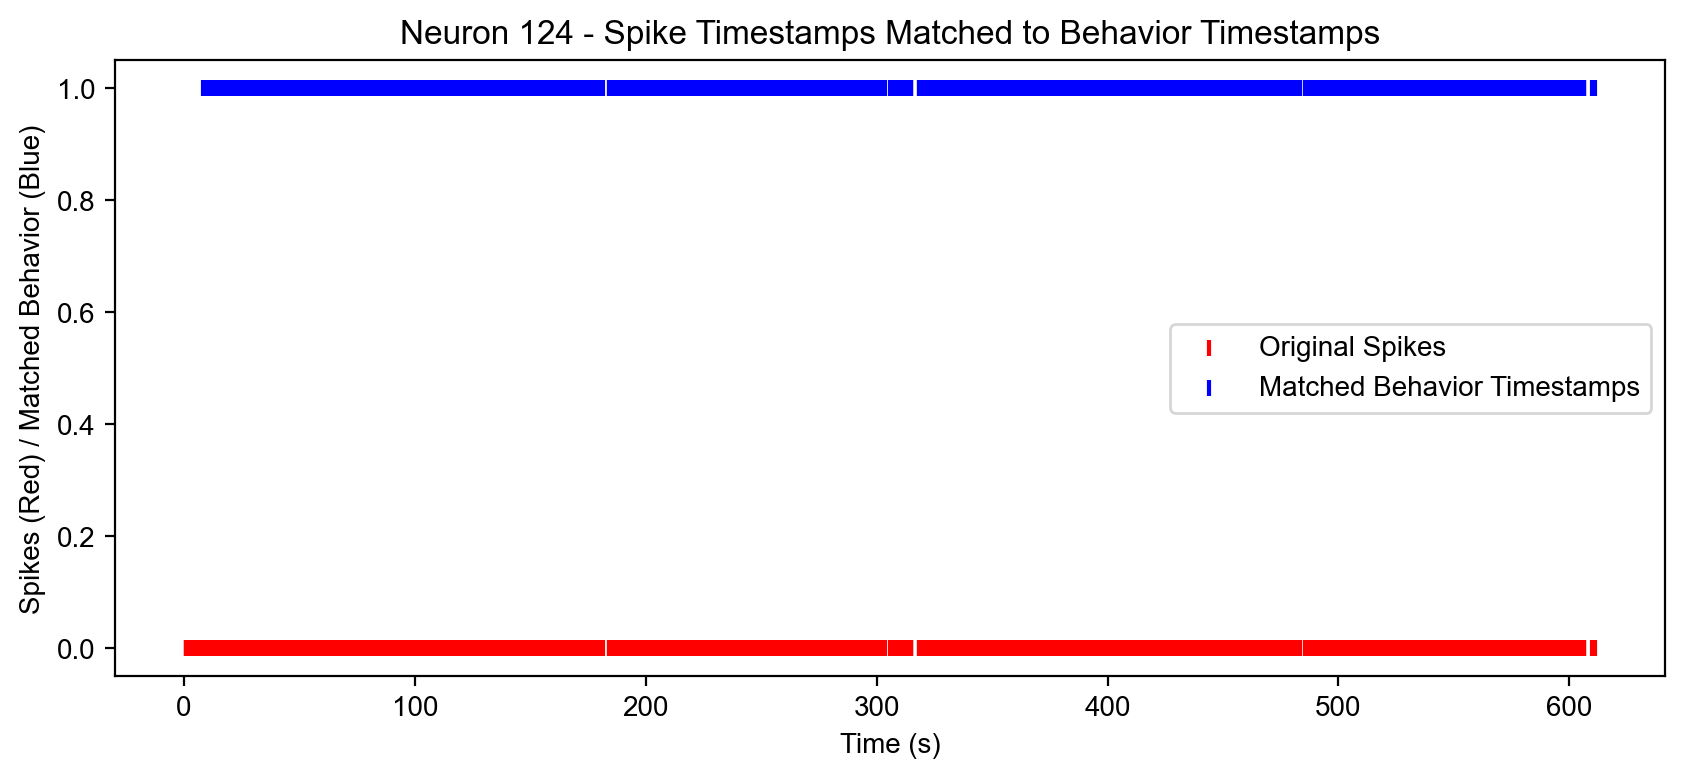

Neuron 146 has 2005 spikes.


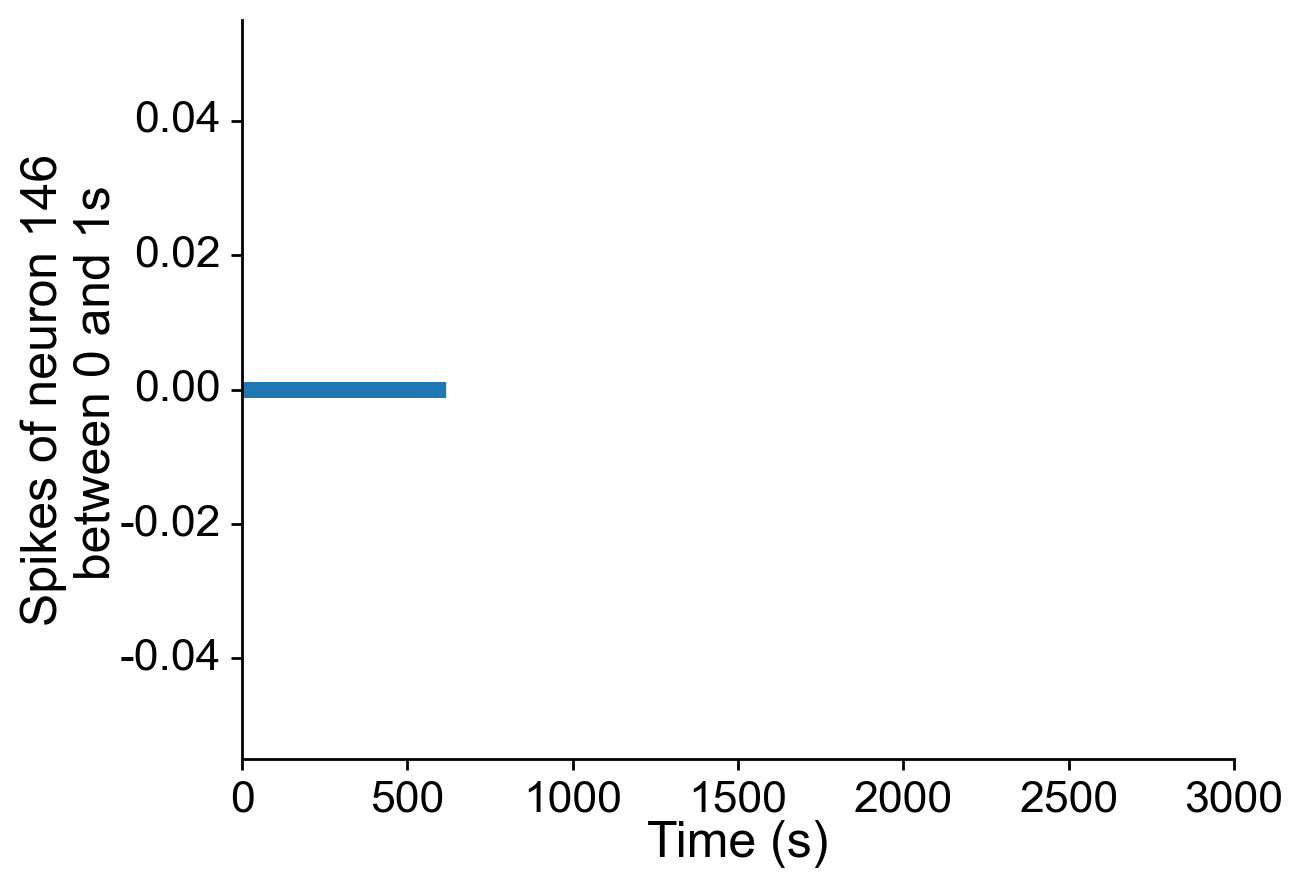

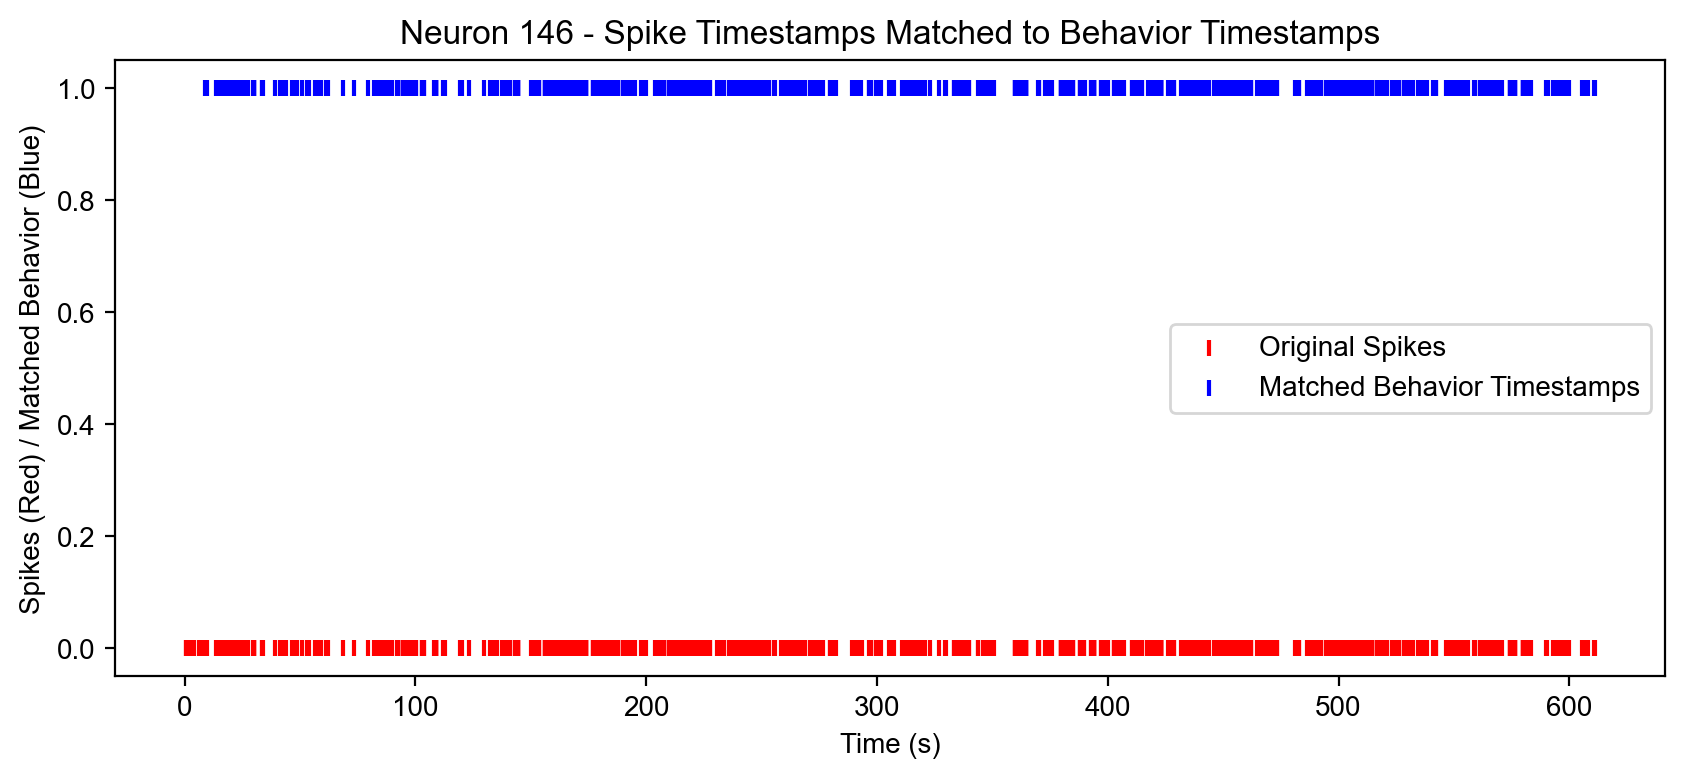

Neuron 148 has 1899 spikes.


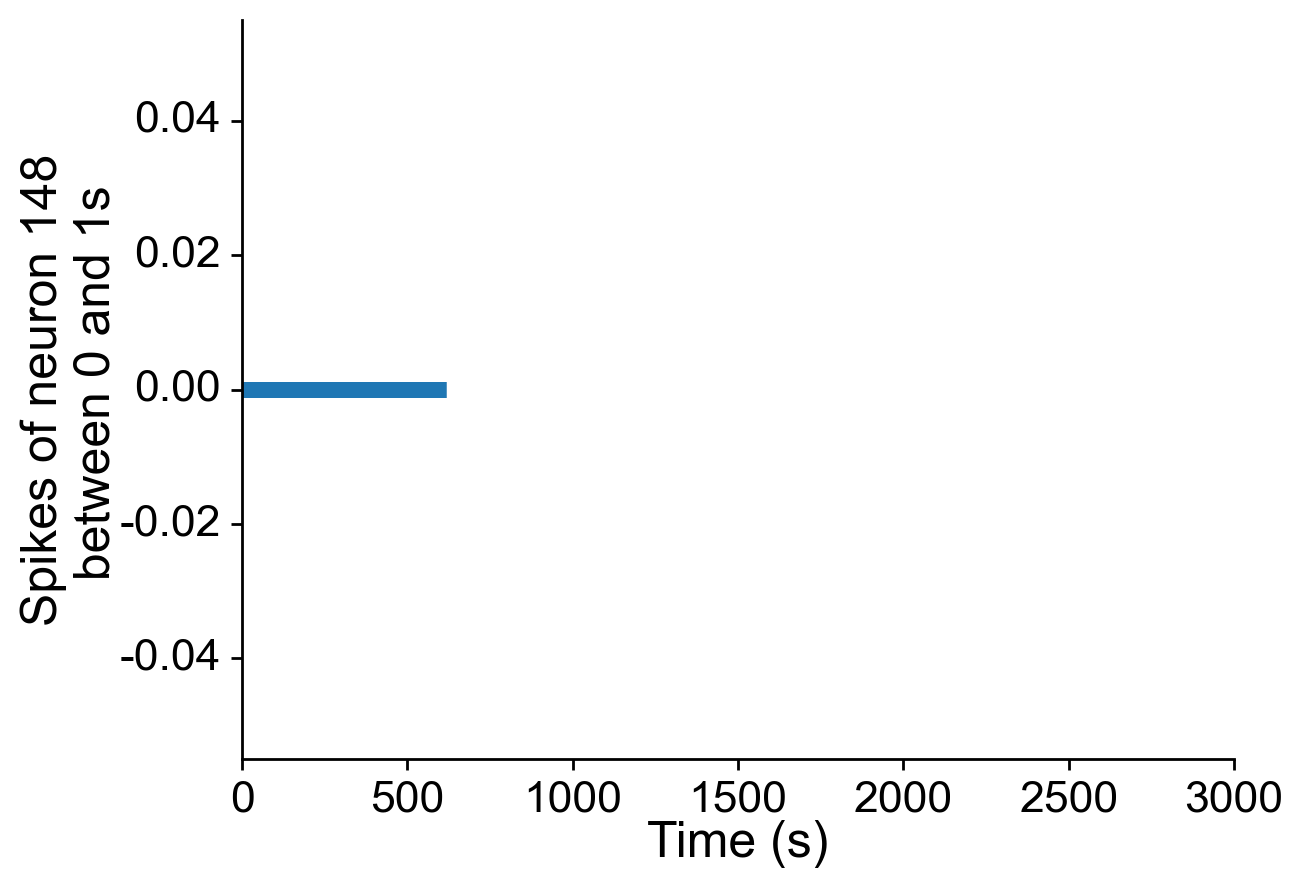

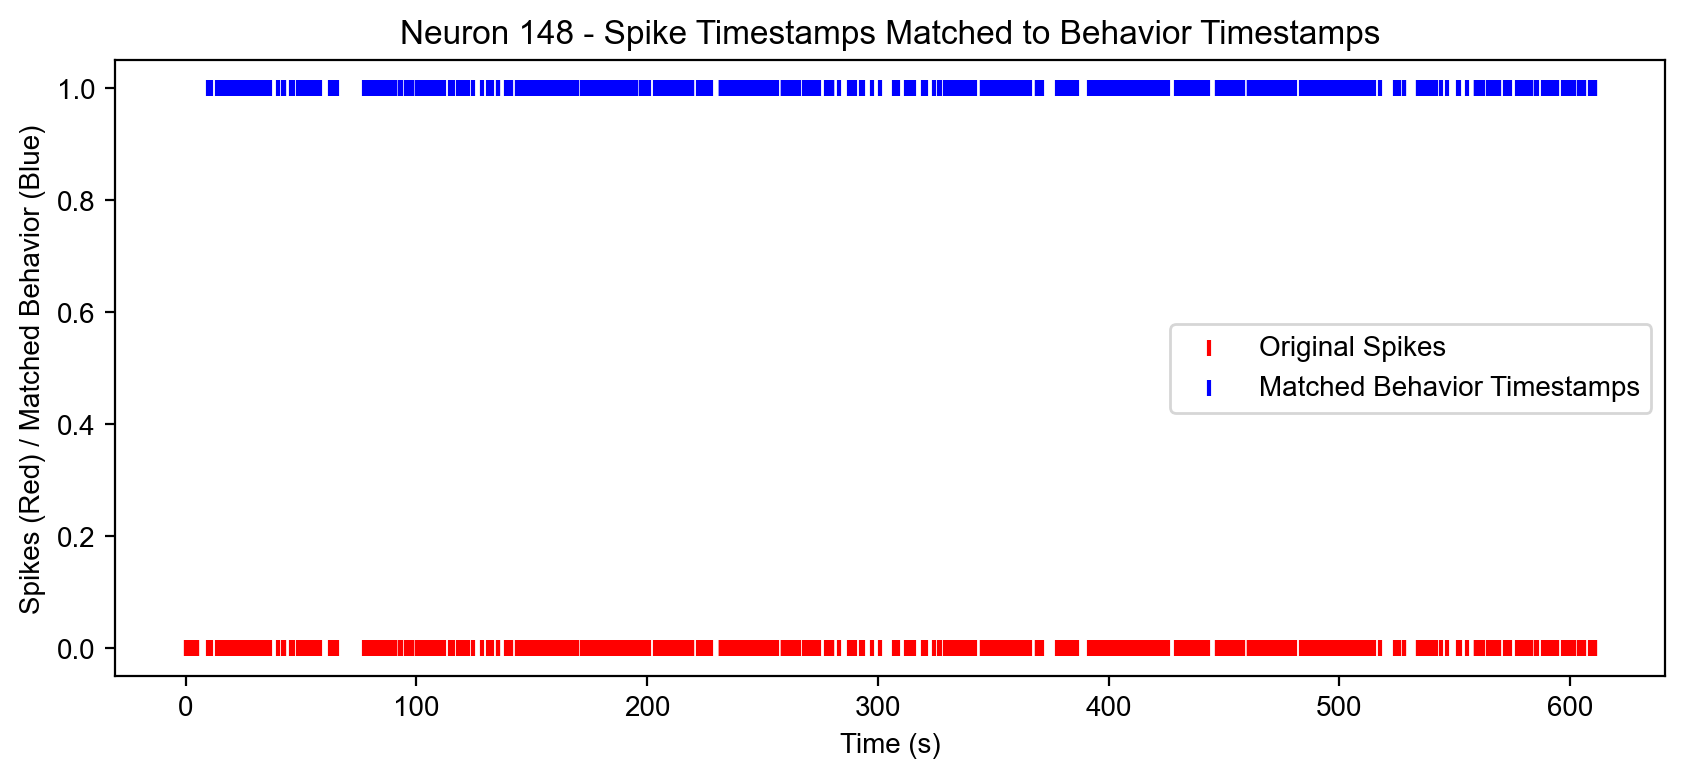

Neuron 152 has 925 spikes.


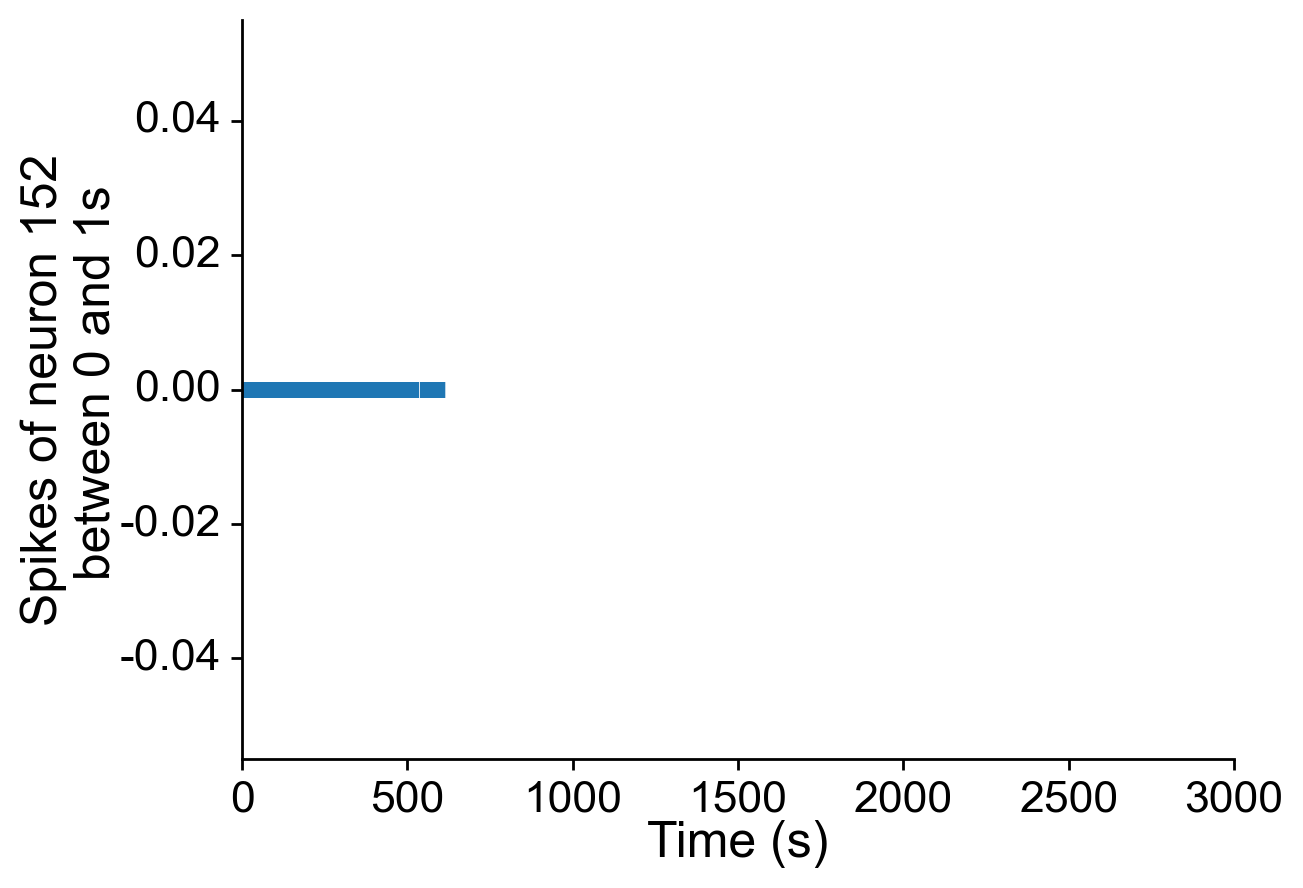

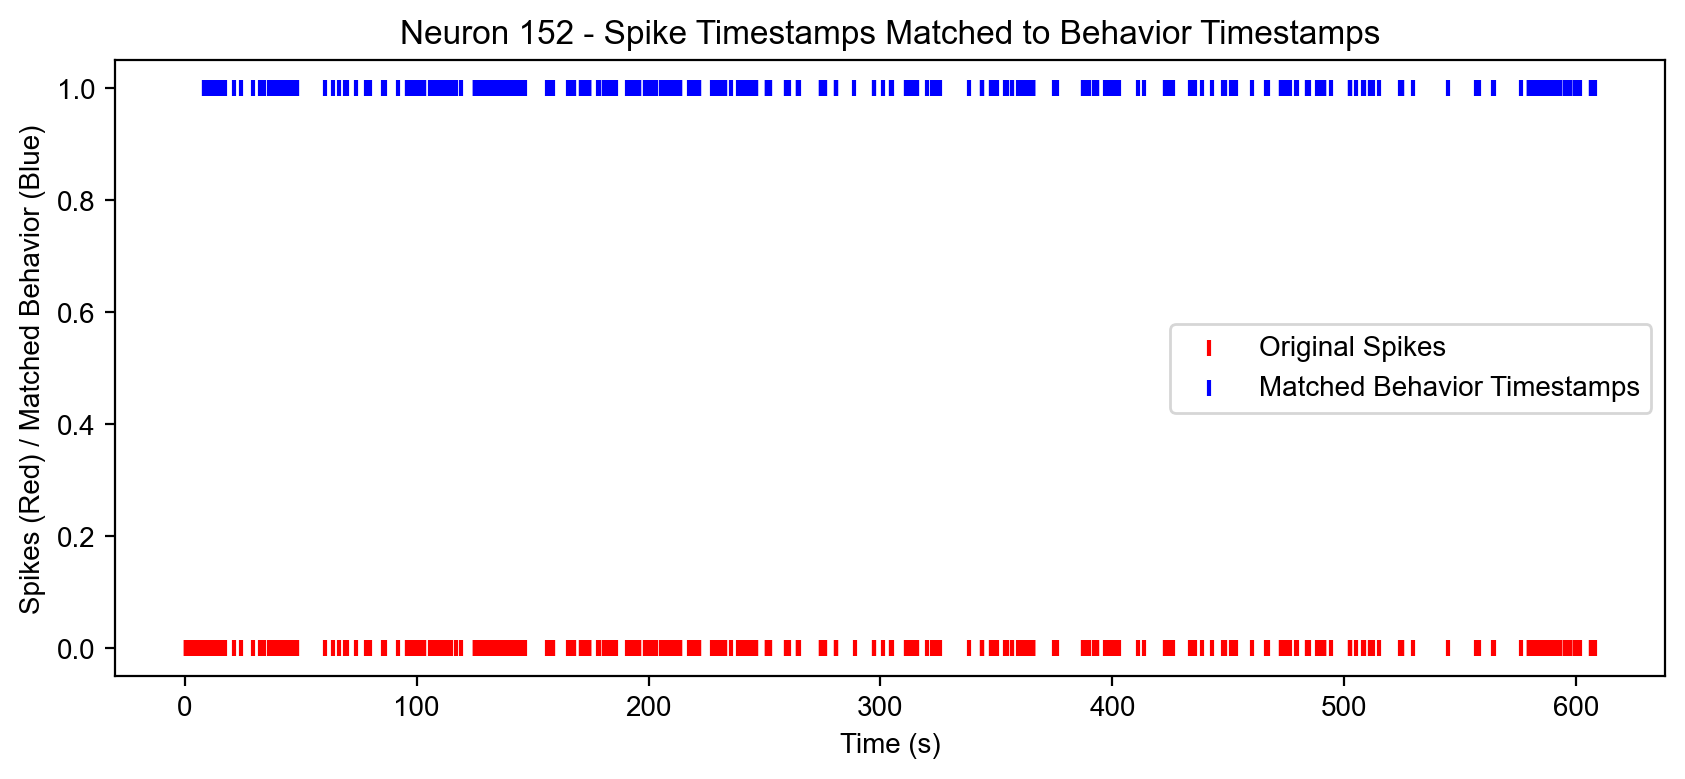

Neuron 154 has 8801 spikes.


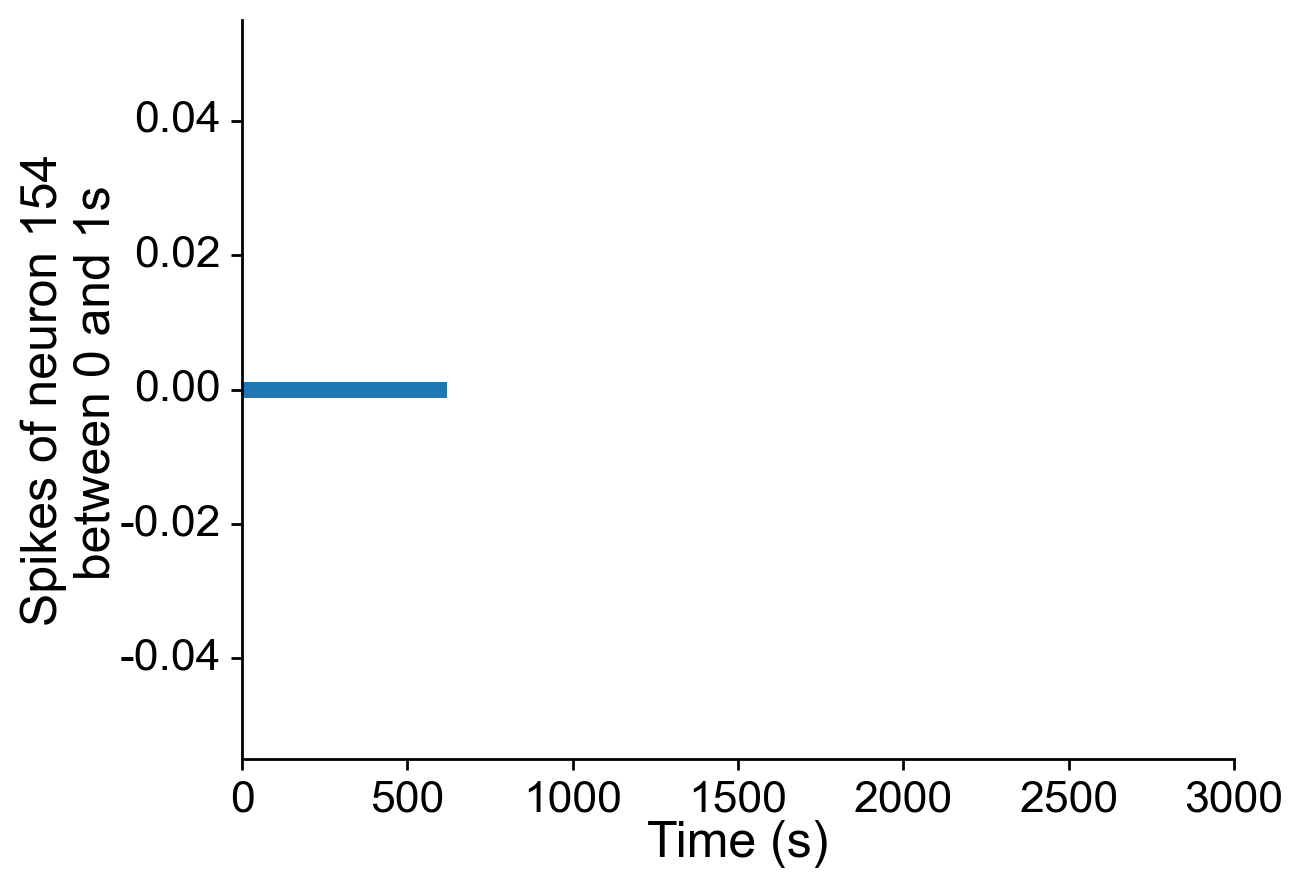

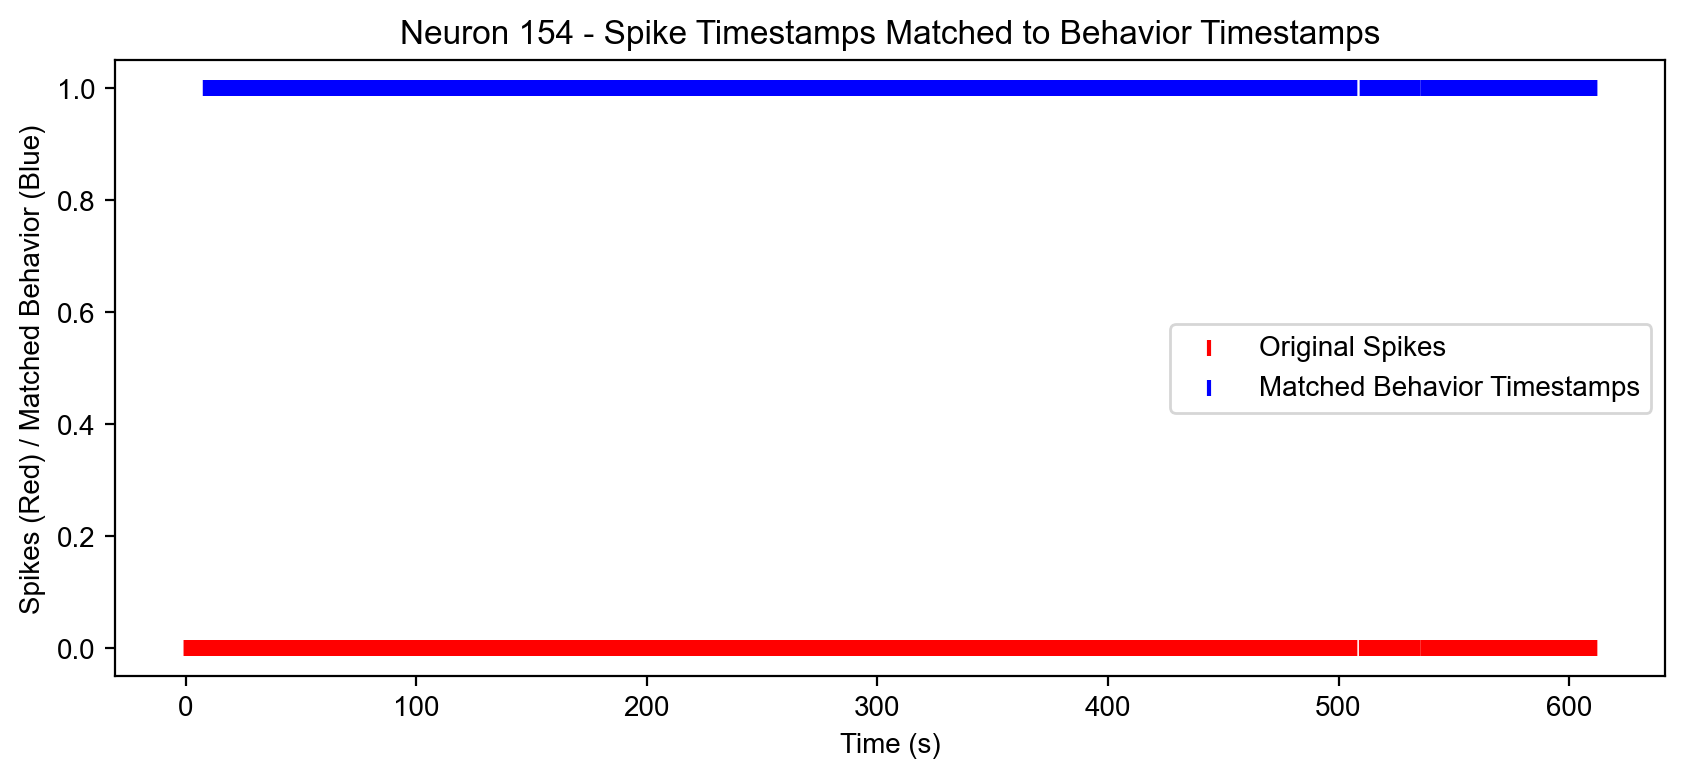

Neuron 160 has 2590 spikes.


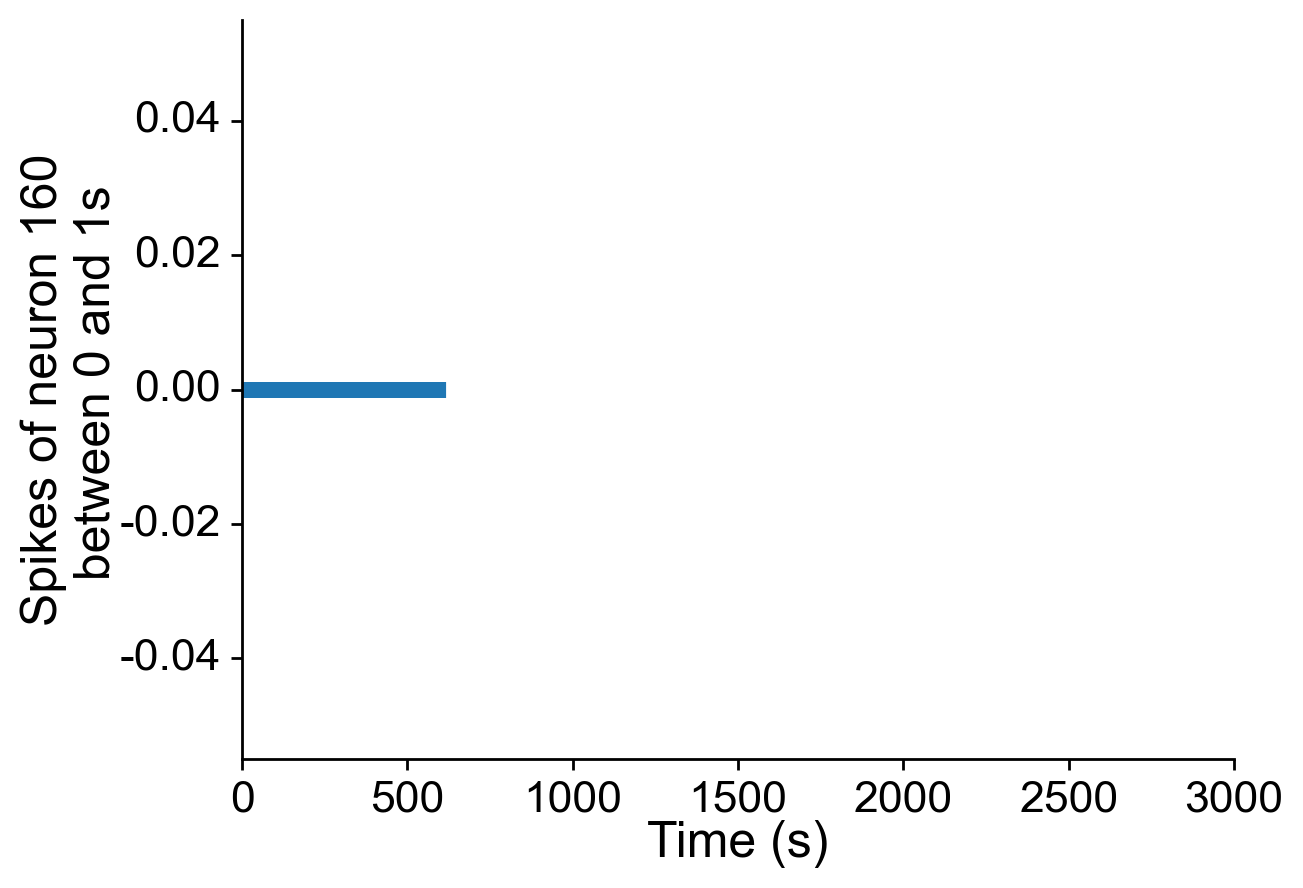

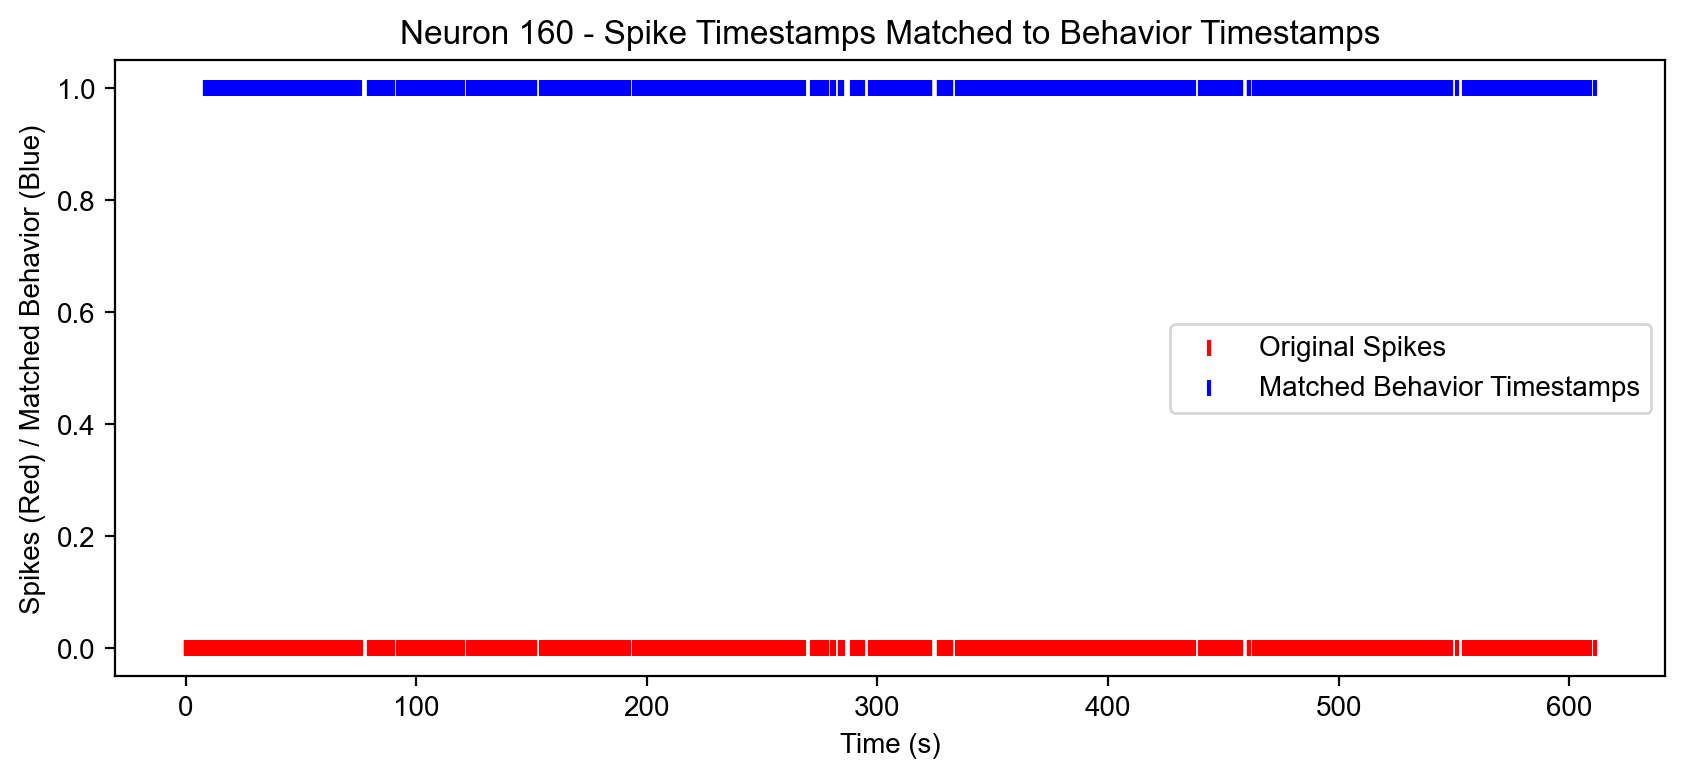

Neuron 166 has 6976 spikes.


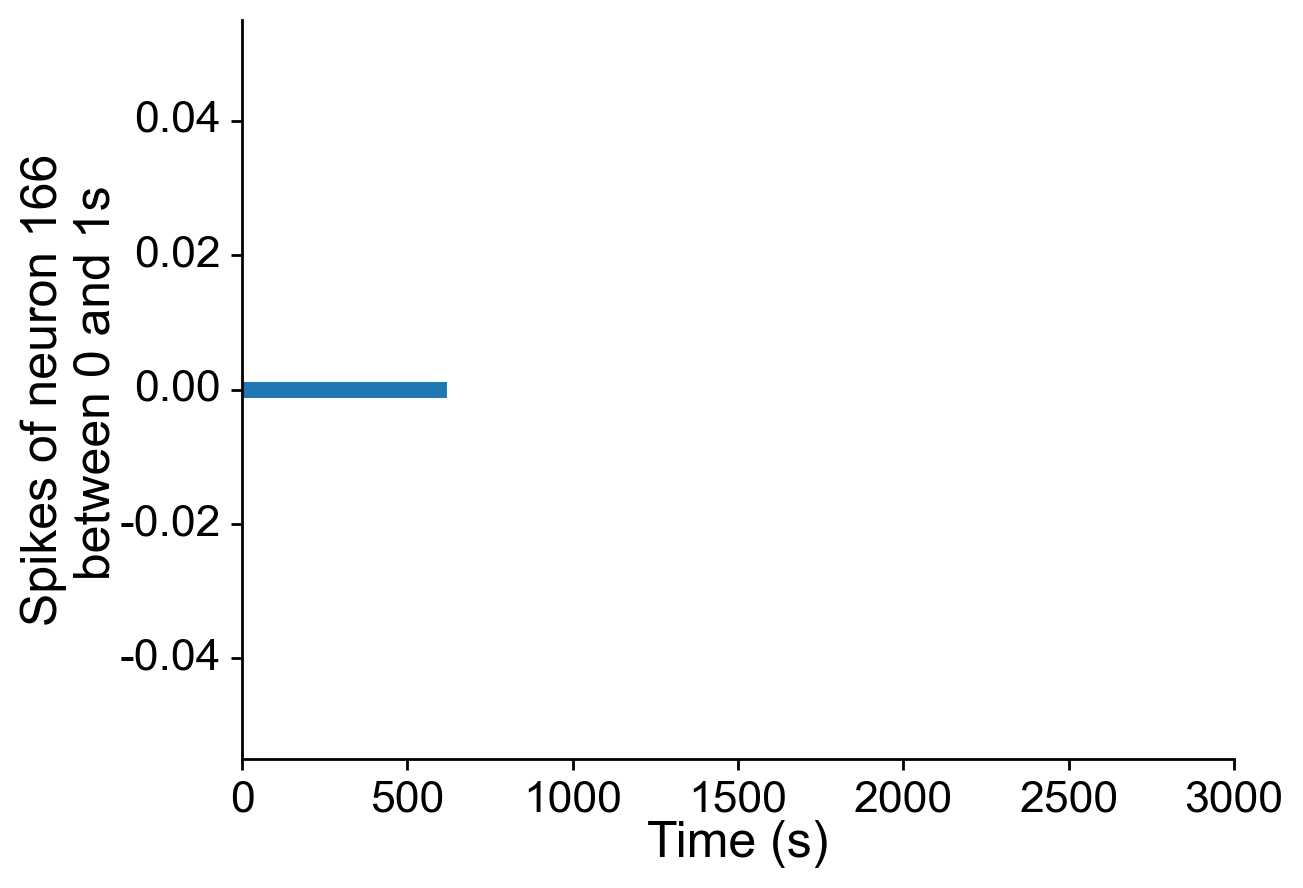

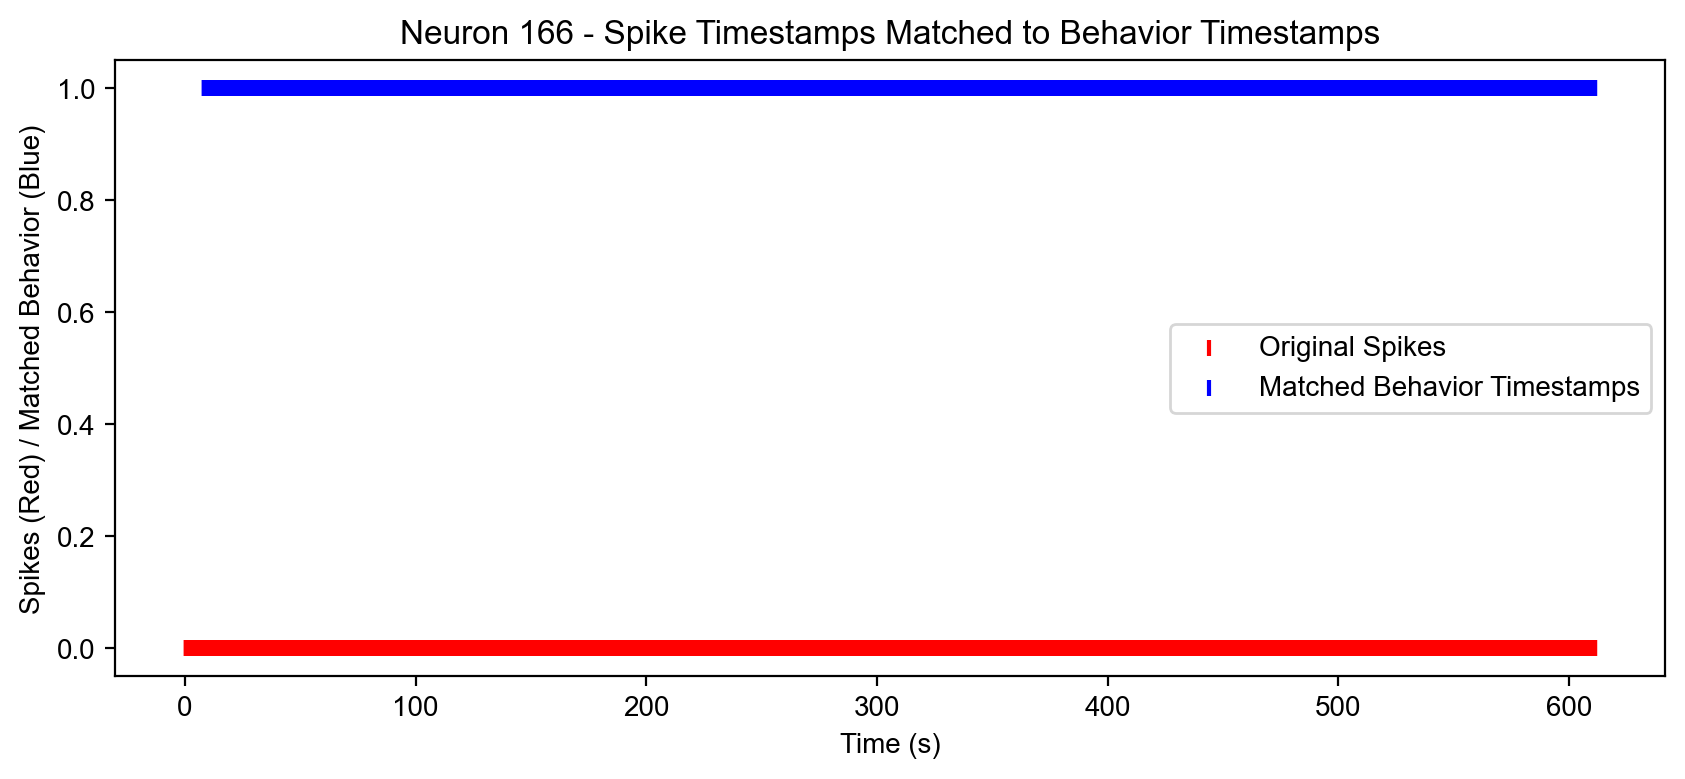

Neuron 178 has 20776 spikes.


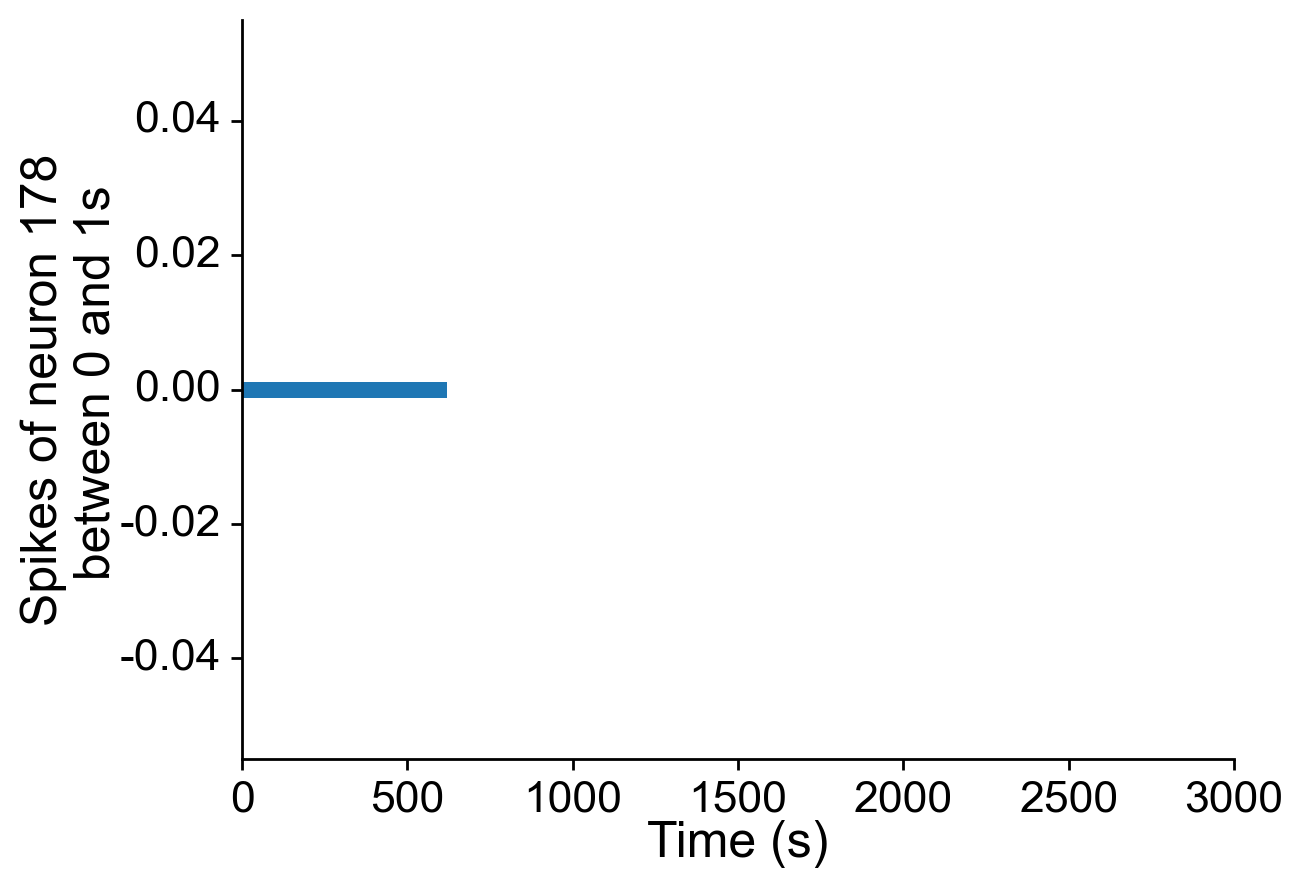

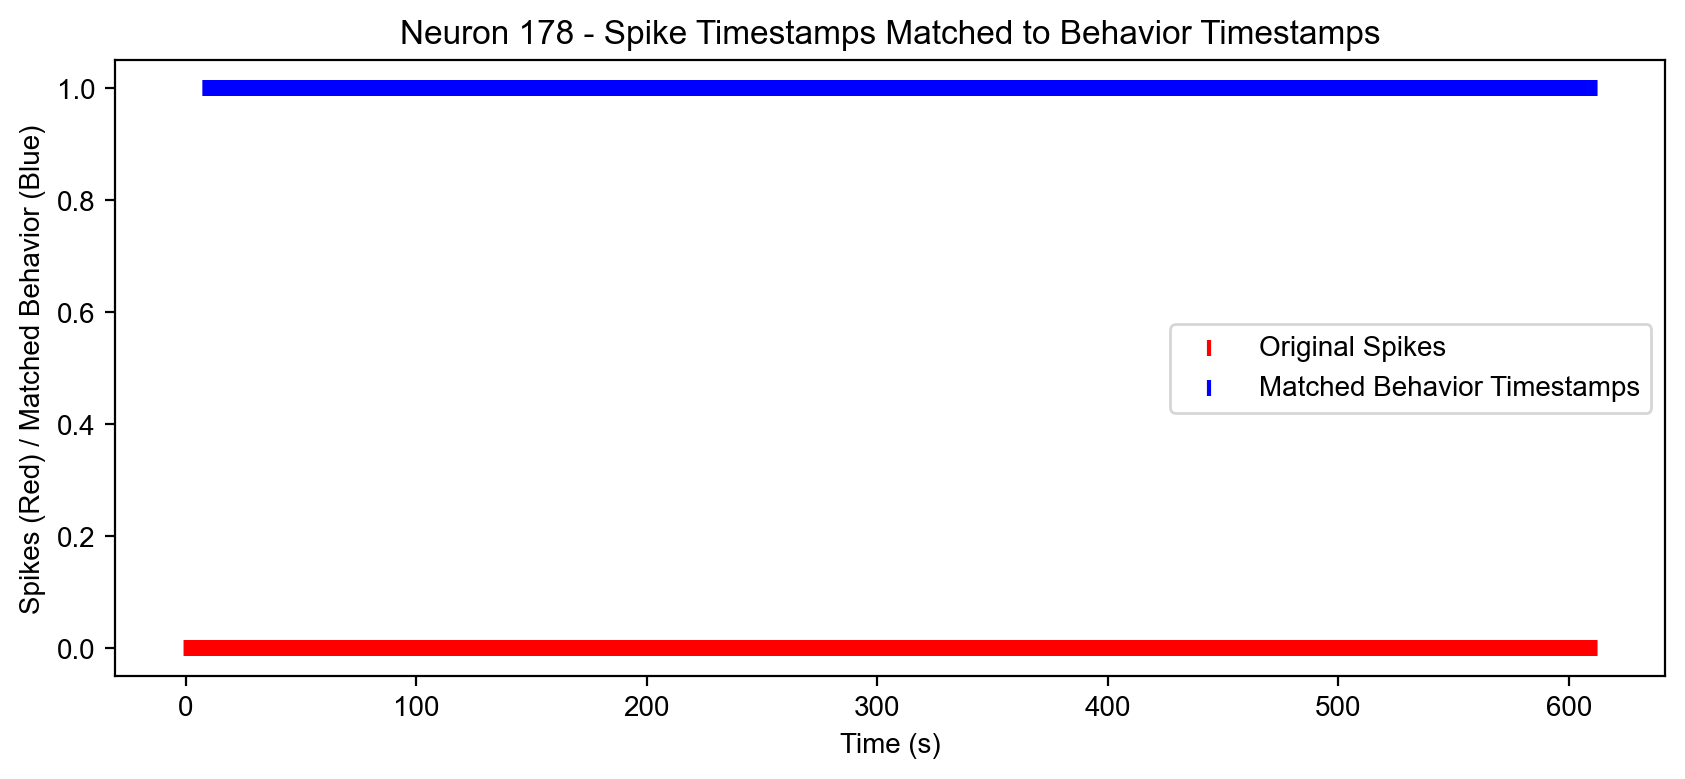

Neuron 180 has 5419 spikes.


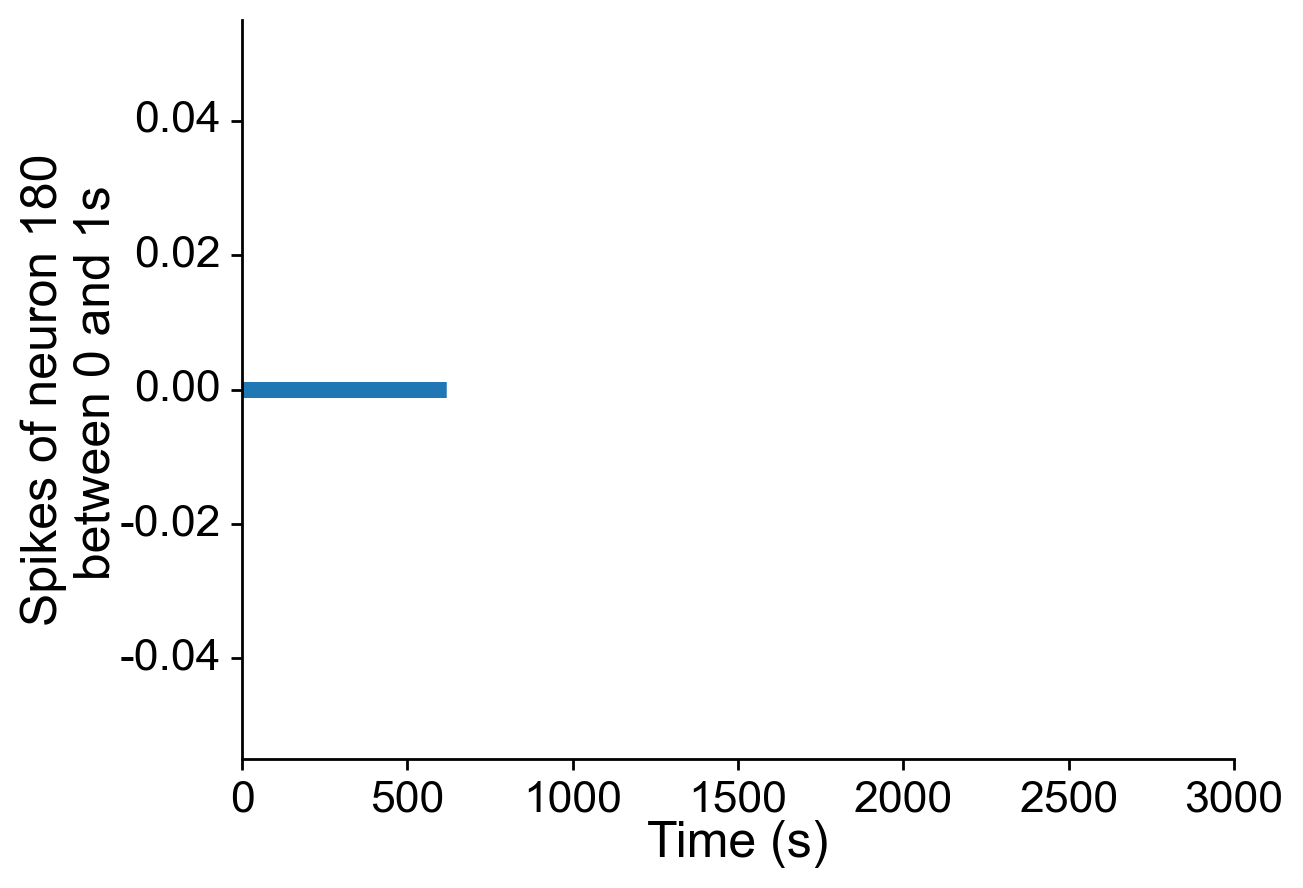

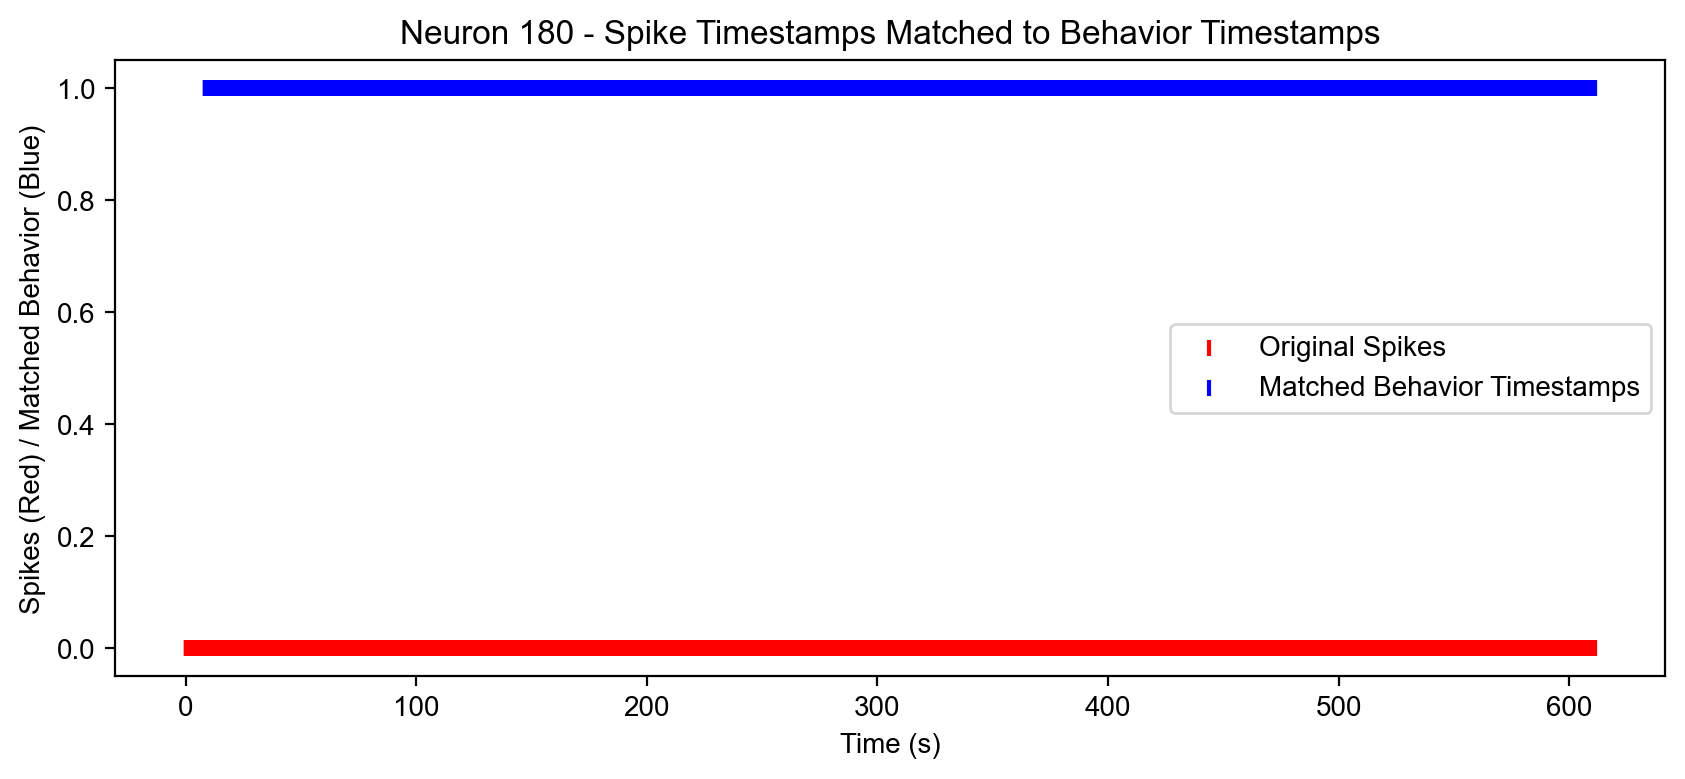

Neuron 187 has 99 spikes.


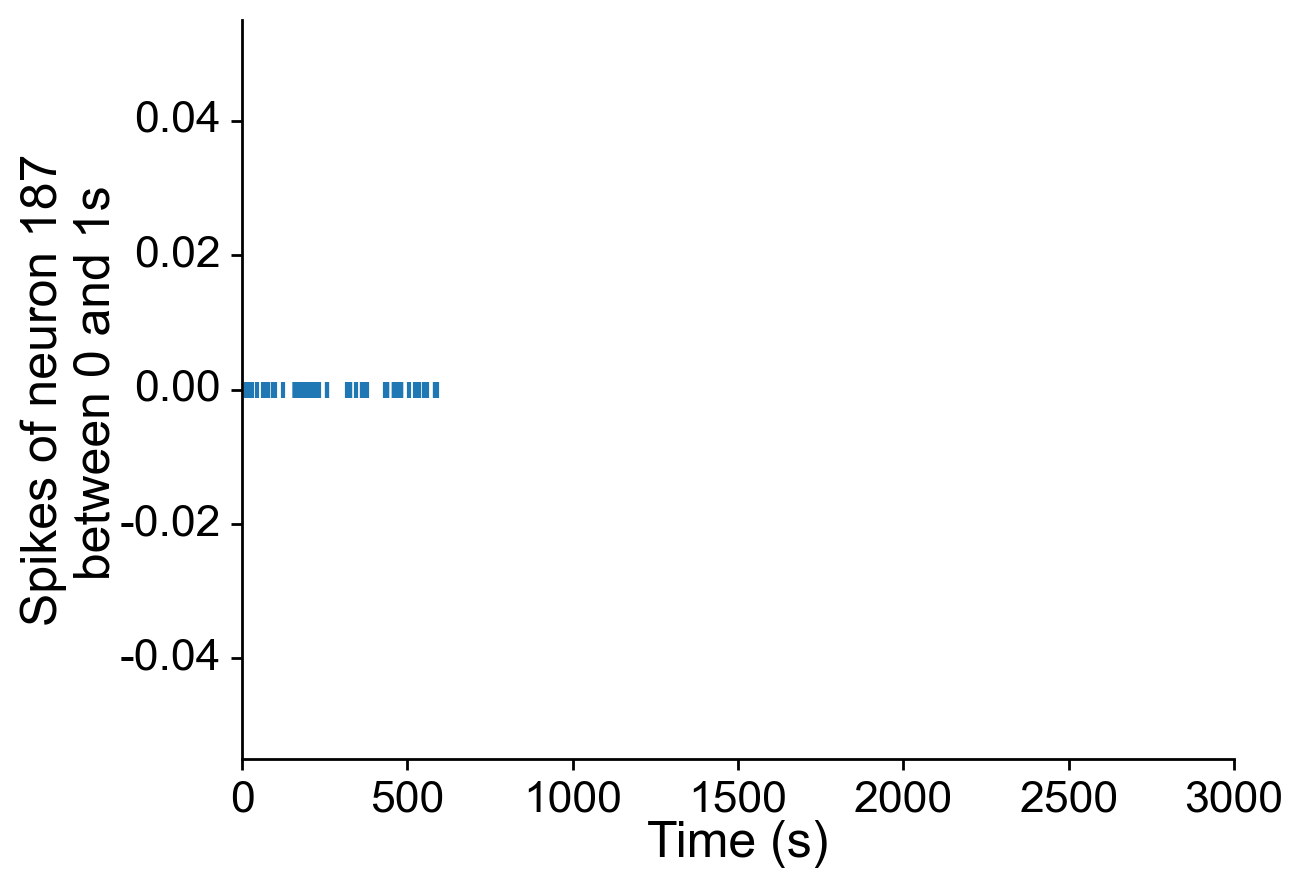

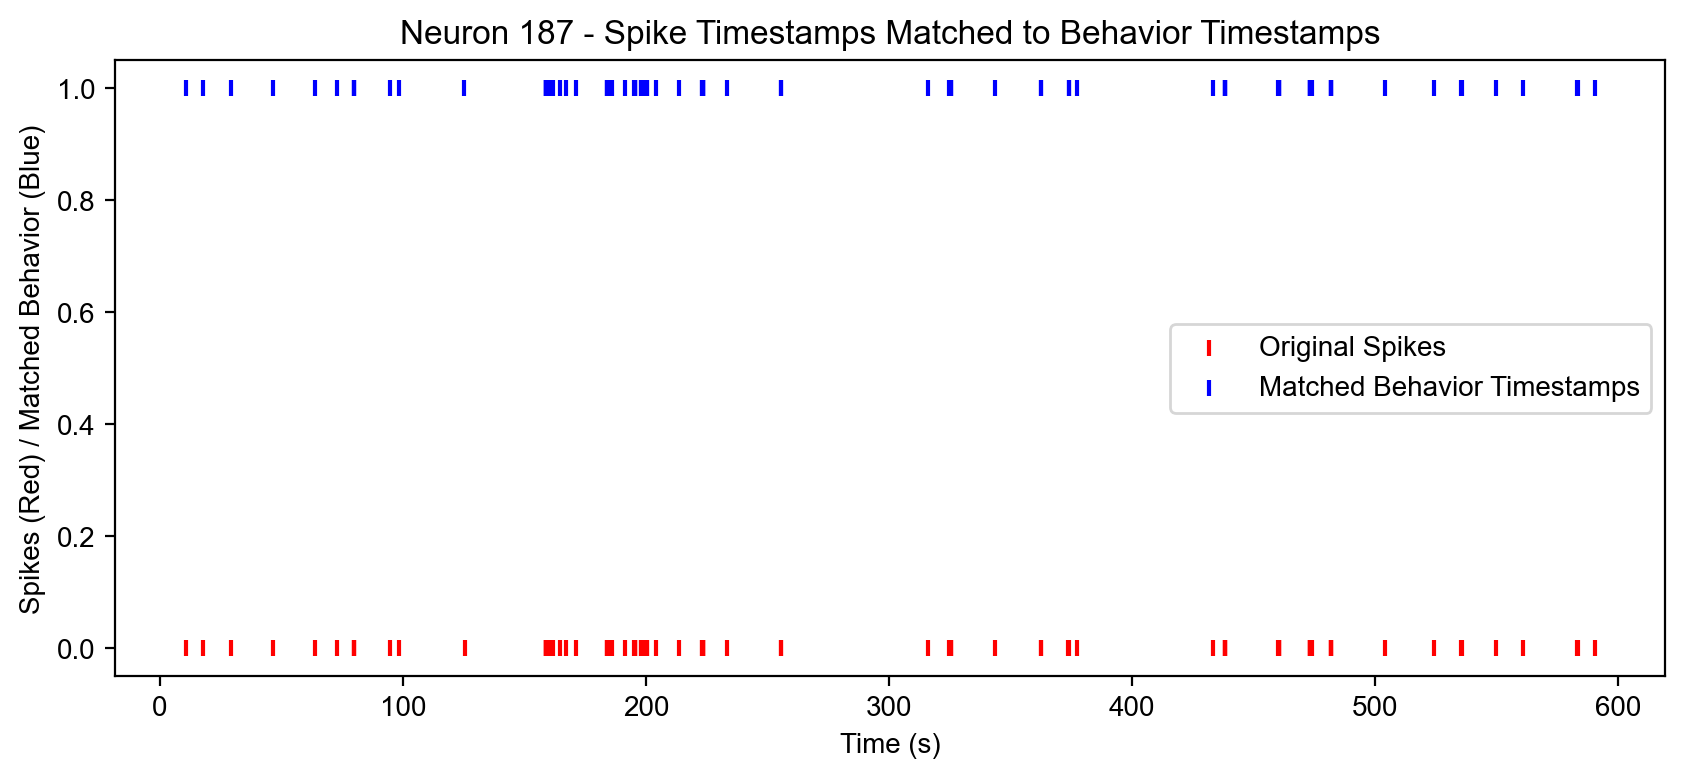

Neuron 191 has 10152 spikes.


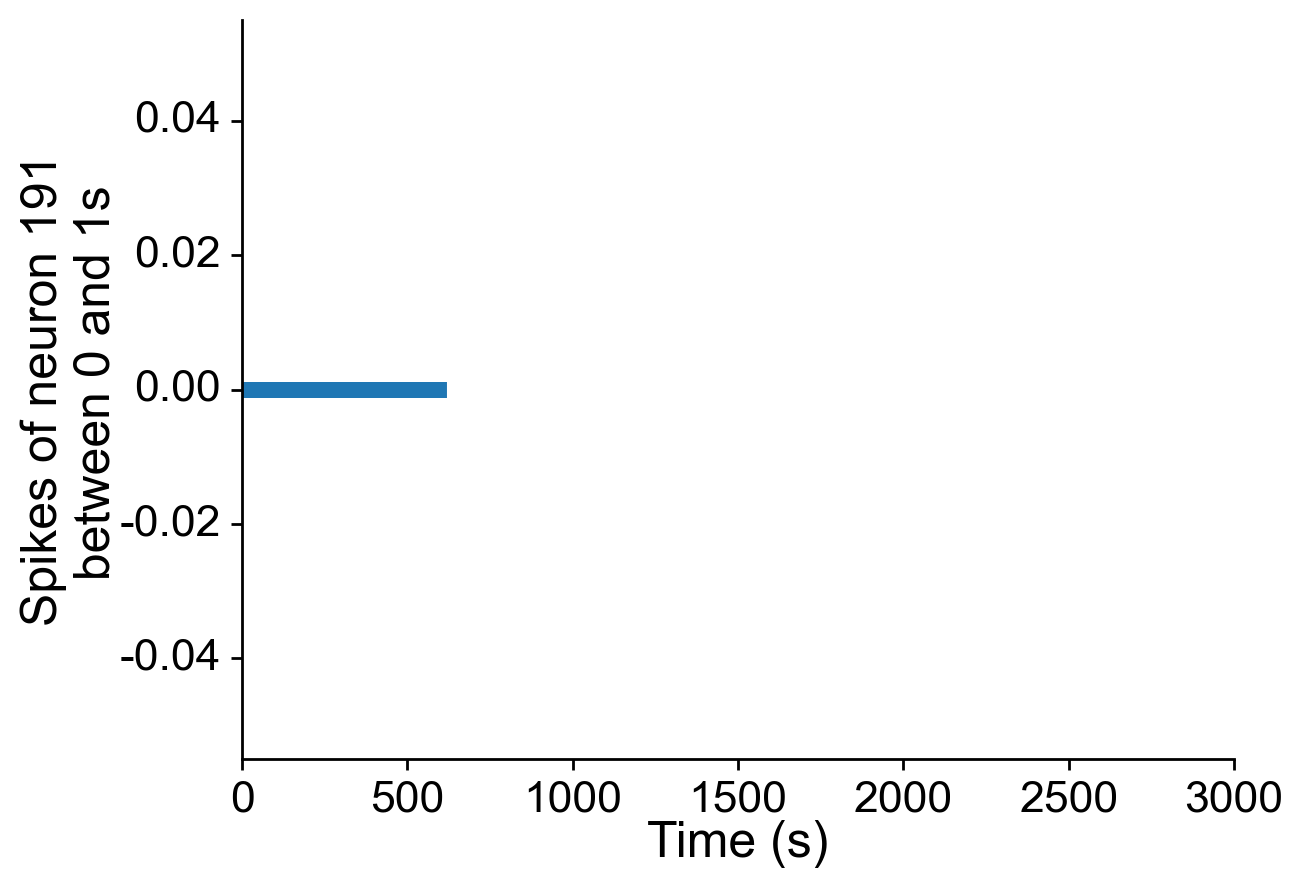

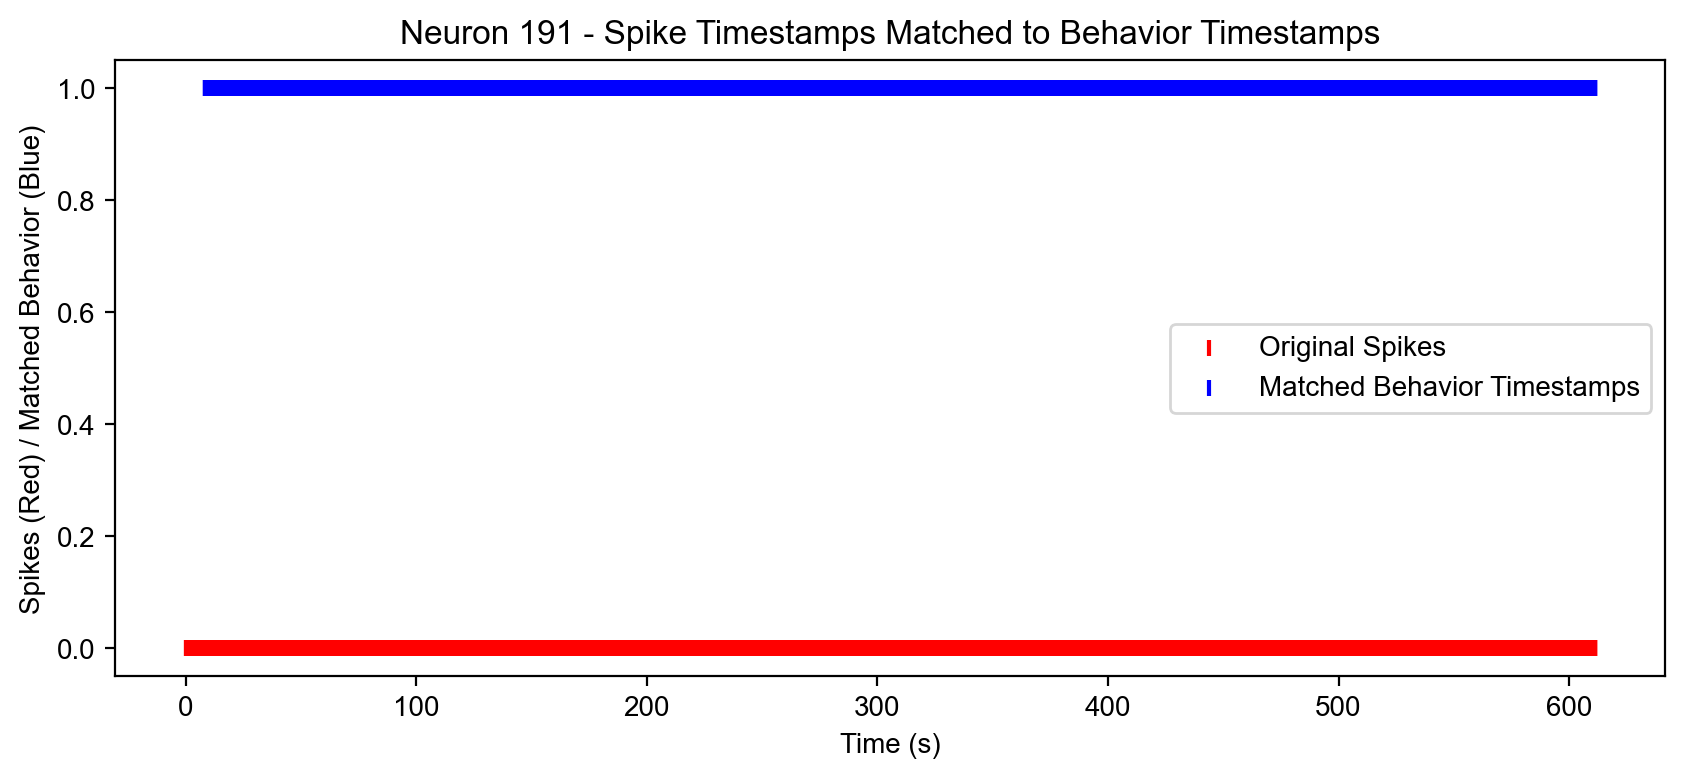

Neuron 193 has 8701 spikes.


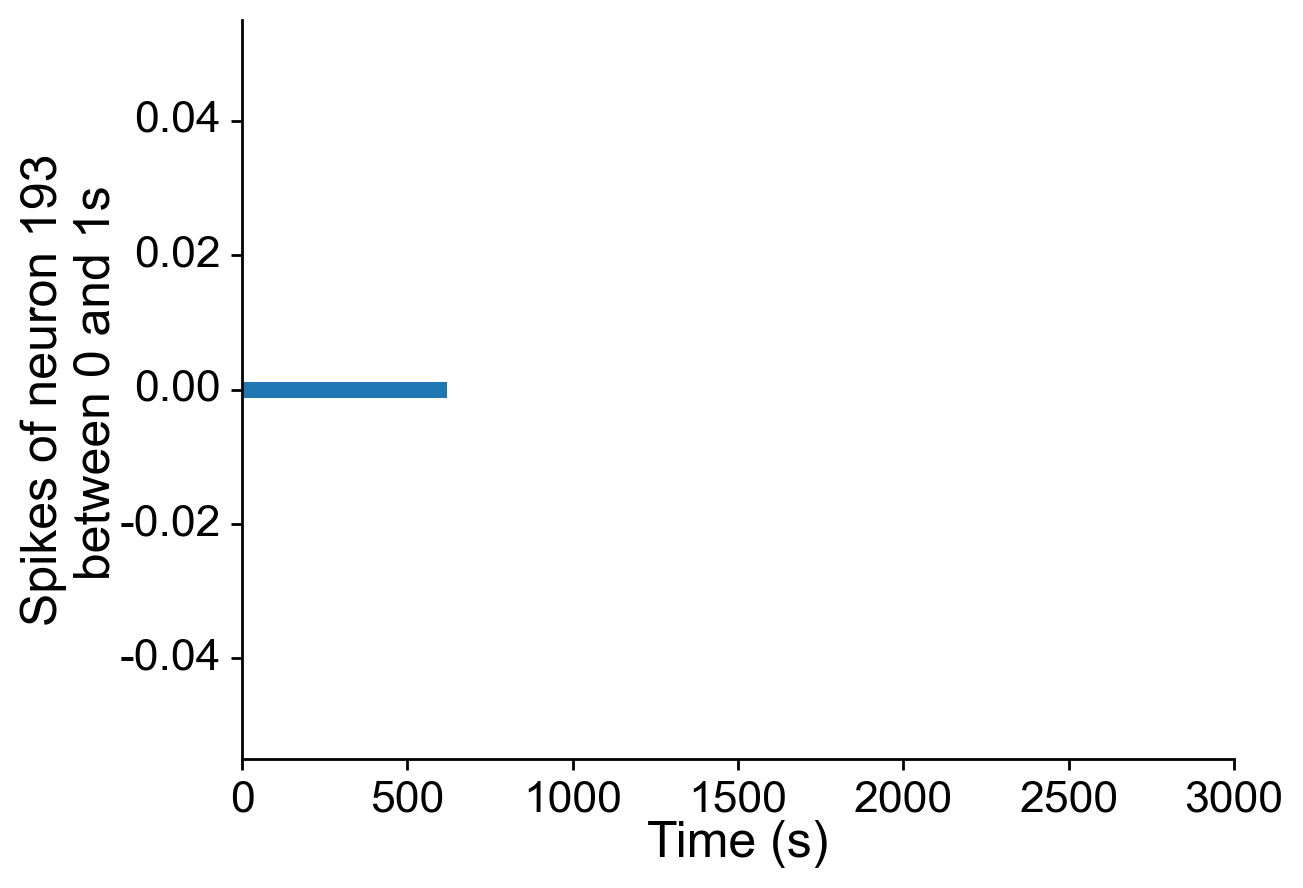

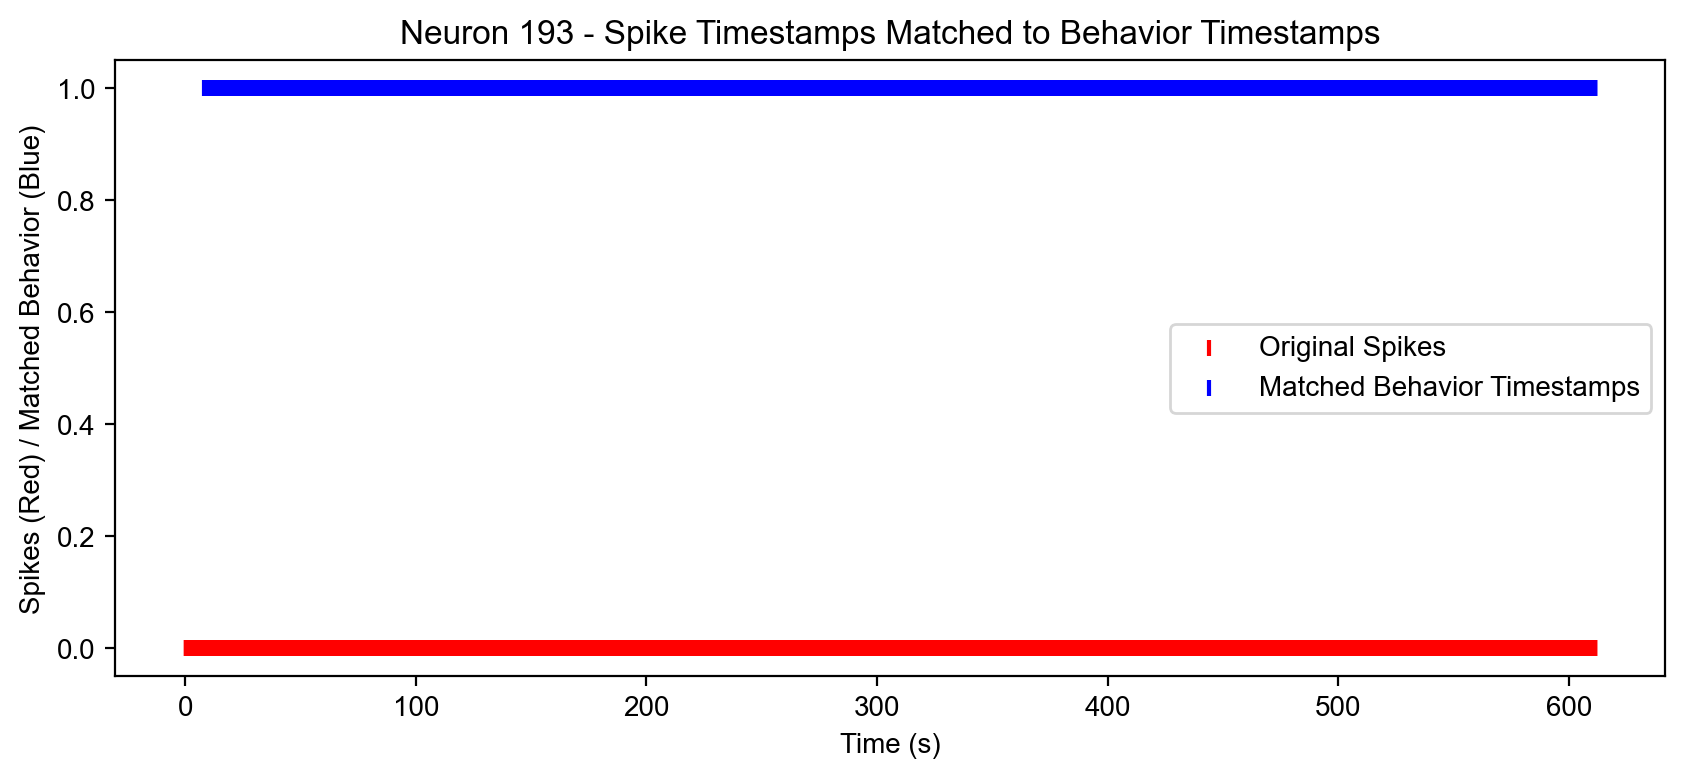

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Loop through all good units
for u in good_units:
    # Load spikes
    t = trn(dp, u)
    print(f"Neuron {u} has {t.shape[0]} spikes.")
    t = t / fs  # Convert from samples to seconds

    # Plot spike raster for the unit
    plt.scatter(t, t * 0, marker="|")
    fig = mplp(xlim=[0, 3000], ylabel=f"Spikes of neuron {u}\n between 0 and 1s", xlabel="Time (s)")
    plt.show()

    # Behavior timestamps (assumed to be already in seconds)
    behaviour_t = np.array(behaviour_t)  # Ensure it's a NumPy array

    # Initialize matched timestamps
    sp_t = []

    # Match each spike timestamp to the closest behavior timestamp
    for spike in t:
        idx = np.searchsorted(behaviour_t, spike)  # Find closest index

        if idx == 0:
            closest_t = behaviour_t[0]
        elif idx == len(behaviour_t):
            closest_t = behaviour_t[-1]
        else:
            before = behaviour_t[idx - 1]
            after = behaviour_t[idx]
            closest_t = before if abs(spike - before) < abs(spike - after) else after

        # Keep if close enough
        if abs(spike - closest_t) <= 0.04:
            sp_t.append(closest_t)

    sp_t = np.array(sp_t)

    # Plot matched timestamps
    plt.figure(figsize=(10, 4))
    plt.scatter(t, np.zeros_like(t), marker="|", color="r", label="Original Spikes")
    plt.scatter(sp_t, np.ones_like(sp_t), marker="|", color="b", label="Matched Behavior Timestamps")
    plt.xlabel("Time (s)")
    plt.ylabel("Spikes (Red) / Matched Behavior (Blue)")
    plt.legend()
    plt.title(f"Neuron {u} - Spike Timestamps Matched to Behavior Timestamps")
    plt.show()


Neuron 105 has 751 spikes.
Neuron 118 has 3895 spikes.
Neuron 124 has 3470 spikes.
Neuron 146 has 2005 spikes.
Neuron 148 has 1899 spikes.
Neuron 152 has 925 spikes.
Neuron 154 has 8801 spikes.
Neuron 160 has 2590 spikes.
Neuron 166 has 6976 spikes.
Neuron 178 has 20776 spikes.
Neuron 180 has 5419 spikes.
Neuron 187 has 99 spikes.
Neuron 191 has 10152 spikes.
Neuron 193 has 8701 spikes.


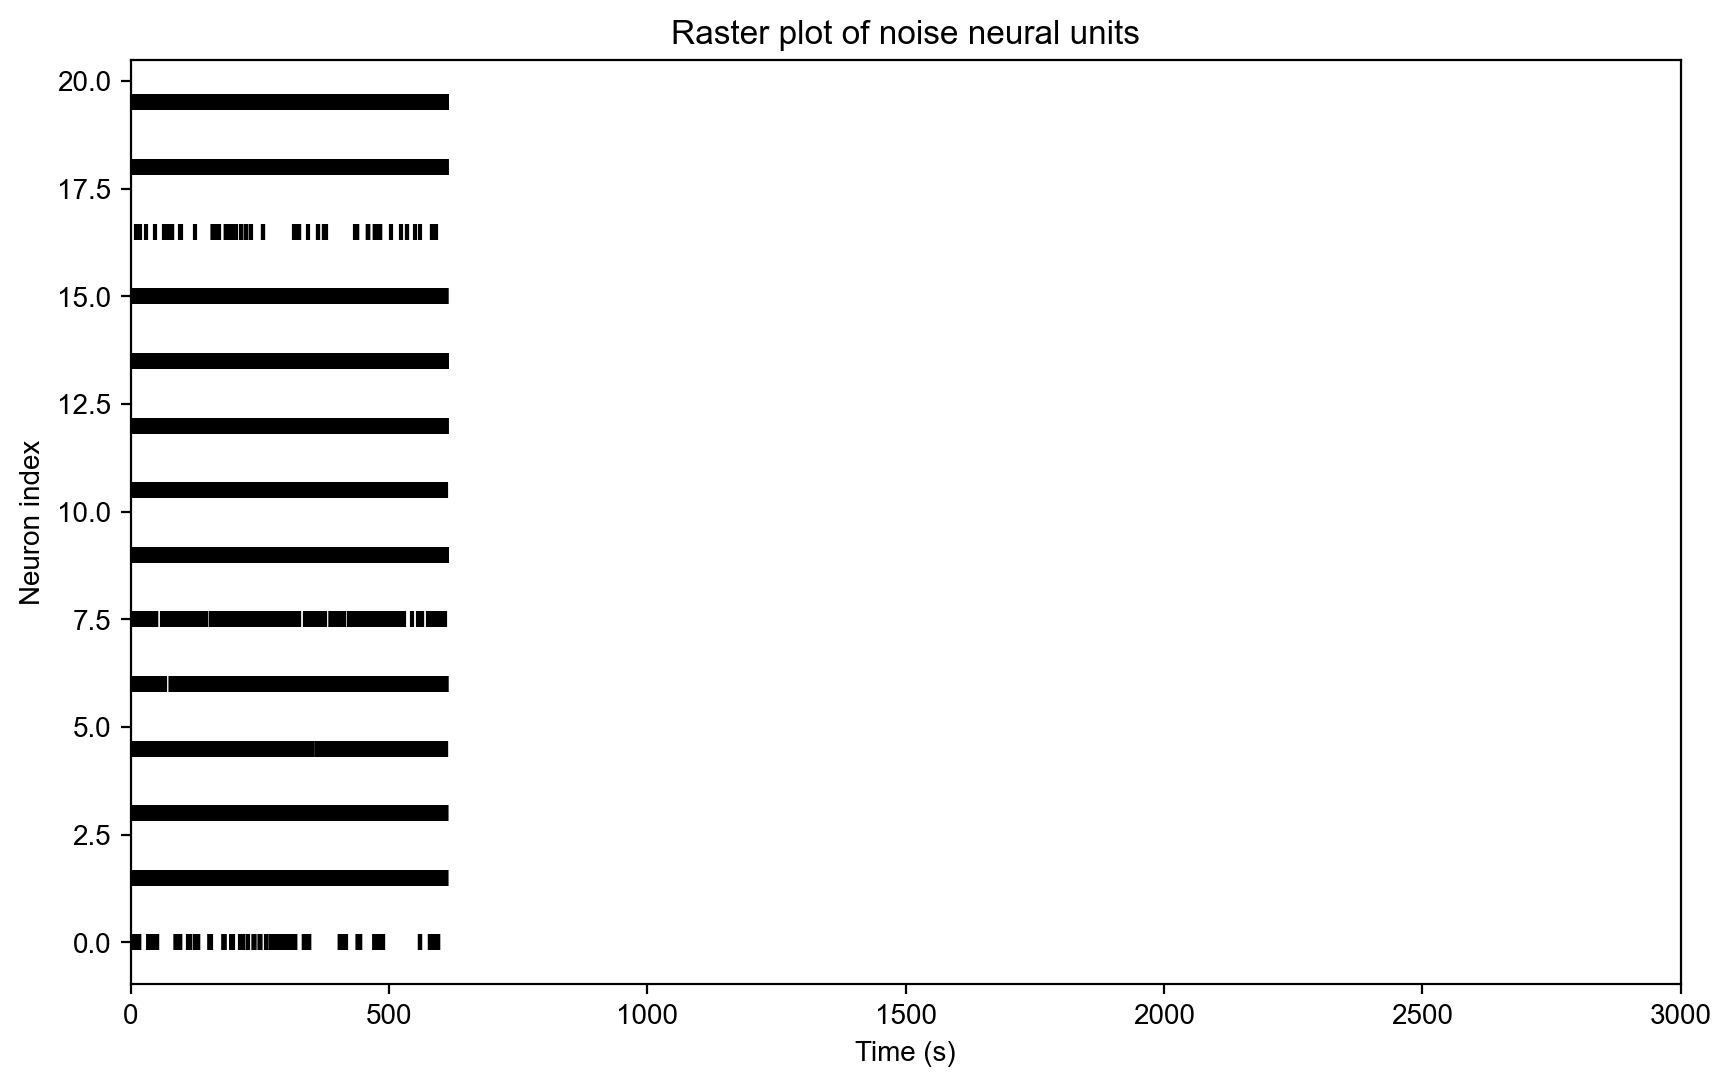

In [25]:
all_units = get_units(dp)
good_units = get_units(dp, "good")

ts_list = []  # List to store spike times for each unit

for i, u in enumerate(good_units):
    t = trn(dp, u) / fs  # Convert from samples to seconds
    ts_list.append((t, i * 1.5))  # Store spike times with vertical offset
    print(f"Neuron {u} has {t.shape[0]} spikes.")

# Plot raster
plt.figure(figsize=(10, 6))
for t, y_offset in ts_list:
    plt.scatter(t, [y_offset] * len(t), marker="|", color="black")

plt.xlim(0, 3000)
plt.xlabel("Time (s)")
plt.ylabel("Neuron index")
plt.title("Raster plot of noise neural units")
plt.show()

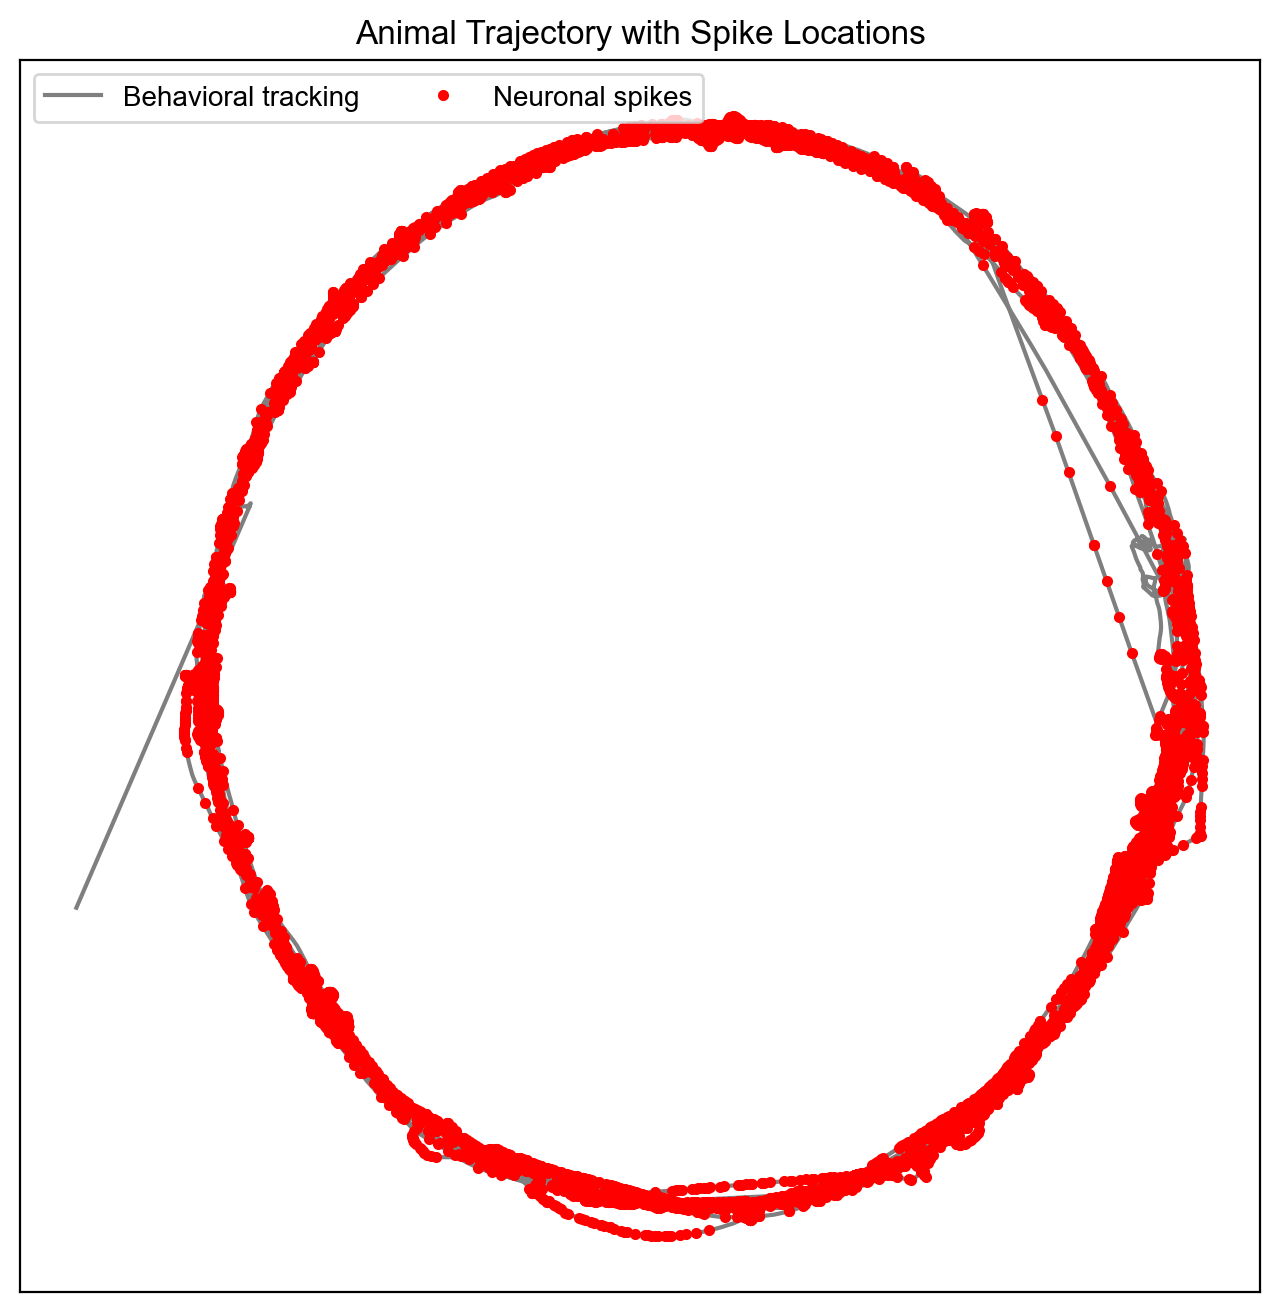

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Convert behavior timestamps to NumPy array if not already
behaviour_t = np.array(behaviour_t)

# Convert (x, y) coordinates to NumPy arrays
x_fin = np.array(x_fin)
y_fin = np.array(y_fin)

# Find indices in behaviour_t that correspond to sp_t
spike_indices = np.searchsorted(behaviour_t, sp_t)

# Remove indices that are out of bounds
valid_indices = spike_indices[(spike_indices >= 0) & (spike_indices < len(x_fin))]

# Plot behavior tracking and spike locations
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(x_fin, y_fin, 'k', label='Behavioral tracking', alpha=0.5)  # Plot full path in black
ax.plot(x_fin[valid_indices], y_fin[valid_indices], 'r.', label='Neuronal spikes')  # Plot spikes in red

# Formatting
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc='upper left', bbox_to_anchor=(0, 1), ncol=2)
ax.set_title("Animal Trajectory with Spike Locations")

plt.show()


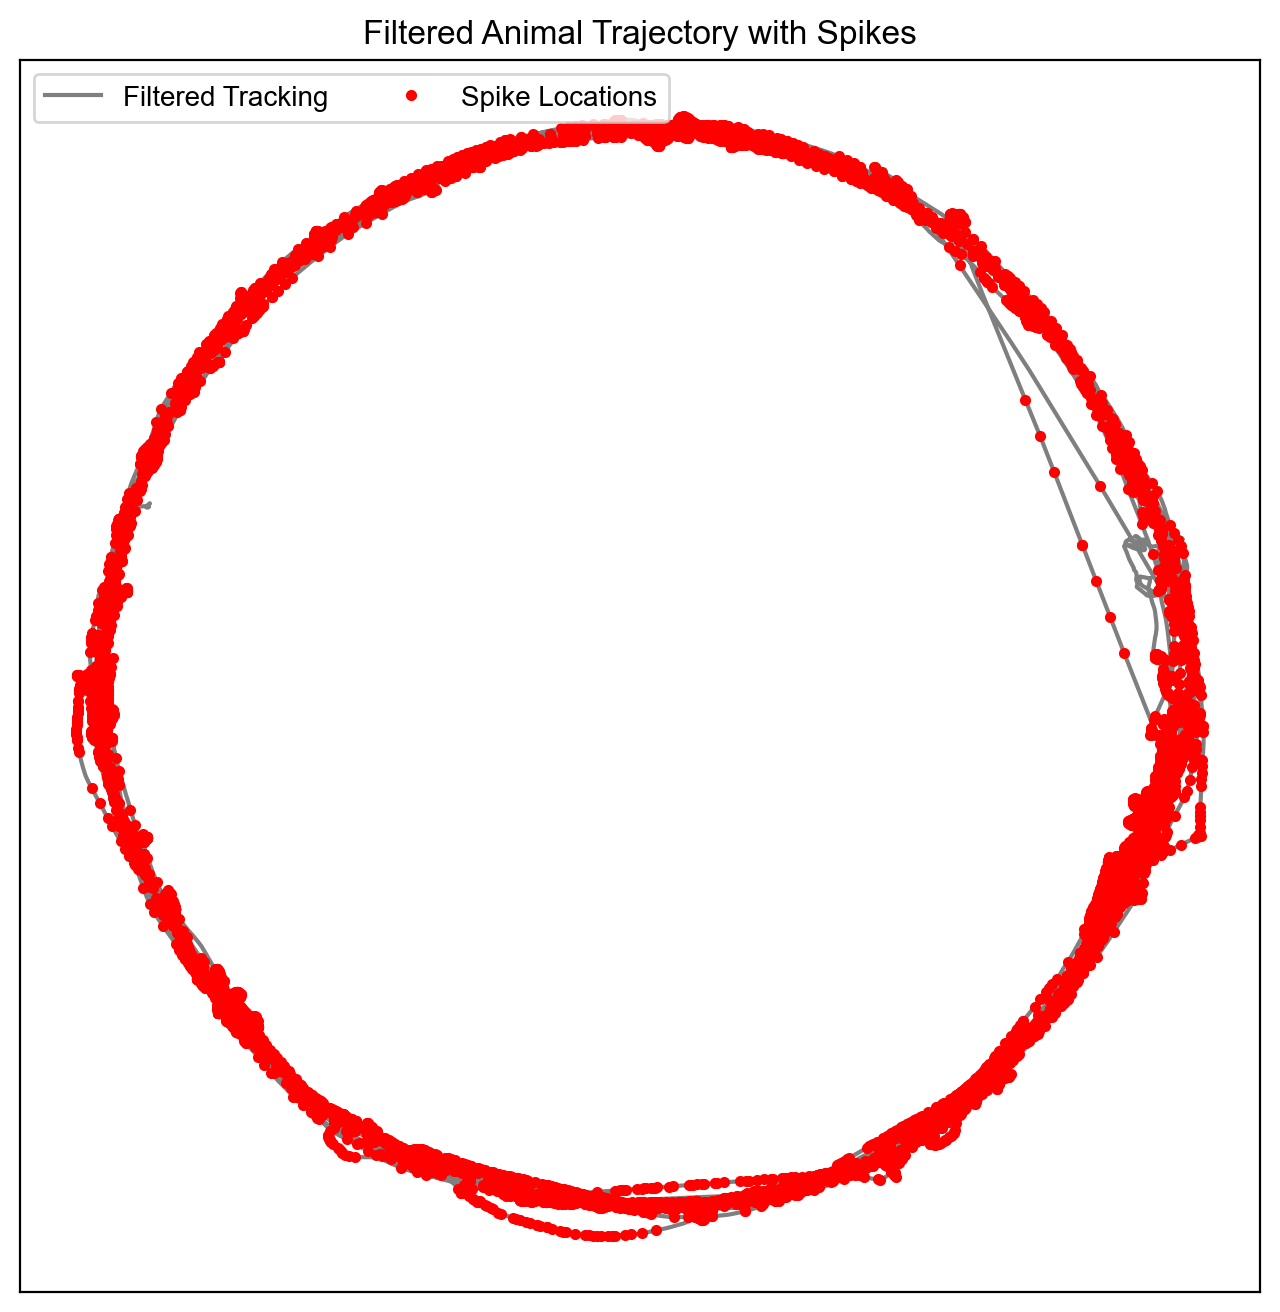

In [48]:
# Filtering by speed

import numpy as np
import matplotlib.pyplot as plt

# Convert to NumPy arrays
behaviour_t = np.array(behaviour_t)
x_fin = np.array(x_fin)
y_fin = np.array(y_fin)

# Compute time differences
dt = np.diff(behaviour_t)  # Time intervals between frames

# Compute Euclidean distance between consecutive points
dx = np.diff(x_fin)
dy = np.diff(y_fin)
distances = np.sqrt(dx**2 + dy**2)

# Compute speed (cm/s)
speed = distances / dt

# Define speed threshold (e.g., 100 cm/s)
speed_threshold = 1000  
valid_points = np.insert(speed < speed_threshold, 0, True)  # Keep first point

# Remove jumps by interpolation
x_filtered = np.interp(behaviour_t, behaviour_t[valid_points], x_fin[valid_points])
y_filtered = np.interp(behaviour_t, behaviour_t[valid_points], y_fin[valid_points])

# Find spike indices within valid range
spike_indices = np.searchsorted(behaviour_t, sp_t)
valid_indices = spike_indices[(spike_indices >= 0) & (spike_indices < len(x_filtered))]

# Plot the cleaned trajectory
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(x_filtered, y_filtered, 'k', alpha=0.5, label='Filtered Tracking')  
ax.plot(x_filtered[valid_indices], y_filtered[valid_indices], 'r.', label='Spike Locations')

# Formatting
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc='upper left', bbox_to_anchor=(0, 1), ncol=2)
ax.set_title("Filtered Animal Trajectory with Spikes")

plt.show()


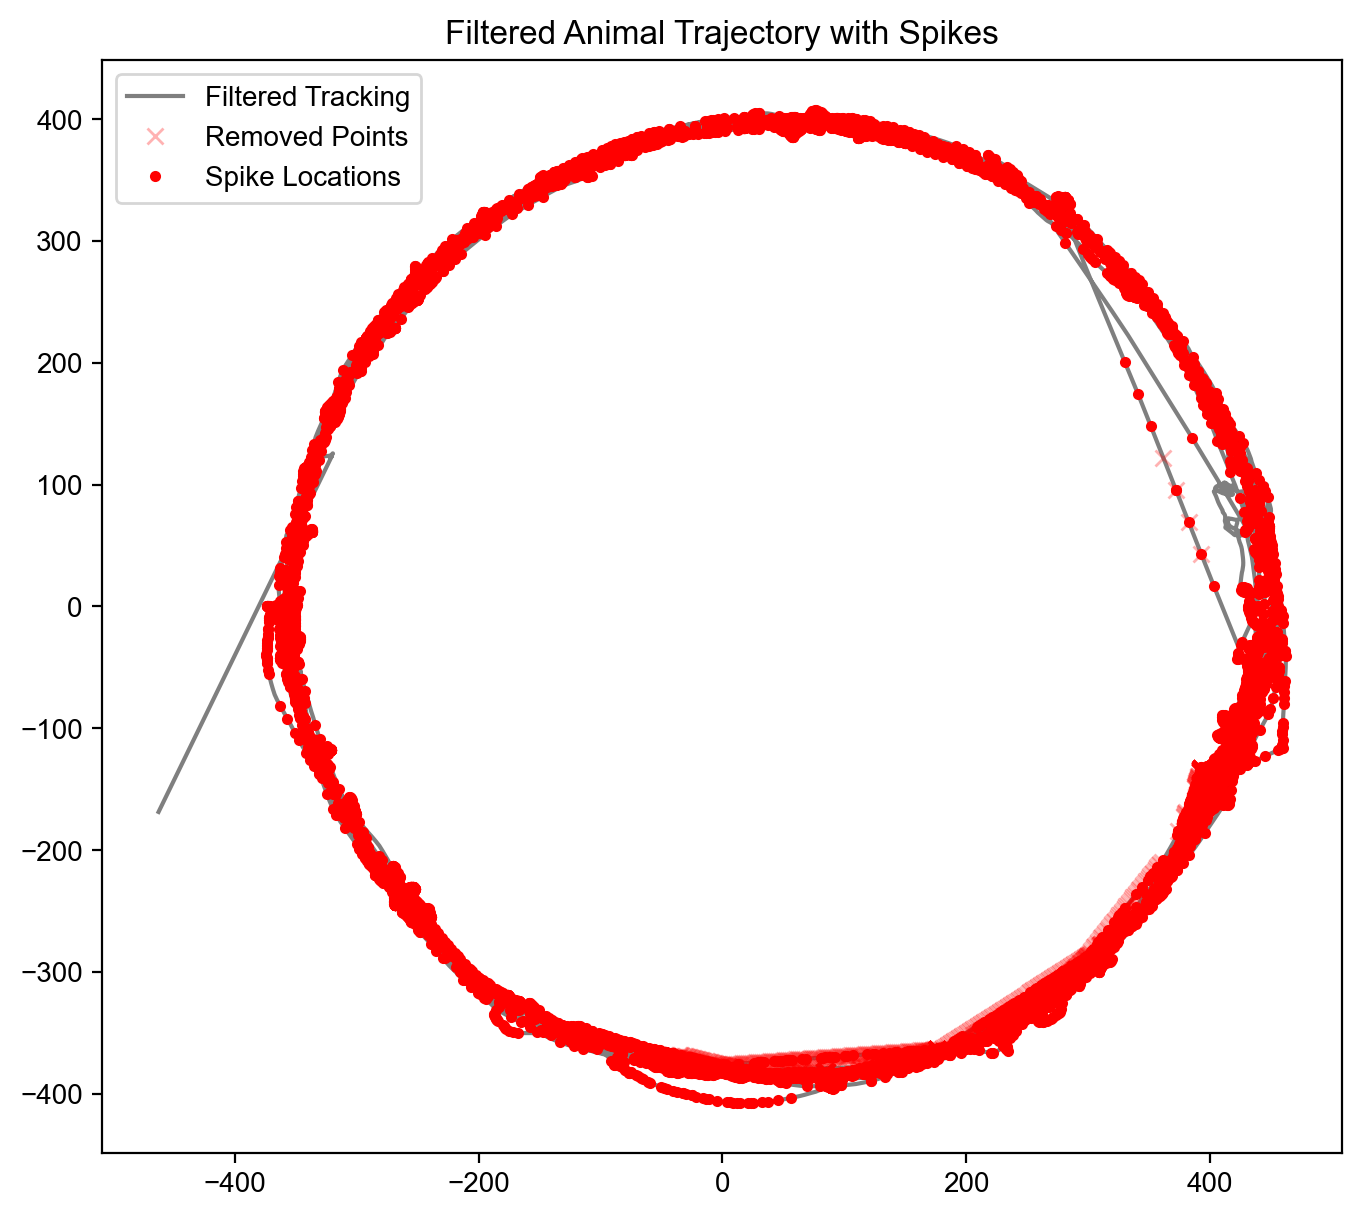

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to NumPy arrays
behaviour_t = np.array(behaviour_t)
x_fin = np.array(x_fin)
y_fin = np.array(y_fin)

# 1. Calculate distance from center to identify center jumps
center = np.array([np.mean(x_fin), np.mean(y_fin)])  # Estimate arena center
dist_from_center = np.sqrt((x_fin - center[0])**2 + (y_fin - center[1])**2)

# 2. Calculate median radius of trajectory (assuming mostly circular)
median_radius = np.median(dist_from_center)

# 3. Identify points that are too close to center (potential tracking errors)
center_threshold = median_radius * 0.9  # Adjust as needed
valid_points = dist_from_center > center_threshold

# 4. Filter based on both distance jumps AND center proximity
dx = np.diff(x_fin)
dy = np.diff(y_fin)
distances = np.sqrt(dx**2 + dy**2)
max_allowed_jump = median_radius * 0.2  # Adjust as needed

# Combine both criteria (first point is always valid)
distance_valid = np.insert(distances < max_allowed_jump, 0, True)
valid_points = valid_points & distance_valid

# 5. Interpolate missing points
x_fin = np.interp(behaviour_t, behaviour_t[valid_points], x_fin[valid_points])
y_fin = np.interp(behaviour_t, behaviour_t[valid_points], y_fin[valid_points])

# 6. Optionally: Project all points onto ideal circle if needed
# theta = np.arctan2(y_filtered - center[1], x_filtered - center[0])
# x_filtered = center[0] + median_radius * np.cos(theta)
# y_filtered = center[1] + median_radius * np.sin(theta)

# Plot results
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(x_fin, y_fin, 'k', alpha=0.5, label='Filtered Tracking')
ax.plot(x_fin[~valid_points], y_fin[~valid_points], 'rx', alpha=0.3, label='Removed Points')

# Add spike locations
spike_indices = np.searchsorted(behaviour_t, sp_t)
valid_indices = spike_indices[(spike_indices >= 0) & (spike_indices < len(x_filtered))]
ax.plot(x_fin[valid_indices], y_fin[valid_indices], 'r.', label='Spike Locations')

ax.set_aspect('equal')
ax.set_title("Filtered Animal Trajectory with Spikes")
ax.legend()
plt.show()

Average distance between consecutive points: 2.2336877509896276 units
Maximum distance between consecutive points: 46.346281323845126 units


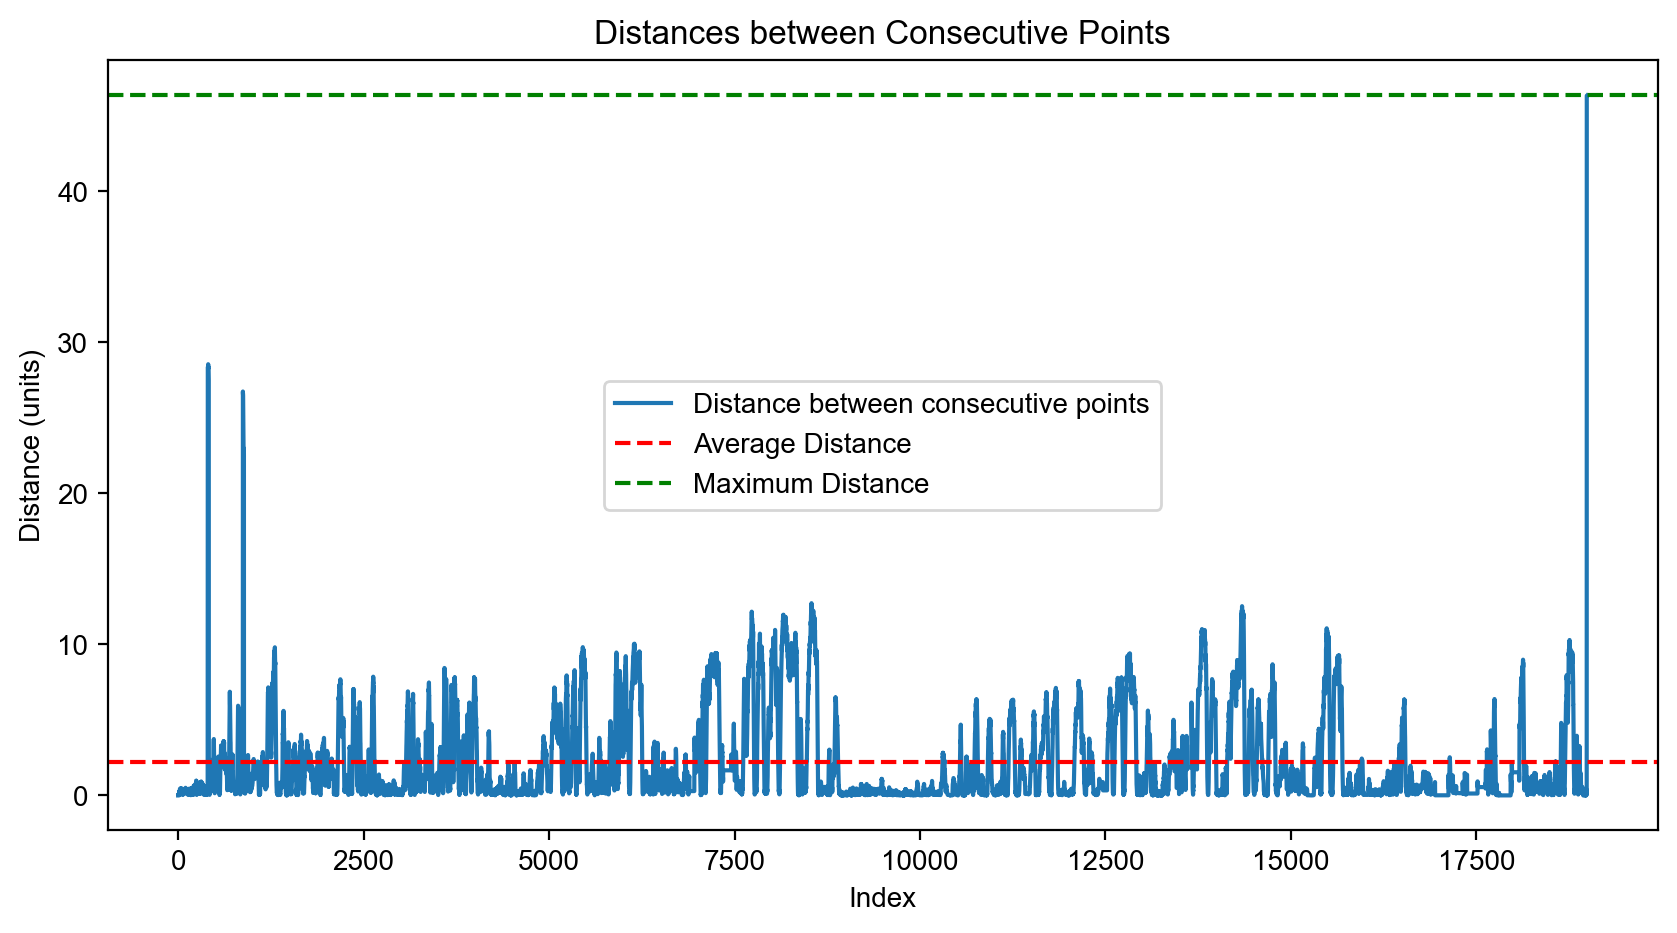

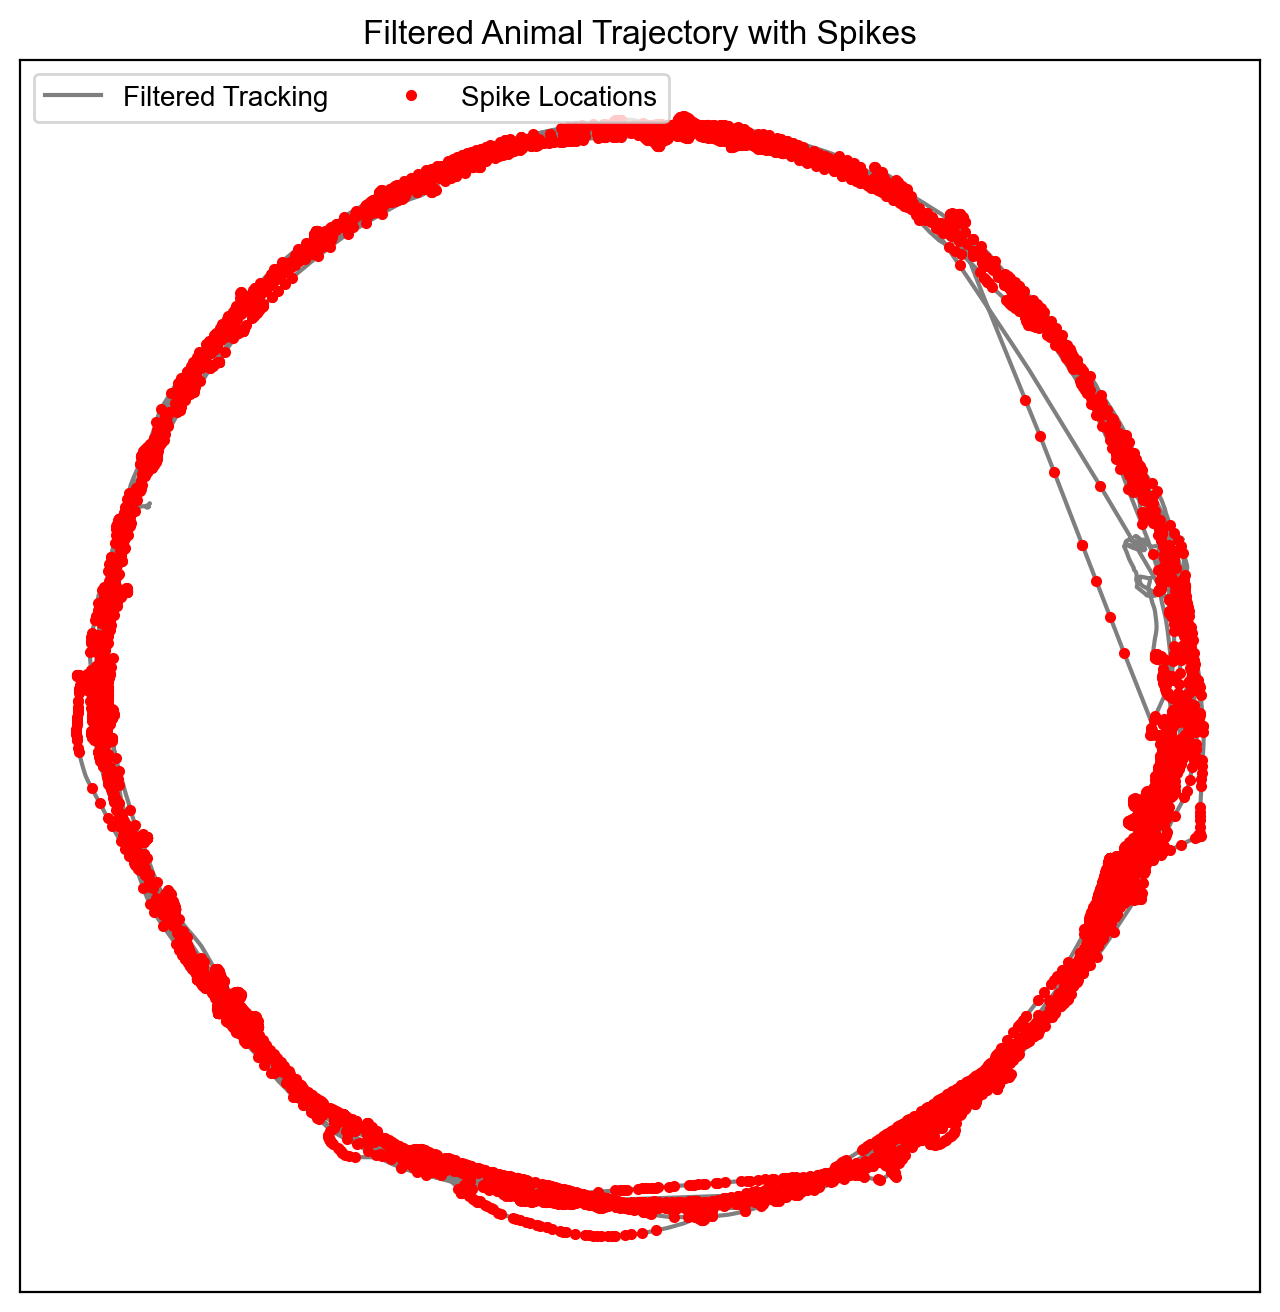

In [50]:
#Filtering by pixel value

import numpy as np
import matplotlib.pyplot as plt

# Convert to NumPy arrays
behaviour_t = np.array(behaviour_t)
x_fin = np.array(x_fin)
y_fin = np.array(y_fin)

# Compute the difference between consecutive x and y coordinates
dx = np.diff(x_fin)
dy = np.diff(y_fin)

# Compute Euclidean distance between consecutive points
distances = np.sqrt(dx**2 + dy**2)

# Calculate average and maximum distances
average_distance = np.mean(distances)
max_distance = np.max(distances)

print(f"Average distance between consecutive points: {average_distance} units")
print(f"Maximum distance between consecutive points: {max_distance} units")

# Plot the distances to visually inspect the jump sizes
plt.figure(figsize=(10, 5))
plt.plot(distances, label="Distance between consecutive points")
plt.axhline(y=average_distance, color='r', linestyle='--', label="Average Distance")
plt.axhline(y=max_distance, color='g', linestyle='--', label="Maximum Distance")
plt.xlabel("Index")
plt.ylabel("Distance (units)")
plt.title("Distances between Consecutive Points")
plt.legend()
plt.show()

# Define your threshold for maximum allowed jump
max_allowed_jump = 30 #max_distance * 0.25  # Set your own threshold here

# Filter out jumps that exceed the threshold
valid_points = np.insert(distances < max_allowed_jump, 0, True)  # Keep first point

# Apply the filter to x and y coordinates
x_filtered = np.interp(behaviour_t, behaviour_t[valid_points], x_fin[valid_points])
y_filtered = np.interp(behaviour_t, behaviour_t[valid_points], y_fin[valid_points])

# Find spike indices within valid range
spike_indices = np.searchsorted(behaviour_t, sp_t)
valid_indices = spike_indices[(spike_indices >= 0) & (spike_indices < len(x_filtered))]

# Plot the cleaned trajectory
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(x_filtered, y_filtered, 'k', alpha=0.5, label='Filtered Tracking')  
ax.plot(x_filtered[valid_indices], y_filtered[valid_indices], 'r.', label='Spike Locations')

# Formatting
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc='upper left', bbox_to_anchor=(0, 1), ncol=2)
ax.set_title("Filtered Animal Trajectory with Spikes")

plt.show()



In [51]:
# spatial matching of spikes ##################################################

import numpy as np

# Define bin size in cm
bin_size = 5  

# Convert x and y coordinates to binned spatial indices
bin_beh_x = (x_fin / bin_size).astype(int)   
bin_beh_y = (y_fin / bin_size).astype(int)

# Stack them into a single array
bin_beh = np.column_stack((bin_beh_x, bin_beh_y))  

# Find indices in behaviour_t that correspond to sp_t
spike_indices = np.searchsorted(behaviour_t, sp_t)

# Filter out indices that are out of bounds
valid_indices = spike_indices[(spike_indices >= 0) & (spike_indices < len(bin_beh))]

# Extract binned spike positions
bin_sp = bin_beh[valid_indices]

# Convert to integer
bin_sp = bin_sp.astype(int)

# Output
print(f"Binned behavioral coordinates: {bin_beh.shape}")
print(f"Binned spike coordinates: {bin_sp.shape}")


Binned behavioral coordinates: (18997, 2)
Binned spike coordinates: (8590, 2)


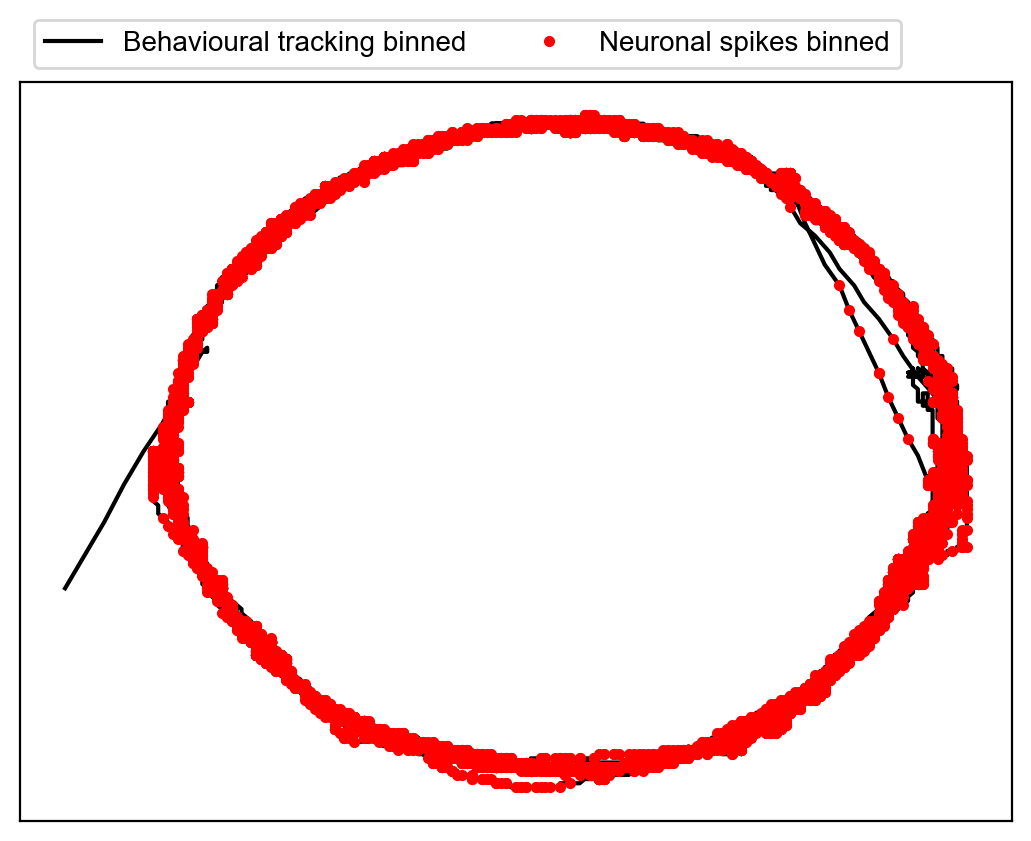

In [52]:
figure, ax = plt.subplots()
ax.plot(bin_beh.T[0], bin_beh.T[1],'k', label = 'Behavioural tracking binned')
ax.plot(bin_sp.T[0], bin_sp.T[1], 'r.', label = 'Neuronal spikes binned')
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc = 'lower left', bbox_to_anchor = (0, 1), ncol = 2)

In [53]:
# basic firing rate map #######################################################

# find visited bins -----------------------------------------------------------

visited_bins = []
  
for i in range(len(bin_beh)):
    
    if list(bin_beh[i]) not in visited_bins:
        visited_bins.append(list(bin_beh[i]))


# create basic rates -----------------------------------------------------------

bin_fr = np.zeros(len(visited_bins))

counter = 0
for i in visited_bins:
    
    spikes = np.where(bin_sp == i)[0]
    if len(spikes) == 0:
        bin_fr[counter] = 0.0
    else:
        beh_t = len(np.where(bin_beh == i)[0]) * (1/fps)

        bin_fr[counter] = len(spikes)/beh_t

    counter += 1


max_fr = max(bin_fr)
mean_fr = np.average(bin_fr)
        

Text(-20, 10, 'mean fr = 13.7')

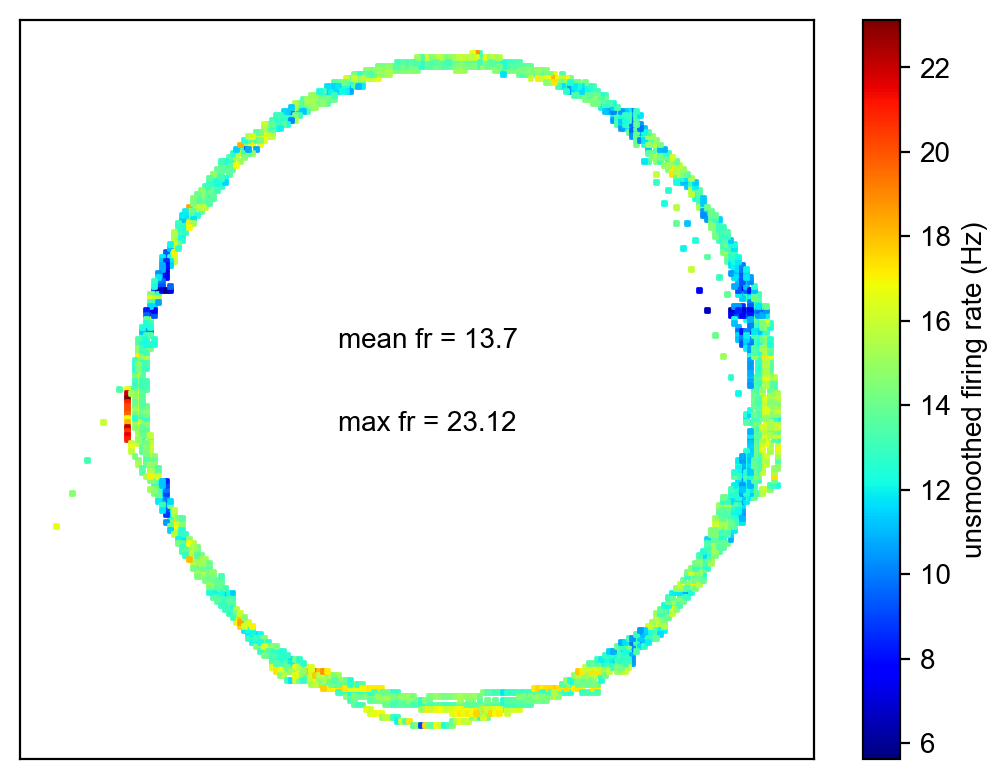

In [54]:
# plot basic firing rate map ##################################################

figure, ax = plt.subplots()
f = ax.scatter(np.transpose(visited_bins)[0], np.transpose(visited_bins)[1], 
               s = 2,c=bin_fr, marker = 's', cmap='jet')

ax.set_xticks([])
ax.set_yticks([])
figure.colorbar(f, label = 'unsmoothed firing rate (Hz)')

ax.text(-20,-10,'max fr = ' + str(round(max_fr,2)))
ax.text(-20,10,'mean fr = ' + str(round(mean_fr,2)))

In [34]:
# apply gaussian smoothing ####################################################

k = 3 # gaussian smoothing kernal
h = 5 # max distance to avvoid extrapolation error


# gaussian smooth behaviour ----------------------------------------------------    

beh_g = np.zeros(len(visited_bins))

counter = 0
for i in visited_bins:
    print(counter/len(visited_bins))
    
    beh_gt = []   
    for j in range(len(bin_beh)):
        
        xyt_dist = distance.euclidean(bin_beh[j], i) 
        
        if xyt_dist < h:
            xt = bin_beh[j][0]- i[0]
            yt = bin_beh[j][1]- i[1]
            beh_gt.append(1/(2*m.pi*k**2) * m.exp(-0.5 * (xt**2 + yt**2) /(k**2))) #apply behavioural gaussian
       
                          
    beh_g[counter] = np.trapz(beh_gt)        
    
    counter +=1
    



# gaussian smooth spikes -----------------------------------------------------
fr_s = np.zeros(len(visited_bins))

counter = 0

for i in visited_bins:
    
    print(counter/len(visited_bins))
    
    sp_gi = [0] *len(bin_sp) 
    
    for j in range(len(bin_sp)):
        
        xt = bin_sp[j][0]- i[0]
        yt = bin_sp[j][1]- i[1]
        sp_gi[j] = (1/(2*m.pi*k**2) * m.exp(-0.5 * (xt**2 + yt**2) /(k**2))) #apply behavioural gaussian   

    sp_g = sum(sp_gi) 
    
    if any(a ==0 for a in [beh_g[counter],sp_g]):
        fr_s[counter] = 0.0
    else:
        fr_s[counter] = sp_g/beh_g[counter]
        
    
    counter +=1



max_smooth_fr = max(fr_s)
mean_smooth_fr = np.average(fr_s)

0.0
0.00047596382674916705
0.0009519276534983341
0.0014278914802475012
0.0019038553069966682
0.002379819133745835
0.0028557829604950024
0.0033317467872441696
0.0038077106139933364
0.004283674440742504
0.00475963826749167
0.005235602094240838
0.005711565920990005
0.006187529747739172
0.006663493574488339
0.007139457401237506
0.007615421227986673
0.00809138505473584
0.008567348881485007
0.009043312708234174
0.00951927653498334
0.009995240361732508
0.010471204188481676
0.010947168015230843
0.01142313184198001
0.011899095668729176
0.012375059495478343
0.01285102332222751
0.013326987148976678
0.013802950975725845
0.014278914802475012
0.014754878629224179
0.015230842455973346
0.015706806282722512
0.01618277010947168
0.016658733936220846
0.017134697762970014
0.017610661589719183
0.018086625416468348
0.018562589243217516
0.01903855306996668
0.01951451689671585
0.019990480723465015
0.020466444550214184
0.020942408376963352
0.021418372203712517
0.021894336030461686
0.02237029985721085
0.02284626

In [35]:
# calculate spatial information rate ------------------------------------------

recording_length = (behaviour_t[-1] - behaviour_t[0])

sir_i  = [0.0]*len(visited_bins)
for i in range(len(visited_bins)):
    
    pi = (len(np.where(bin_beh == visited_bins[i])[0]) * 1/fps) / recording_length
    
    if fr_s[i]==0:
        sir_i[i] = 0.0
    else:
        sir_i[i] = pi * fr_s[i] * np.log2(fr_s[i]/mean_smooth_fr)
    
sir = sum(sir_i)

Text(-20, 15, 'sir = 1.03')

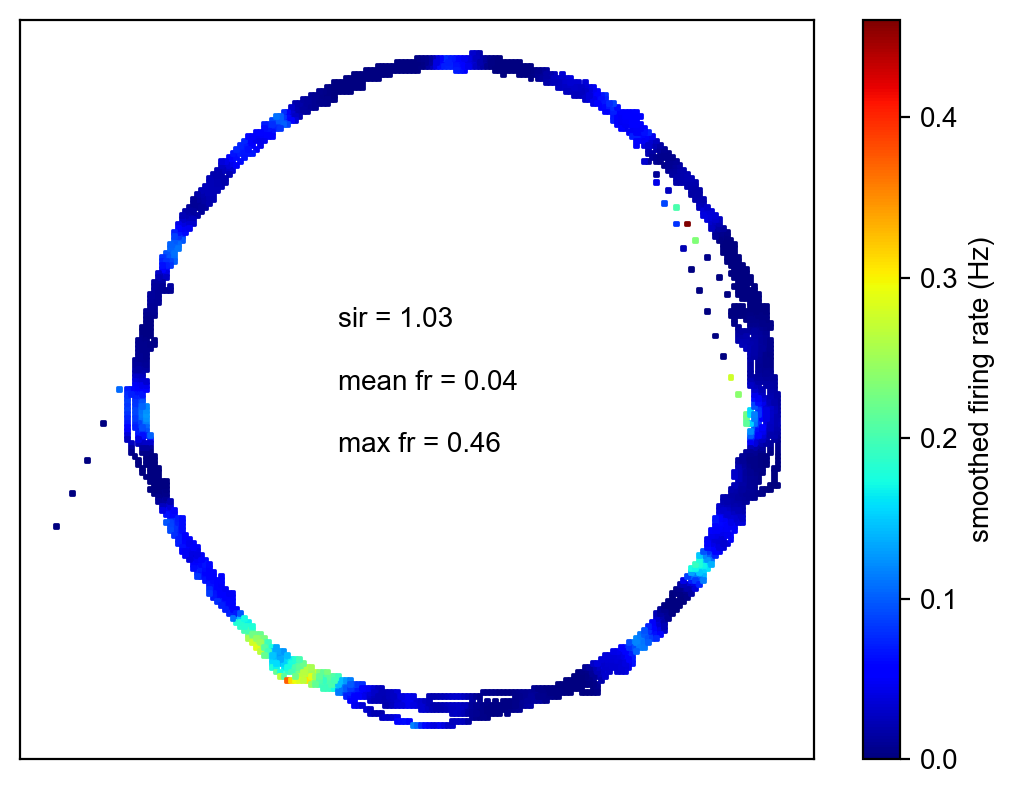

In [36]:
# plot smoothed firing rate map ###############################################

figure, ax = plt.subplots()
f = ax.scatter(np.transpose(visited_bins)[0], np.transpose(visited_bins)[1], 
               s = 2,c=fr_s, marker = 's', cmap='jet')

ax.set_xticks([])
ax.set_yticks([])
figure.colorbar(f, label = 'smoothed firing rate (Hz)')

ax.text(-20,-15,'max fr = ' + str(round(max_smooth_fr,2)))
ax.text(-20,0,'mean fr = ' + str(round(mean_smooth_fr,2)))
ax.text(-20,15,'sir = ' + str(round(sir,2)))


In [27]:
import numpy as np

# Compute movement vectors
dx = np.diff(x_fin)  # Change in x
dy = np.diff(y_fin)  # Change in y

# Compute heading direction (angle in radians)
heading_rad = np.arctan2(dy, dx)

# Convert to degrees
heading_deg = np.degrees(heading_rad)

# Ensure heading is in the range [0, 360] degrees
heading_deg = (heading_deg + 360) % 360

# Append NaN to keep same length as original x, y
#heading_deg = np.insert(heading_deg, 0, np.nan)

# Output example
print(f"Heading direction (first 10 values): {heading_deg[:10]}")


Heading direction (first 10 values): [ 20.77138634  20.82698584  20.82698584  20.86554168  20.95291603
  20.71955659  20.25581784 353.40607686   5.8048651  347.67497004]


In [28]:
import numpy as np

# Skip the first value in timestamps and coordinates
behaviour_t = behaviour_t[1:]  
x_fin = x_fin[1:]
y_fin = y_fin[1:]

# Compute movement vectors
dx = np.diff(x_fin)  # Change in x
dy = np.diff(y_fin)  # Change in y

# Compute heading direction (angle in radians)
heading_rad = np.arctan2(dy, dx)

# Convert to degrees
heading_deg = np.degrees(heading_rad)

# Ensure heading is in the range [0, 360] degrees
heading_deg = (heading_deg + 360) % 360

# Ensure timestamps match the heading direction length
behaviour_t = behaviour_t[:-1]  # Remove last timestamp to align

# Output example
print(f"Aligned Heading Direction (first 10 values): {heading_deg[:10]}")
print(f"Aligned Timestamps (first 10 values): {behaviour_t[:10]}")


Aligned Heading Direction (first 10 values): [ 20.82698584  20.82698584  20.86554168  20.95291603  20.71955659
  20.25581784 353.40607686   5.8048651  347.67497004 340.60349833]
Aligned Timestamps (first 10 values): [1288.0872   1288.120534 1288.153867 1288.1872   1288.220534 1288.253867
 1288.2872   1288.320534 1288.353867 1288.3872  ]


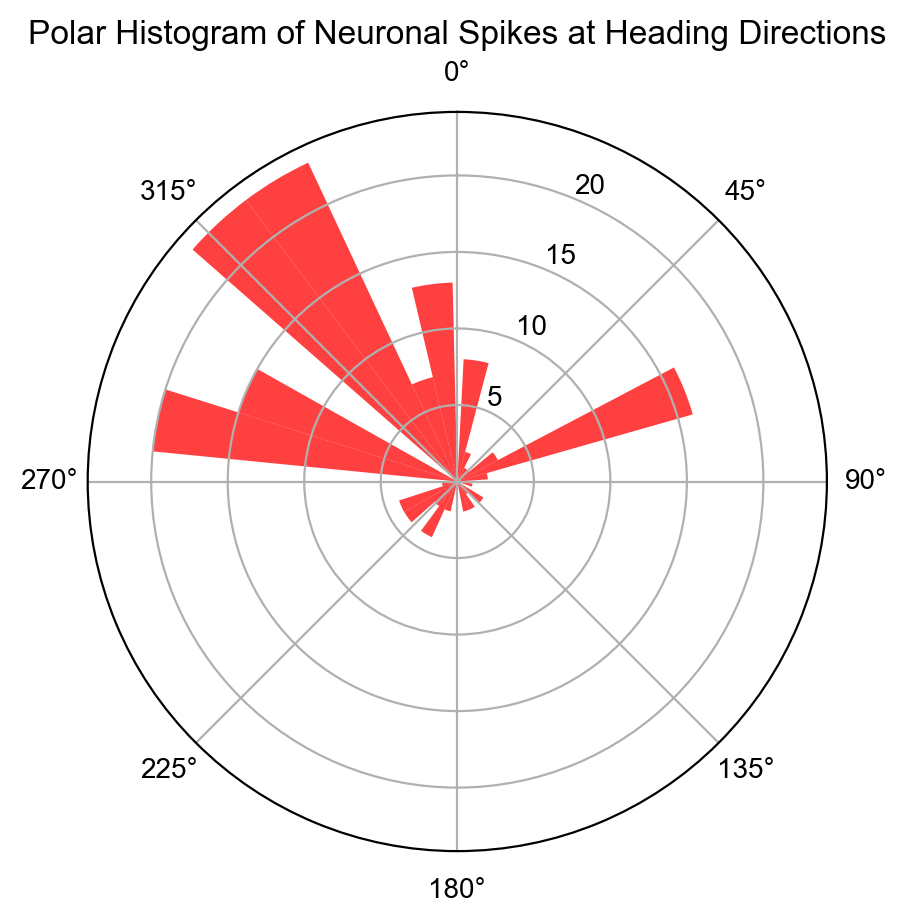

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure spike times and behavior times are NumPy arrays
spike_timestamps = np.array(spike_timestamps)
behaviour_t = np.array(behaviour_t)
heading_deg = np.array(heading_deg)  # Heading directions in degrees

# Match each spike timestamp to the closest behavior timestamp
sp_t = []
sp_heading = []  # Store heading direction at spike times

for spike in spike_timestamps:
    idx = np.searchsorted(behaviour_t, spike)  # Find closest index
    
    # Find the closest behavior timestamp
    if idx == 0:
        closest_t = behaviour_t[0]
    elif idx == len(behaviour_t):
        closest_t = behaviour_t[-1]
    else:
        before = behaviour_t[idx - 1]  # Previous behavior timestamp
        after = behaviour_t[idx]  # Next behavior timestamp
        
        # Pick the closer one
        closest_t = before if abs(spike - before) < abs(spike - after) else after

    # Check if the difference is within 0.04 seconds
    if abs(spike - closest_t) <= 0.04:
        sp_t.append(closest_t)
        sp_heading.append(heading_deg[idx])  # Get heading direction at spike time

# Convert to NumPy array
sp_heading = np.array(sp_heading)

# Convert degrees to radians for polar plot
sp_heading_rad = np.radians(sp_heading)

# Plot polar histogram
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.hist(sp_heading_rad, bins=30, color='r', alpha=0.75)  # Histogram of spike angles

ax.set_theta_zero_location('N')  # 0° at the top
ax.set_theta_direction(-1)  # Clockwise rotation

ax.set_title("Polar Histogram of Neuronal Spikes at Heading Directions")
plt.show()


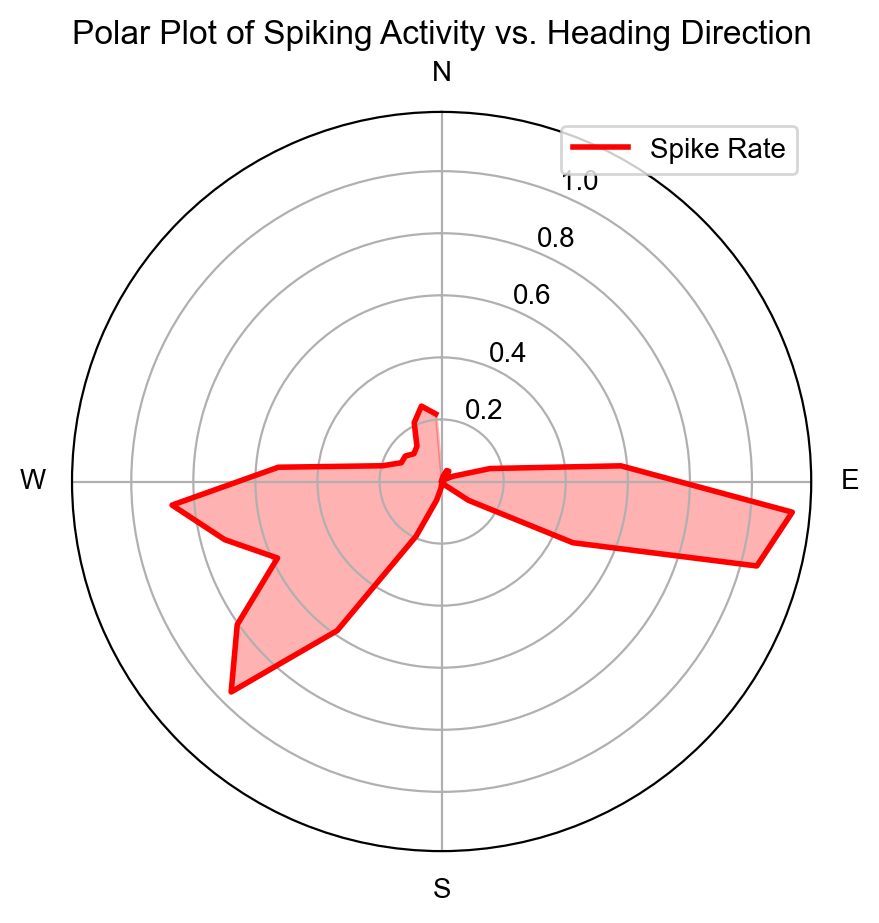

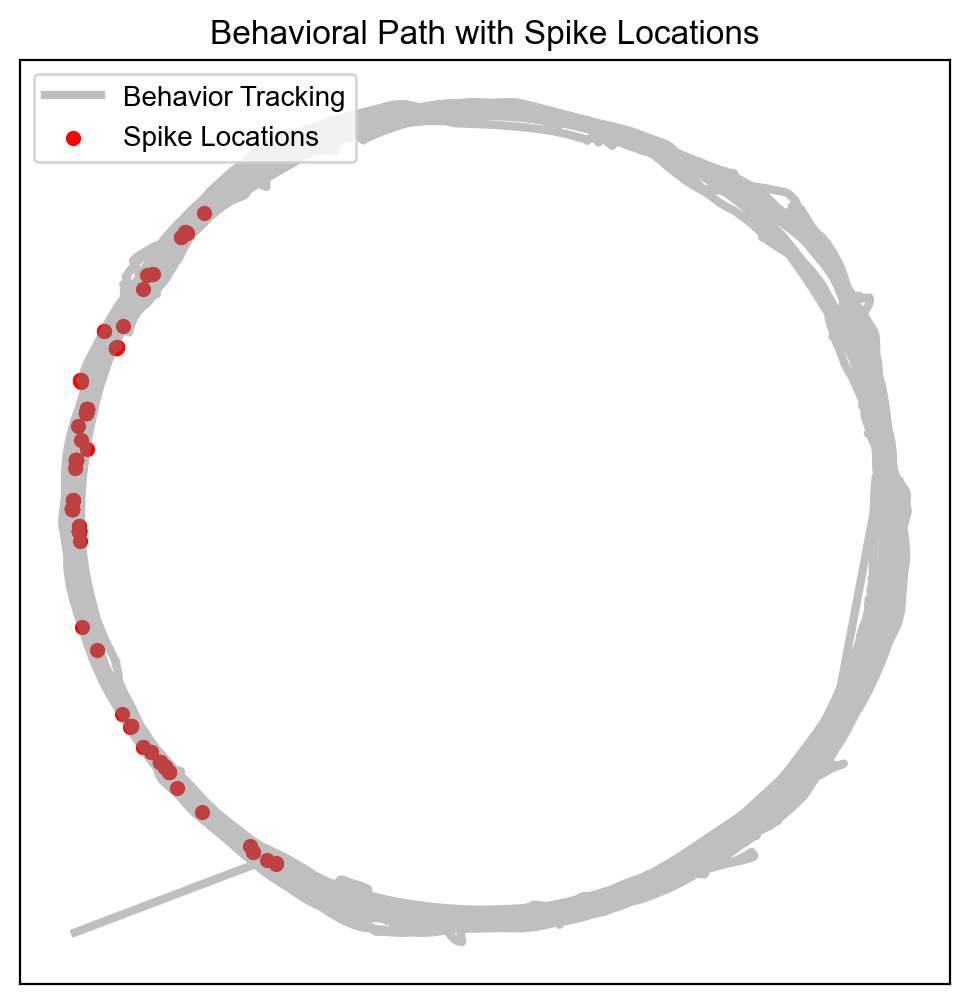

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Sampling rate
sampling_rate = 30  # Hz

# Compute heading direction
posgx, posgy = x_fin[:-1], y_fin[:-1]  # Remove last point to align shift
posrx, posry = np.roll(posgx, -1), np.roll(posgy, -1)  # Next position

# Compute heading in degrees
heading_deg = np.mod(np.degrees(np.arctan2(-(posry - posgy), posrx - posgx)), 360)

# Ensure sp_t contains valid integer indices
sp_t = np.array(sp_t, dtype=int)

# Match spikes to heading direction
spike_headings = heading_deg[sp_t]

# Define bins for heading directions
bin_size = 10  # Degrees
bins = np.arange(0, 370, bin_size)  # 0 to 360 degrees
bin_centers = bins[:-1] + bin_size / 2  # Center of bins

# Compute histogram for spike counts and occupancy
spike_counts, _ = np.histogram(spike_headings, bins=bins)
occupancy, _ = np.histogram(heading_deg, bins=bins)

# Convert to spike rate (spikes per second)
spike_rate = spike_counts / (occupancy / sampling_rate)
spike_rate = np.nan_to_num(spike_rate)  # Replace NaNs with zero
smoothed_rate = gaussian_filter1d(spike_rate, sigma=1)  # Smooth data

# Convert bin centers to radians
angles_rad = np.radians(bin_centers)

# Polar plot of spike rate vs. heading direction
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(angles_rad, smoothed_rate, color='r', linewidth=2, label="Spike Rate")
ax.fill_between(angles_rad, 0, smoothed_rate, color='r', alpha=0.3)

ax.set_theta_zero_location('N')  # North = 0 degrees
ax.set_theta_direction(-1)  # Clockwise rotation
ax.set_xticks(np.radians([0, 90, 180, 270]))  # Label directions
ax.set_xticklabels(['N', 'E', 'S', 'W'])
ax.set_title("Polar Plot of Spiking Activity vs. Heading Direction")
plt.legend()
plt.show()

# Plot behavioral tracking with spikes
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(x_fin, y_fin, color='gray', alpha=0.5, linewidth=3, label='Behavior Tracking')
ax.scatter(x_fin[sp_t], y_fin[sp_t], color='red', s=20, label='Spike Locations')

ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc='upper left')
ax.set_title("Behavioral Path with Spike Locations")
plt.show()


Ignore the rest

Compute auto/crosscorrelogram between 2 units

In [36]:
from npyx.corr import ccg, ccg_stack

# returns ccg between 234 and 92 with a binsize of 0.2 and a window of 80
c = ccg(dp, [1,2], cbin=0.2, cwin=80)

# Only using spikes from the first and third minutes of recording
c = ccg(dp, [1,2], cbin=0.2, cwin=80, periods=[(0,60), (120,180)])

# better, compute a big stack of crosscorrelograms with a given name
# The first time, CCGs will be computed in parallel using all the available CPU cores
# and it will be saved in the background and, reloadable instantaneously in the future
source_units = [1,2,3,4,5]
target_units = [6,7,8,9,10]
c_stack = ccg_stack(dp, source_units, target_units, 0.2, 80, name='my_relevant_ccg_stack')
c_stack = ccg_stack(dp, name='my_relevant_ccg_stack') # will work to reaload in the future

TypeError: ccg() got an unexpected keyword argument 'cbin'

### 1.4 - Load spike waveforms

In [37]:
# load waveform
waveforms = wvf(dp, u)
spikes, samples, channels = waveforms.shape
print(f"wvf() returns an array of shape {spikes} spikes by {samples} samples (time) by {channels} channels.")

# Find peak channel
peak_channel = waveforms.mean(0).max(0).argmax()
print(f"We define the peak channel as the channel with maximum amplitude: here {peak_channel}")

# Plot
w_time = np.arange(samples) * 1000 / fs
w = waveforms.mean(0)[:,peak_channel]
w_s = waveforms.std(0)[:,peak_channel]
plt.fill_between(w_time, w+w_s, w-w_s, alpha=0.4)
plt.plot(w_time, w, color="k")
fig = mplp(title = f"Unit {u} peaking on channel {peak_channel}", xlabel = "Time (ms)", ylabel = "Voltage (uV)")

WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
Invalid times: [37507295 37507458 37777094 37778040 37778513 37779575 37779828 37780039
 37780173 37780329 39824025 39824166 39828763 39845431 39856518 39870835
 40204228 40204777 40205308 40205861 40957488 40959284 41018473 41018861
 41019022 41019166 41036195 41036524 41036697 41047

TypeError: expected str, bytes or os.PathLike object, not NoneType

### Or you can directly plot them, according to your probe's channel map:

In [38]:
# it will find the peak channel by itself
fig = plot_wvf(dp, u, Nchannels=12, t_waveforms=2.8)

WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
Invalid times: [19050837 33630294 33665477 33665999 33670170 33671628 33698692 35672173
 36978500 36978668 36980075 38442413 38443350 38443821 38444267 38456261
 38470888 38471522 38472204 38472362 38472621 39305947 39306311 39306478
 39377292 39377450 39377632 39383834 39388942 39389

TypeError: expected str, bytes or os.PathLike object, not NoneType

### 1.5 Load raw data

In [39]:
# Load raw data
raw_data_chunk = extract_rawChunk(dp, [0, 0.07])
channels, samples = raw_data_chunk.shape
print(f"extract_rawChunk() returns an array of shape {channels} channels x {samples} samples ({round(samples/30)}ms)")
plt.plot(np.arange(samples)/30, raw_data_chunk[peak_channel], color='k')
plt.scatter(t* 1000, t * 0 - 250, color="red", marker="^", lw=3, s=20)
fig = mplp(figsize = (12,4), title = f"Spikes of unit {u} on channel {peak_channel}", xlim = [0, samples * 1000 / fs], ylim = [-300, 200],
           xlabel = "Time (ms)", ylabel = "Voltage (uV)")

extract_rawChunk() returns an array of shape 384 channels x 2100 samples (70ms)


NameError: name 'peak_channel' is not defined

### or you can directly overlay the spikes of one or several unit on the raw data!

In [40]:
fig = plot_raw_units(dp, times=[0,0.07], units = [14, u], channels = np.arange(50),
               colors=['royalblue', 'orangered'], yticks_jump = 1, figsize=(6,10),
               offset=450,  Nchan_plot=10)

WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat


KeyError: 'highpass'

## 2 - Processing Neuropixels data

### 2.1 - Raw data preprocessing

In [41]:
fig = plot_raw(dp, times=[0,0.07], channels = np.arange(7),
               yticks_jump = 1, figsize=(12,6), legend="raw")
fig = plot_raw(dp, times=[0,0.07], channels = np.arange(7),
               
               whiten=False, med_sub=False, hpfilt=True, hpfiltf=1500, nRangeWhiten=None, nRangeMedSub=None, use_ks_w_matrix=False, # <<<<<
               
               color = 'red', ax = fig.get_axes()[0], legend="High-pass filtered at 1500 Hz")

WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat


KeyError: 'highpass'

### 2.2 - Compute crosscorrelograms FAST

In [42]:
c = ccg(dp, good_units[:20], bin_size=0.2, win_size=80) # computes 400 crosscorrelograms - takes 3s
print(f"{20*20/2-20} crossocrrelograms computed. Array shape: {c.shape}.")

180.0 crossocrrelograms computed. Array shape: (15, 15, 401).


### or plot them directly

WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat

Plotting CCGs: 100%|██████████| 3/3 [00:00<00:00, 13.86it/s]


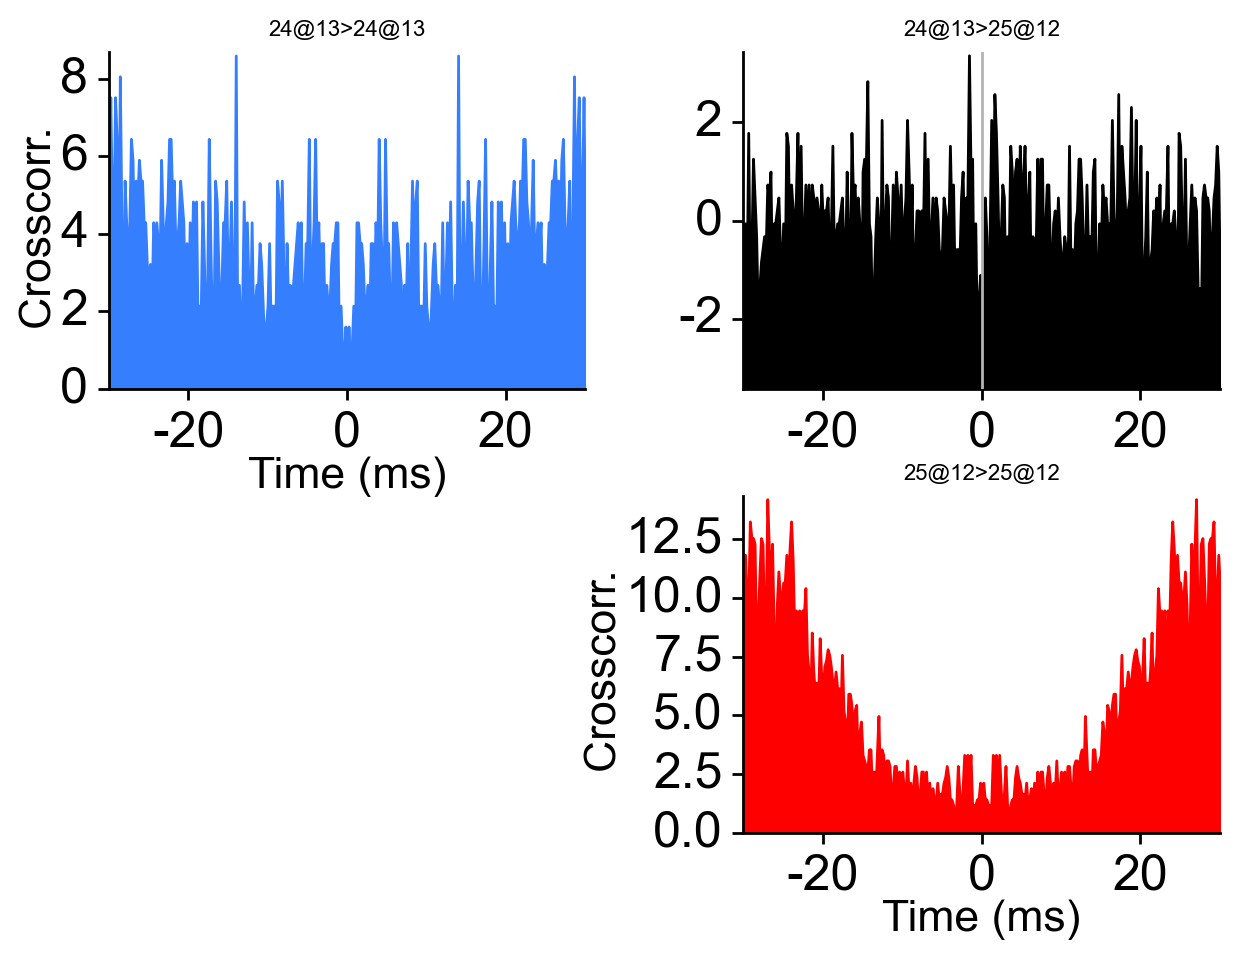

In [43]:
fig = plot_ccg(dp, [24,25], 0.2, 60, as_grid=True, figsize = (6,5))

### 2.3 - Drift-correcting and realigning waveforms

In [44]:
w_preprocessed = wvf_dsmatch(dp, u, plot_debug=True)

WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
Invalid times: [8]


TypeError: expected str, bytes or os.PathLike object, not NoneType

### 2.3 - Dynamic estimate of false positive and false negative rates

WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
Out of the 1714 spikes of unit 137, 1 belong to a section with less than 5% of false positive and false negative rates.


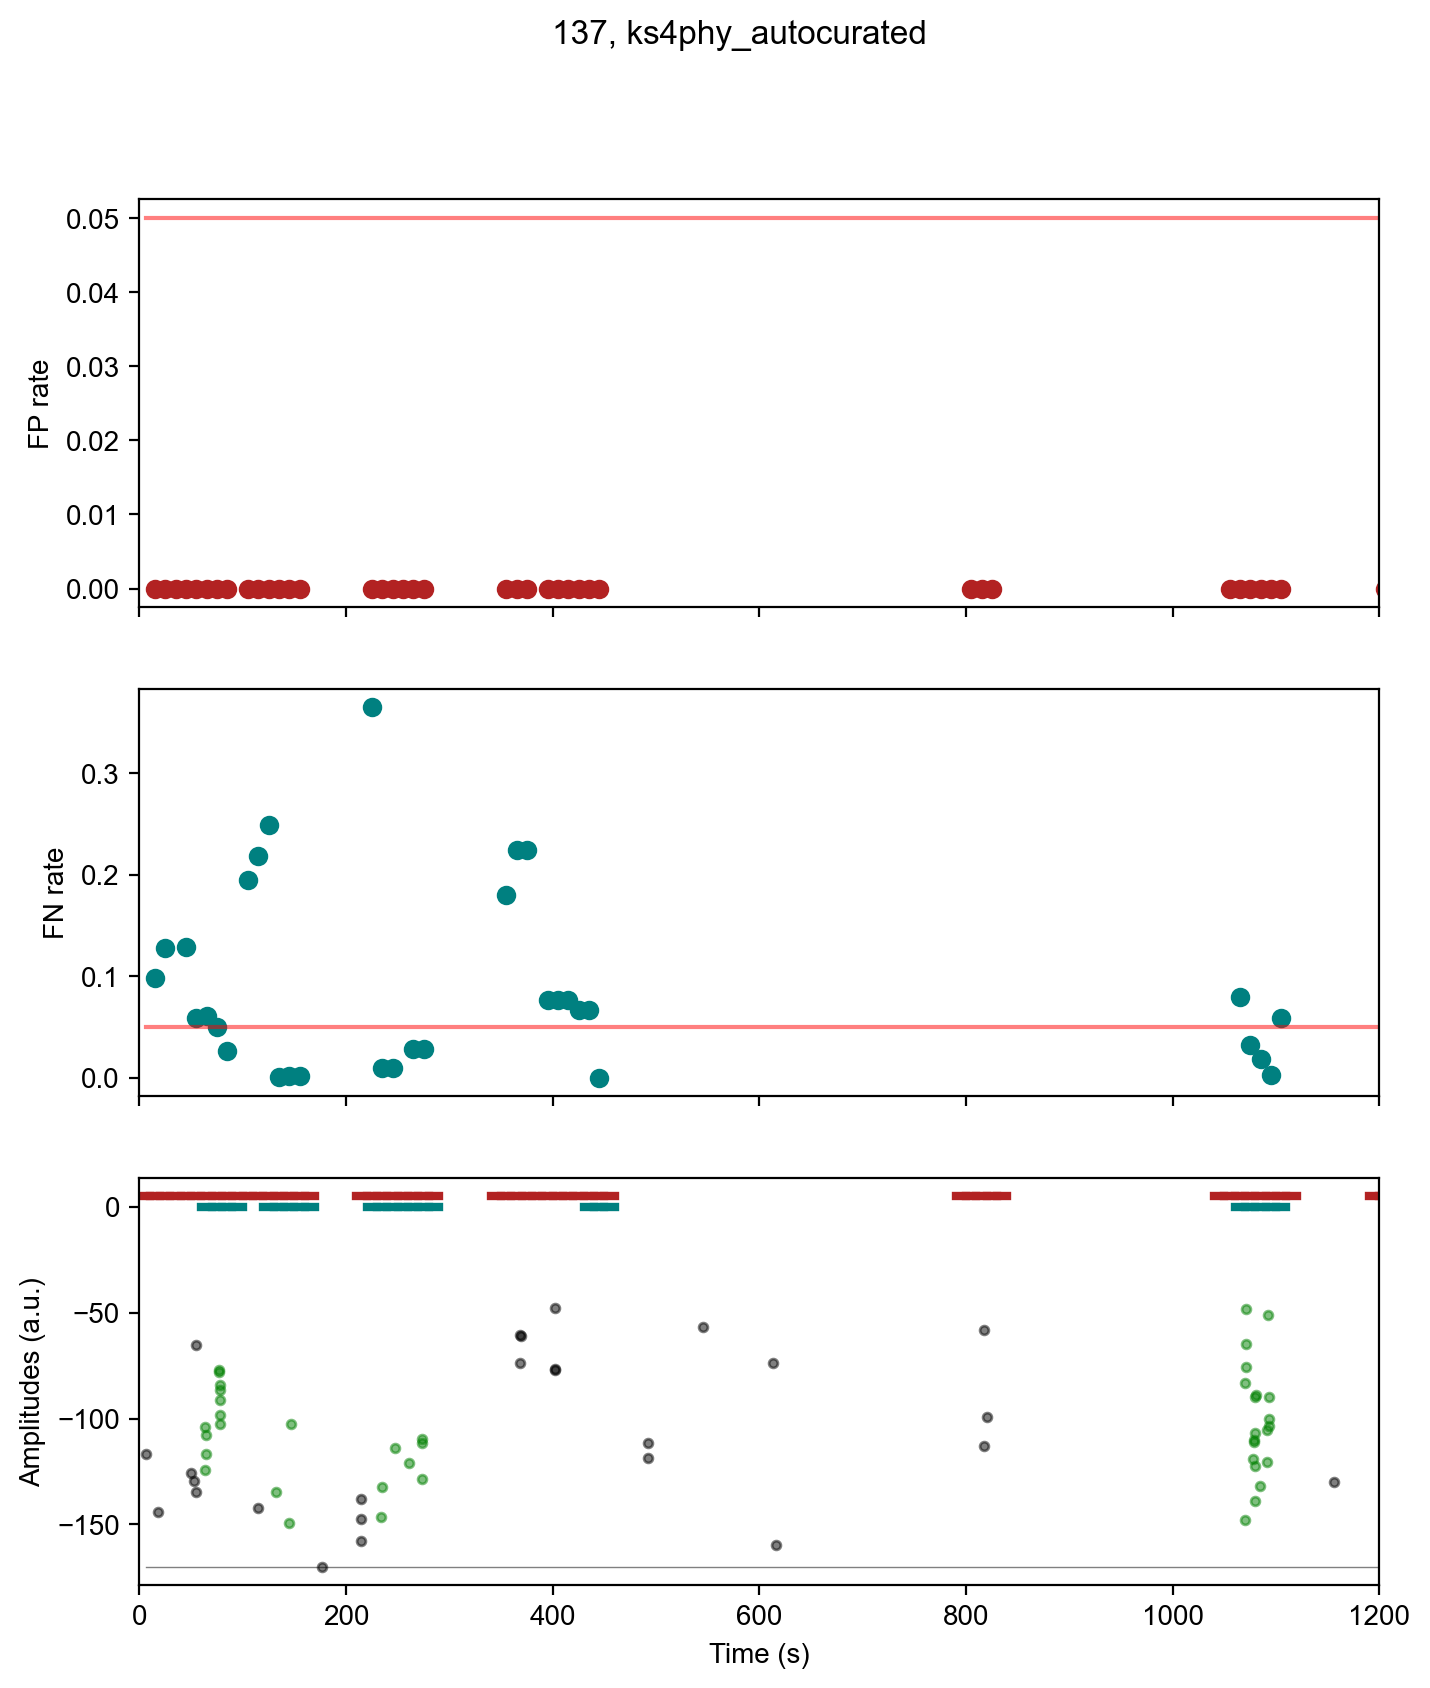

In [45]:
u_fpfn = good_units[-9]
t_preprocessed, t_preprocessed_mask = trn_filtered(dp, u_fpfn, plot_debug=True, again=True)
print(f"Out of the {trn(dp,u_fpfn).shape[0]} spikes of unit {u_fpfn}, {t_preprocessed.shape[0]} belong to a section with less than 5% of false positive and false negative rates.")

### 2.4 - Easily explore functional connectivity between neurons

In [46]:
# CCGs parameters
cbin=0.5
cwin=100
n_consec_bins=3
corr_type='inhibitions' #'synchrony'

# significance test parameters
p_th=0.01
fract_baseline=4./5
W_sd=10
test='Poisson_Stark'

mfr_th = 40
units=[u for u in get_units(dp) if mfr(dp,u)>mfr_th]
print(f'Found {len(units)} units above {mfr_th}Hz.')

fig=plot_sfcm(dp, corr_type=corr_type, metric='amp_z', cbin=cbin, cwin=cwin,
              p_th=p_th, n_consec_bins=n_consec_bins, fract_baseline=fract_baseline, W_sd=W_sd, test=test,
              drop_seq=['sign', 'time', 'max_amplitude'],
              units=units, name=f'all_units_move_{mfr_th}Hz',
              text=False, markers=False, ticks=True, depth_ticks=False,
              regions={},reg_colors={},
              vminmax=[-7,7], figsize=(4,4),
              saveFig=False, saveDir=dp, again=False, againCCG=0, use_template_for_peakchan=True,
              periods='all')

WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat
WARNING edit dat_path in params.py so that it matches relative location of NP binary file: ./continuous/Neuropix-PXI-100.ProbeA/continuous.dat

Computing ccgs over 16 cores:   0%|          | 16/12403 [00:15<01:56, 106.54it/s]

PermissionError: [Errno 13] Permission denied: 'F:\\Fa1680378B\\Day5_CntrlNoRotRot_Shank4BankA\\NeuralData\\ks4phy_autocurated\\.NeuroPyxels\\npyx\\spk_t\\trn\\b1b709e1e6834a53a3a83ff62dfb43ba\\output.pkl'

In [47]:
fig = plot_ccg(dp, [282,22], 0.2, 40)

AssertionError: WARNING unit 282 not found in dataset F:\Fa1680378B\Day5_CntrlNoRotRot_Shank4BankA\NeuralData\ks4phy_autocurated!

### 2.5 - Merge datasets acquired on 2 Neuropixels probes simultaneously

In [ ]:
from npyx.merger import merge_datasets 
dps = ['same_folder/lateralprobe_dataset',
       'same_folder/medialprobe_dataset',
       'same_folder/anteriorprobe_dataset']
probenames = ['lateral','medial','anterior']
dp_dict = {p:dp for p, dp in zip(probenames, dps)}

dp_merged, datasets_table = merge_datasets(dp_dict)

### Bonus: Make Pretty MatPlotLib = Make PLot Pretty = mplp()

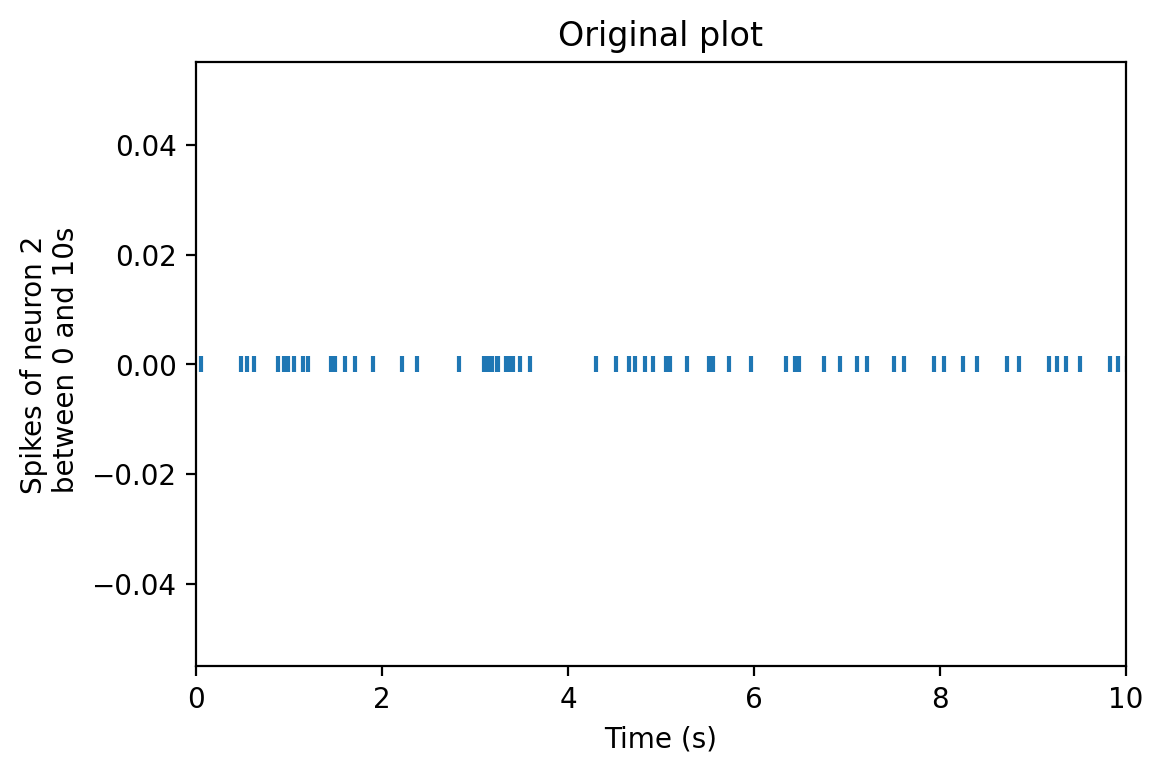

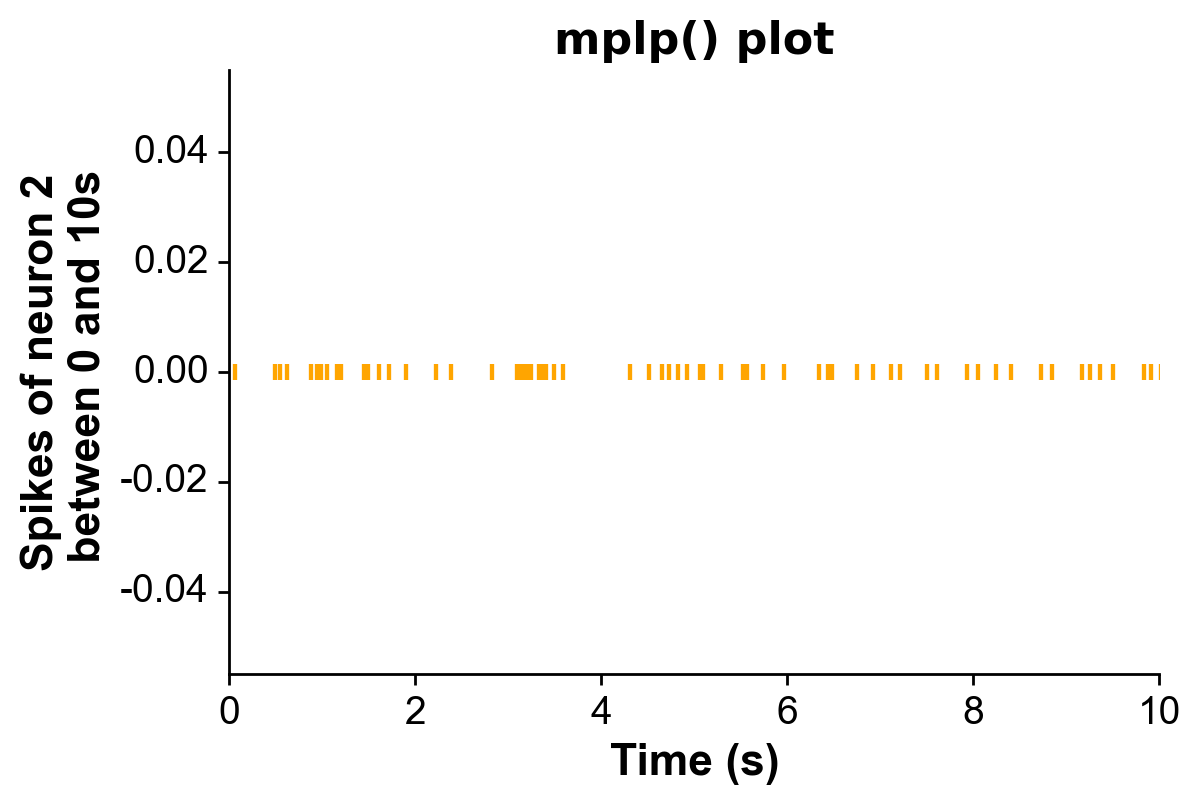

In [21]:
t = trn(dp, 2) / meta['highpass']['sampling_rate']

# default matplotlib style
plt.figure()
plt.scatter(t, t*0, marker="|")
plt.title("Original plot")
plt.xlim([0,10])
plt.ylabel("Spikes of neuron 2\n between 0 and 10s")
plt.xlabel("Time (s)")

# using mplp()
# makes most common matplotlib options easily accessible as function parameters
plt.figure()
plt.scatter(t, t*0, marker="|", color="orange")
t = trn(dp, 2) / meta['highpass']['sampling_rate']
plt.scatter(t, t*0, marker="|", color="orange")
#############
fig = mplp(xlim = [0,10], title = "mplp() plot",
     ylabel = "Spikes of neuron 2\n between 0 and 10s",
     xlabel = "Time (s)")
#############

### Bonus: display matplotlib colormaps

In [22]:
colors = get_ncolors_cmap('coolwarm', 10, plot=1)
colors = get_ncolors_cmap('viridis', 10, plot=1)